In [1]:
# ============================================================
# SETUP 0 — Instalasi Pustaka
# ============================================================

!pip install -U "huggingface_hub<0.30" transformers accelerate bitsandbytes pandas matplotlib scipy -q
print("All packages installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ============================================================
# SETUP 1 — Mount Google Drive
# Tujuan: menyediakan akses ke file dataset (Instrument KB,
#         region mapping, koordinat) yang tersimpan di Drive.
# ============================================================

import os

# 1. Pastikan Drive ter-mount
from google.colab import drive
drive.mount('/content/drive')

# # 2. Kita list folder di MyDrive untuk melihat nama yang "dikenali" Python
# print("Daftar folder di MyDrive:")
# print(os.listdir("/content/drive/MyDrive/Percobaan TA/Food KB/Data"))

Mounted at /content/drive


In [3]:
# ============================================================
# SETUP 2 — Import dan Konfigurasi Global
# ============================================================

import gc
import os
import ast
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import Counter
import pickle
from google.colab import drive
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# ── Global Configuration ──
MODEL_ID = "kakaocorp/kanana-nano-2.1b-base"
INSTRUMENT_ID = "10wZxP3osEg5xA_xlyDOhdkTCFf96sOe8"
REGION_CSV_ID = "1XCWJhLua97y-JAu0_p8zI45TawJPmwcE"
COORD_CSV_ID = "1Hu_4ldMVtLOUguj6JmYWJ-31CfmOxdtm"
PROMPT_TEMPLATE = "The most iconic traditional musical instrument from {country} is"
LOAD_FROM_DISK = True
SAVE_DIR = "/content/drive/MyDrive/Percobaan TA/Instrument/Data/"
COUNTRY_FILE = os.path.join(SAVE_DIR, "kanana_country_instrument_repr.pkl")
INSTRUMENT_FILE = os.path.join(SAVE_DIR, "kanana_pure_instrument_cache.pkl")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(SAVE_DIR, exist_ok=True)

def get_drive_url(file_id):
    return f'https://drive.google.com/uc?export=download&id={file_id}'

print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    # Perbaikan: total_mem -> total_memory
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}")
    print(f"VRAM: {props.total_memory / 1e9:.1f} GB")

print("Configuration loaded.")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Configuration loaded.


In [4]:
# ============================================================
# SETUP 3 — Pemuatan Model dan Tokenizer
# ============================================================

def _vram_report(label=""):
    """Print current GPU memory usage."""
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        resrv = torch.cuda.memory_reserved() / 1e9
        print(f"VRAM [{label}]: {alloc:.2f} GB allocated, "
              f"{resrv:.2f} GB reserved")

print("⏳ Loading tokenizer …")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("⏳ Loading kakaocorp/kanana-nano-2.1b-base in 4-bit NF4 …")

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_cfg,
    device_map="auto",
    trust_remote_code=True,
    output_hidden_states=True,
)

model.eval()

num_layers = model.config.num_hidden_layers

print(f"Model loaded — {sum(p.numel() for p in model.parameters())/1e9:.2f}B params, "
      f"{num_layers} layers")
_vram_report("post-load")

⏳ Loading tokenizer …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

⏳ Loading kakaocorp/kanana-nano-2.1b-base in 4-bit NF4 …


config.json:   0%|          | 0.00/692 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.17G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:817: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(


Model loaded — 1.16B params, 32 layers
VRAM [post-load]: 1.45 GB allocated, 1.59 GB reserved


In [5]:
# ============================================================
# SETUP 4 — Pemuatan Dataset
# Memuat Instrument Knowledge Base, pemetaan region, dan
# koordinat negara yang menjadi basis seluruh eksperimen di
# bawah. Domain kedua (pembanding domain kuliner) untuk RQ2.
# ============================================================

try:
    # Menggunakan INSTRUMENT_ID (Pastikan sudah didefinisikan di Cell 2)
    instrument_df = pd.read_csv(get_drive_url(INSTRUMENT_ID), on_bad_lines='skip', engine='python')
    print(f"Loaded Instrument KB: {instrument_df.shape[0]} rows.")
except Exception as e:
    print(f"Gagal memuat Instrument KB dari Drive: {e}")

# ── 4b. Load Region Mapping ────────────────────────────────
try:
    region_df = pd.read_csv(get_drive_url(REGION_CSV_ID))
    region_mapping = region_df.set_index('country')['region'].to_dict()
    print(f"Region mapping loaded: {len(region_mapping)} countries.")
except Exception as e:
    print(f"Gagal memuat Region Mapping: {e}")
    region_mapping = {}

# Fungsi untuk klasifikasi region
def get_country_region(country):
    return region_mapping.get(country, "Other")

# ── 4b. Robust Deep Parser for List-Strings ────────────────
def _safe_parse_all(val):
    """
    Menangani string, memproses Korea, dan mengonsolidasi UK.
    Tetap dipertahankan untuk jaga-jaga jika ada data berbentuk list string.
    """
    if pd.isna(val): return []

    extracted = []
    if isinstance(val, str):
        val = val.strip()
        if not val: return []
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                extracted = [str(i).strip() for i in parsed if i]
            else:
                extracted = [str(parsed).strip()]
        except (ValueError, SyntaxError):
            clean = val.replace('[','').replace(']','').replace('"','').replace("'",'')
            extracted = [i.strip() for i in clean.split(',') if i.strip()]
    else:
        extracted = [str(val).strip()]

    final_list = []
    UK_CONSTITUENTS = ["England", "Wales", "Scotland"]

    for c in extracted:
        c_clean = c.strip()
        if c_clean == "Korea":
            final_list.extend(["North Korea", "South Korea"])
        elif c_clean in UK_CONSTITUENTS:
            final_list.append("United Kingdom")
        else:
            final_list.append(c_clean)

    return list(set(final_list))

# ── 4c. Extract ALL Unique Countries (ADAPTED TO LONG FORMAT) ──────────
all_countries_set = set()

# Karena dataset baru kolomnya 'country' (singular) dan per baris
if 'country' in instrument_df.columns:
    for raw_country in instrument_df["country"].dropna().unique():
        # Tetap lewat safe_parse untuk handle jika ada yang input "England" atau "Korea"
        extracted = _safe_parse_all(raw_country)
        all_countries_set.update(extracted)
else:
    print("Kolom 'country' tidak ditemukan!")

# FILTER: Abaikan "Global"
countries = sorted([
    c for c in all_countries_set
    if c and c.lower() != "global"
])

print(f"Filtered {len(countries)} countries for experiment.")

# ── 4d. Extract ALL Unique Instrument Names ──────────────────────
if 'name' in instrument_df.columns:
    # Mengambil nama instrumen unik (Angklung hanya dihitung 1x di sini)
    all_instruments = instrument_df["name"].dropna().unique().tolist()
else:
    print("Kolom 'name' tidak ditemukan!")
    all_instruments = []

# ── 4e. Build BPE token-id sequences for Instruments ──
instrument_names = []
instrument_token_sequences = [] # Ganti nama variabel agar konsisten

print(f"⏳ Tokenizing {len(all_instruments)} instrument names...")
for name in all_instruments:
    name_str = str(name).strip()
    # Gunakan spasi di depan untuk format autoregresif
    ids = tokenizer.encode(" " + name_str, add_special_tokens=False)

    if len(ids) > 0:
        instrument_names.append(name_str)
        instrument_token_sequences.append(ids)

# ── Summary (Updated) ──
print(f"Full Dataset Parsed:")
print(f"   - Total Negara: {len(countries)}")
print(f"   - Total Instrumen Unik: {len(instrument_names)}")
print(f"   - Contoh: '{instrument_names[0]}' -> Tokens: {instrument_token_sequences[0]}")

Loaded Instrument KB: 2354 rows.
Region mapping loaded: 192 countries.
Filtered 187 countries for experiment.
⏳ Tokenizing 1766 instrument names...
Full Dataset Parsed:
   - Total Negara: 187
   - Total Instrumen Unik: 1766
   - Contoh: 'Dilruba' -> Tokens: [53867, 119535]


In [6]:
# ============================================================
# SETUP 5 — Utilitas Bersama
# Guard pengecekan model termuat, fungsi logit lens, dan
# forward pass aman yang dipakai ulang di beberapa eksperimen.
# ============================================================

def _check_model_loaded():
    """Guard: abort early if the model cell hasn't been run."""
    assert 'model' in dir() or 'model' in globals(), (
        "`model` not found. Run Cell 3 (Model Loading) first."
    )
    assert 'tokenizer' in dir() or 'tokenizer' in globals(), (
        "`tokenizer` not found. Run Cell 3 (Model Loading) first."
    )

def logit_lens_project(model, hidden_state):
    """
    Shared projection: apply final RMSNorm, then unembedding.
    Parameters
    ----------
    model        : the loaded Qwen model
    hidden_state : tensor of shape (1, D) — one position's activations
    Returns
    -------
    logits : tensor of shape (1, V) — full vocabulary logits
    """
    # 1. Pastikan input dalam dtype yang sesuai dengan model (float16/bfloat16)
    h_input = hidden_state.to(next(model.parameters()).dtype)

    # 2. Apply Final LayerNorm (RMSNorm) - Penting untuk Qwen/Llama
    h_normed = model.model.norm(h_input)

    # 3. Project ke lm_head menggunakan float32 untuk akurasi interpretability
    logits = torch.matmul(
        h_normed.float(),
        model.lm_head.weight.detach().t().float()
    )
    return logits

def safe_forward(model, tokenizer, prompt):
    """
    Shared forward pass with output_hidden_states=True.
    Returns
    -------
    hidden_states : tuple of (num_layers+1) tensors
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # Kita hanya butuh token terakhir [:, -1, :] untuk Logit Lens pada prediksi 'is'
    # Mengonversi ke float32 di sini untuk stabilisasi kalkulasi di cell berikutnya
    hidden_states = tuple(h[:, -1, :].float() for h in outputs.hidden_states)

    del outputs, inputs
    return hidden_states

def flush():
    """Aggressive VRAM + RAM cleanup."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Shared utilities defined: logit_lens_project, safe_forward, flush")

# FIX: fungsi geometri sferis dasar disediakan di sini (lebih awal dari
# Eksperimen C, Cell 21) supaya Kontrol/Eksperimen A/Baseline Eksklusif
# bisa memakai target regresi sferis alih-alih lat/lon mentah. Cell 21
# kelak mendefinisikan ulang fungsi yang sama plus fungsi tambahan
# (redefinisi ini aman di Python, tidak menimbulkan konflik).
R_EARTH_KM = 6371.0

def latlon_to_xyz(lat_deg, lon_deg):
    """Konversi (lat, lon) derajat -> vektor satuan 3D."""
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return np.stack([x, y, z], axis=-1)

def xyz_to_latlon(xyz):
    """Konversi vektor 3D -> (lat_deg, lon_deg). xyz tidak harus satuan."""
    xyz = xyz / np.linalg.norm(xyz, axis=-1, keepdims=True)
    lat = np.degrees(np.arcsin(np.clip(xyz[..., 2], -1, 1)))
    lon = np.degrees(np.arctan2(xyz[..., 1], xyz[..., 0]))
    return lat, lon

def great_circle_km(lat1, lon1, lat2, lon2):
    """Jarak great-circle dalam km. Scalar atau array."""
    xyz1 = latlon_to_xyz(np.array(lat1), np.array(lon1))
    xyz2 = latlon_to_xyz(np.array(lat2), np.array(lon2))
    dot = np.clip((xyz1 * xyz2).sum(axis=-1), -1.0, 1.0)
    return R_EARTH_KM * np.arccos(dot)

def great_circle_deg(lat1, lon1, lat2, lon2):
    """Jarak great-circle dalam derajat."""
    return np.degrees(great_circle_km(lat1, lon1, lat2, lon2) / R_EARTH_KM)

Shared utilities defined: logit_lens_project, safe_forward, flush


In [7]:
# ============================================================
# EKSPERIMEN KONTROL — Ekstraksi Representasi Berbasis Prompt
# Metode: teacher-forcing pada prompt yang menyertakan nama
#         negara secara eksplisit -> vektor log-probabilitas
#         atas kosakata instrumen (country_layer_repr).
# Peran: kondisi kontrol / batas atas, BUKAN jalur analisis
#        utama, karena prompt menyertakan penanda geografis
#        eksplisit (lihat Bab III.2.1).
# ============================================================

import torch.nn.functional as F
import torch
import numpy as np
import gc
from transformers.cache_utils import DynamicCache

print("=" * 65)
print("EKSPERIMEN KONTROL — EKSTRAKSI REPRESENTASI BERBASIS PROMPT")
print("Metode: batch per negara dengan pembersihan cache KV bertahap")
print("=" * 65)

_check_model_loaded()
country_layer_repr = {}
BATCH_SIZE = 512

# --- LOGIKA AUTO-LOAD (SISIPAN) ---
if os.path.exists(COUNTRY_FILE):
    print(f"Data ditemukan di Drive! Memuat {COUNTRY_FILE}...")
    with open(COUNTRY_FILE, 'rb') as f:
        country_layer_repr = pickle.load(f)
    print(f"Berhasil memuat {len(country_layer_repr)} negara. (Inference di-skip)")
    RUN_INFERENCE = False
else:
    print("Data tidak ditemukan di Drive. Menjalankan inference...")
    RUN_INFERENCE = True

# Seluruh proses di bawah ini hanya berjalan jika data tidak ada di Drive
if RUN_INFERENCE:
    # ── 1. Helper: Expansion yang Lebih Aman ──
    def expand_kv_cache_to_obj(past_kv, batch_size):
        if past_kv is None:
            return None

        new_cache = DynamicCache()

        for layer_idx, layer in enumerate(past_kv.layers):
            k = layer.keys    # shape: (1, num_heads, seq_len, head_dim)
            v = layer.values

            k_exp = k.expand(batch_size, -1, -1, -1).clone().contiguous()
            v_exp = v.expand(batch_size, -1, -1, -1).clone().contiguous()
            new_cache.update(k_exp, v_exp, layer_idx=layer_idx)

        return new_cache

    # ── 2. Grouping Makanan ──
    food_groups = {}
    for i, seq in enumerate(instrument_token_sequences):
        l = len(seq)
        if l not in food_groups: food_groups[l] = []
        food_groups[l].append({'id': i, 'tokens': seq})

    # Gunakan Inference Mode (Lebih ketat & irit daripada no_grad)
    for ci, country in enumerate(countries):
        print(f"  [{ci+1}/{len(countries)}] Processing: {country:.<20s}", end="", flush=True)

        prompt = PROMPT_TEMPLATE.format(country=country)
        prompt_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)

        try:
            with torch.inference_mode():
                # A. Prompt Forward
                outputs = model(prompt_ids, use_cache=True)
                # Ambil KV-Cache asli
                past_kv = outputs.past_key_values
                # Simpan logits token pertama ke CPU
                first_lps = F.log_softmax(outputs.logits[:, -1, :], dim=-1).float().cpu().squeeze(0).numpy()

                # SEGERA hapus outputs agar VRAM lega
                del outputs

                final_scores = np.zeros(len(instrument_names), dtype=np.float32)

                # B. Loop Makanan
                for length, group in food_groups.items():
                    for item in group:
                        final_scores[item['id']] = first_lps[item['tokens'][0]]

                    if length > 1:
                        for i in range(0, len(group), BATCH_SIZE):
                            sub_group = group[i : i + BATCH_SIZE]
                            curr_bs = len(sub_group)

                            rem_tokens = torch.tensor([item['tokens'][:-1] for item in sub_group], device=DEVICE)
                            target_ids = [item['tokens'][1:] for item in sub_group]

                            # Expand KV-Cache
                            expanded_cache = expand_kv_cache_to_obj(past_kv, curr_bs)

                            res_out = model(rem_tokens, past_key_values=expanded_cache, use_cache=False)
                            # Hitung log-prob di CPU secara bertahap agar tidak numpuk
                            res_lps = F.log_softmax(res_out.logits.float(), dim=-1).cpu()

                            for b_idx in range(curr_bs):
                                f_id = sub_group[b_idx]['id']
                                for t_pos, tid in enumerate(target_ids[b_idx]):
                                    final_scores[f_id] += res_lps[b_idx, t_pos, tid].item()

                            for layer in expanded_cache.layers:
                                layer.keys = None
                                layer.values = None
                            del expanded_cache
                            # Tiap 5 batch, kosongkan cache
                            if (i // BATCH_SIZE) % 5 == 0:
                                torch.cuda.empty_cache()

                # C. Softmax & Simpan
                stable_repr = final_scores - np.mean(final_scores)

                full_repr = np.zeros((num_layers, len(instrument_names)), dtype=np.float32)

                full_repr[num_layers - 1] = stable_repr
                country_layer_repr[country] = full_repr

                # --- D. FINAL CLEANUP NEGARA ---
                # Hapus referensi KV-cache asli
                for layer in past_kv.layers:
                    layer.keys = None
                    layer.values = None
                del past_kv, first_lps, final_scores, prompt_ids

                gc.collect()
                torch.cuda.empty_cache()

                v_info = torch.cuda.mem_get_info()
                vram_free = v_info[0] / 1e9
                print(f"Done. (VRAM Sisa: {vram_free:.2f} GB)", flush=True)

        except RuntimeError as e:
            print(f"Error: {e}")
            torch.cuda.empty_cache()
            gc.collect()
            continue

    # --- SIMPAN KE DRIVE SETELAH LOOP SELESAI ---
    with open(COUNTRY_FILE, 'wb') as f:
        pickle.dump(country_layer_repr, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"\n HASIL INFERENCE DISIMPAN KE: {COUNTRY_FILE}")

print("\nEkstraksi selesai.")

EKSPERIMEN KONTROL — EKSTRAKSI REPRESENTASI BERBASIS PROMPT
Metode: batch per negara dengan pembersihan cache KV bertahap
Data ditemukan di Drive! Memuat /content/drive/MyDrive/Percobaan TA/Instrument/Data/kanana_country_instrument_repr.pkl...
Berhasil memuat 187 negara. (Inference di-skip)

Ekstraksi selesai.


In [8]:
# ============================================================
# EKSPERIMEN KONTROL — Pemeriksaan Sanity
# Menampilkan top-5 instrumen dengan probabilitas tertinggi
# per negara sebagai pengecekan kualitatif hasil ekstraksi.
# ============================================================

test_countries = ["Indonesia", "Japan", "Italy", "Mexico", "Lebanon"]

for c in test_countries:
    if c in country_layer_repr:
        # Ambil vektor probabilitas dari layer terakhir
        probs = country_layer_repr[c][num_layers - 1]

        # Ambil 5 index dengan nilai probabilitas tertinggi
        top_5_idx = np.argsort(probs)[-5:][::-1]

        print(f"\n{c.upper()}:")
        for idx in top_5_idx:
            print(f"  - {instrument_names[idx]:<20} | Prob: {probs[idx]:.4f}")


INDONESIA:
  - Suling               | Prob: 17.5599
  - Banjo                | Prob: 17.3881
  - Balafon              | Prob: 17.1797
  - Saron                | Prob: 16.4193
  - Tun                  | Prob: 16.2195

JAPAN:
  - Koto                 | Prob: 20.2236
  - Banjo                | Prob: 17.1912
  - Taiko                | Prob: 16.9909
  - Tsuzumi              | Prob: 16.3953
  - Shakuhachi           | Prob: 16.1002

ITALY:
  - Guitarra             | Prob: 16.4449
  - Fiddle               | Prob: 16.3161
  - Banjo                | Prob: 16.0517
  - Sitar                | Prob: 16.0207
  - Marimba              | Prob: 15.6408

MEXICO:
  - Marimba              | Prob: 16.8728
  - Guitarra             | Prob: 16.7063
  - Cuica                | Prob: 16.4865
  - Quena                | Prob: 15.8508
  - Cuatro               | Prob: 15.7833

LEBANON:
  - Daf                  | Prob: 17.5461
  - Qanun                | Prob: 17.4925
  - Barbat               | Prob: 16.8971
  - Darbuk

EKSPERIMEN KONTROL — PROBING LINEAR (AGREGAT-NEGARA)
Loaded coordinates for 245 countries from CSV.

 HASIL EVALUASI LINEAR PROBE (GLOBAL):
Latitude  | MAE: 4.62°
Longitude | MAE: 8.95°
AVERAGE GLOBAL ERROR: 9.37 derajat
Latitude R² (Kontrol): 0.922
Longitude R² (Kontrol): 0.944


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: GDAL was built against curl 8.20.0, but is running against 8.11.0. Runtime failure is likely !
  return ogr_read(


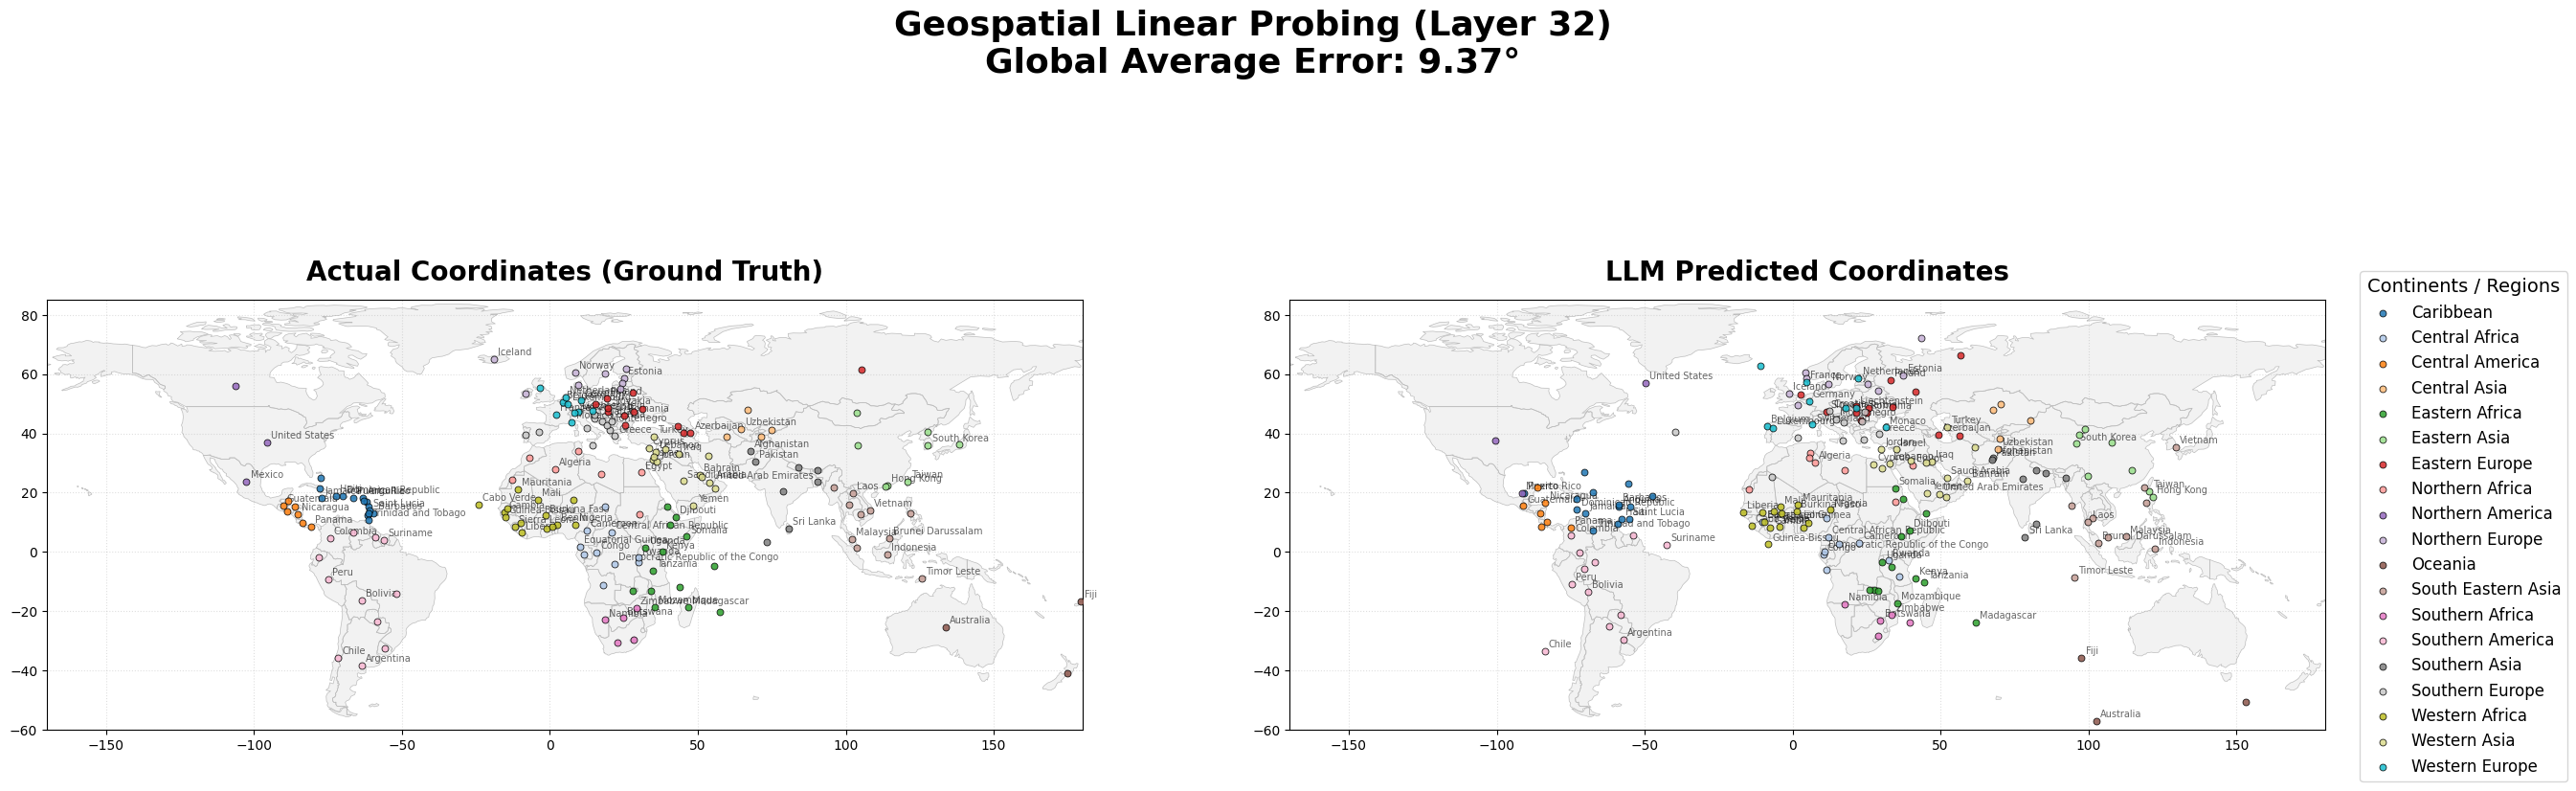

In [9]:
# ============================================================
# EKSPERIMEN KONTROL — Probing Linear (Agregat-Negara)
# Meregresi country_layer_repr ke koordinat lat/lon.
# Menjawab RQ1 untuk kondisi kontrol/batas atas.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib as mpl
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("=" * 65)
print("EKSPERIMEN KONTROL — PROBING LINEAR (AGREGAT-NEGARA)")
print("=" * 65)

# ── 1. Load Koordinat ──
try:
    coord_df = pd.read_csv(get_drive_url(COORD_CSV_ID))
    country_coords = {}
    for _, row in coord_df.iterrows():
        country_coords[row['name'].strip()] = {
            'lat': float(row['latitude']),
            'lon': float(row['longitude'])
        }

    # Penyesuaian Manual
    if "Korea" in country_coords:
        country_coords["North Korea"] = {'lat': 40.3, 'lon': 127.5}
        country_coords["South Korea"] = {'lat': 35.9, 'lon': 127.7}

    print(f"Loaded coordinates for {len(country_coords)} countries from CSV.")
except Exception as e:
    print(f"Gagal membaca CSV Koordinat: {e}")
    country_coords = {}

# ── 2. Persiapkan Data X dan Y ──
probe_layer_idx = num_layers - 1
X_list, y_lat_list, y_lon_list, valid_countries = [], [], [], []

for c in countries:
    if c in country_coords:
        feat = country_layer_repr[c][probe_layer_idx]
        X_list.append(feat)
        y_lat_list.append(country_coords[c]['lat'])
        y_lon_list.append(country_coords[c]['lon'])
        valid_countries.append(c)

X = np.array(X_list)
y_lat = np.array(y_lat_list)
y_lon = np.array(y_lon_list)

# ── 3. Train & Evaluate (5-Fold Cross-Validation) ──
# FIX: StandardScaler(with_std=False) + RidgeCV + target sferis,
# konsisten dengan Eksperimen B/D dan dengan notebook domain kuliner.
probe_model = Pipeline([
    ('scaler', StandardScaler(with_std=False)),
    ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 150.0, 500.0],
                      scoring='neg_mean_absolute_error'))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_xyz = latlon_to_xyz(y_lat, y_lon)
pred_xyz = cross_val_predict(probe_model, X, y_xyz, cv=cv)
pred_lat, pred_lon = xyz_to_latlon(pred_xyz)

avg_global_error = great_circle_deg(y_lat, y_lon, pred_lat, pred_lon).mean()

# --- TAMBAHAN: R² untuk komponen lintang dan bujur (Kontrol) ---
r2_lat_kontrol = r2_score(y_lat, pred_lat)
r2_lon_kontrol = r2_score(y_lon, pred_lon)
# -----------------------------------------------------------------

print("\n HASIL EVALUASI LINEAR PROBE (GLOBAL):")
print(f"Latitude  | MAE: {mean_absolute_error(y_lat, pred_lat):.2f}°")
print(f"Longitude | MAE: {mean_absolute_error(y_lon, pred_lon):.2f}°")
print(f"AVERAGE GLOBAL ERROR: {avg_global_error:.2f} derajat")
print(f"Latitude R² (Kontrol): {r2_lat_kontrol:.3f}")
print(f"Longitude R² (Kontrol): {r2_lon_kontrol:.3f}")

# ── 4. BANGUN DATAFRAME HASIL (PENTING: Harus sebelum Plotting) ──
analysis_data = []
for i, country in enumerate(valid_countries):
    analysis_data.append({
        "Country": country,
        "Region": get_country_region(country),
        "Actual_Lat": y_lat[i],
        "Actual_Lon": y_lon[i],
        "Pred_Lat": pred_lat[i],
        "Pred_Lon": pred_lon[i]
    })
df_results = pd.DataFrame(analysis_data)

# ── 5. LOAD BACKGROUND PETA (Mencegah NameError: world) ──
try:
    # Coba load dataset bawaan
    world_path = gpd.datasets.get_path('naturalearth_lowres')
    world = gpd.read_file(world_path)
except:
    # Fallback jika library geopandas versi baru (dataset dihapus)
    url = "https://raw.githubusercontent.com/datasets/geo-boundaries-world-110m/master/countries.geojson"
    world = gpd.read_file(url)

# ── 6. Visualisasi (PETA MAKSIMAL) ──
unique_regions = sorted(df_results['Region'].unique())
cmap = mpl.colormaps.get_cmap('tab20')
region_colors = {reg: cmap(i % 20) for i, reg in enumerate(unique_regions)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(28, 12))
plt.suptitle(f"Geospatial Linear Probing (Layer {probe_layer_idx+1})\nGlobal Average Error: {avg_global_error:.2f}°",
             fontsize=26, fontweight='bold', y=0.95)

for ax, mode, title in zip([ax1, ax2], ["Actual", "Pred"],
                           ["Actual Coordinates (Ground Truth)", "LLM Predicted Coordinates"]):
    # Gambar Background
    world.boundary.plot(ax=ax, linewidth=0.5, color='#bcbcbc', zorder=1)
    world.plot(ax=ax, color='#f2f2f2', zorder=0)

    # Plot per region
    for reg in unique_regions:
        reg_data = df_results[df_results['Region'] == reg]
        lons = reg_data['Actual_Lon'] if mode == "Actual" else reg_data['Pred_Lon']
        lats = reg_data['Actual_Lat'] if mode == "Actual" else reg_data['Pred_Lat']

        ax.scatter(lons, lats, color=region_colors[reg], edgecolor='black',
                   linewidth=0.6, s=25, alpha=0.85, label=reg, zorder=5)

    ax.set_title(title, fontsize=20, pad=15, fontweight='semibold')
    ax.set_xlim(-170, 180)
    ax.set_ylim(-60, 85)
    ax.grid(True, linestyle=':', alpha=0.4)

    # Label Negara (Sampling)
    for i, row in df_results.reset_index().iterrows():
        if i % 2 == 0: # Biar tidak terlalu penuh
            tx = row['Actual_Lon'] if mode == "Actual" else row['Pred_Lon']
            ty = row['Actual_Lat'] if mode == "Actual" else row['Pred_Lat']
            ax.annotate(row['Country'], (tx, ty), fontsize=7, alpha=0.6,
                        xytext=(3,3), textcoords='offset points')

# Legenda
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.91, 0.5),
           fontsize=12, title="Continents / Regions", title_fontsize=14)

plt.subplots_adjust(left=0.05, right=0.90, top=0.92, bottom=0.1)
plt.show()


EKSPERIMEN KONTROL — ANALISIS AKURASI REGIONAL
            Region  Count  Avg_Error_Deg  MAE_Lat  MAE_Lon
   Central America      7           3.64     2.42     2.32
     Southern Asia      8           4.58     3.07     3.29
      Central Asia      5           5.52     4.27     4.59
   Northern Africa      7           5.75     2.43     5.57
      Western Asia     15           6.26     3.52     5.51
   Southern Africa      5           6.37     3.24     5.48
    Western Africa     15           7.15     4.18     5.49
   Northern Europe      9           7.65     5.22    10.29
   Southern Europe     11           8.18     3.55     7.74
  Southern America     12           8.25     4.42     6.51
    Western Europe     10           9.02     4.91     9.82
    Central Africa     10           9.13     3.71     8.25
         Caribbean     15           9.20     3.70     8.30
    Eastern Europe     13          10.95     4.68    15.39
    Eastern Africa     14          11.69     6.96     8.55
South Ea

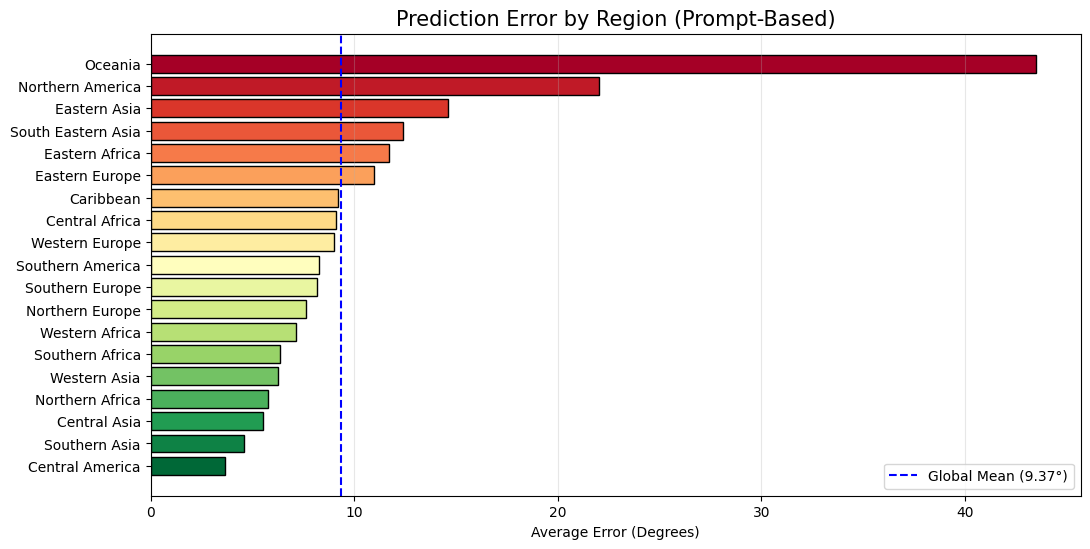

In [10]:
# ============================================================
# EKSPERIMEN KONTROL — Analisis Akurasi Regional
# ============================================================

print("\n" + "="*65)
print("EKSPERIMEN KONTROL — ANALISIS AKURASI REGIONAL")
print("=" * 65)

regional_stats = []

# Grouping berdasarkan df_results yang baru saja kamu buat
for region, group in df_results.groupby("Region"):
    n_samples = len(group)

    # MAE per region
    mae_lat_reg = mean_absolute_error(group["Actual_Lat"], group["Pred_Lat"])

    delta_lon = (group["Actual_Lon"] - group["Pred_Lon"]).abs()
    mae_lon_reg = np.minimum(delta_lon, 360 - delta_lon).mean()

    avg_err_reg = great_circle_deg(group["Actual_Lat"], group["Actual_Lon"],
                                    group["Pred_Lat"], group["Pred_Lon"]).mean()


    # R^2 per region (minimal 2 sampel)
    if n_samples > 1:
        r2_lat_reg = r2_score(group["Actual_Lat"], group["Pred_Lat"])
    else:
        r2_lat_reg = np.nan

    regional_stats.append({
        "Region": region,
        "Count": n_samples,
        "Avg_Error_Deg": round(avg_err_reg, 2),
        "MAE_Lat": round(mae_lat_reg, 2),
        "MAE_Lon": round(mae_lon_reg, 2),
    })

df_stats = pd.DataFrame(regional_stats).sort_values("Avg_Error_Deg")
df_plot = df_stats.sort_values("Avg_Error_Deg", ascending=True)

print(df_stats.to_string(index=False))
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(df_plot))) # Hijau ke Merah

# Plotting Bar Chart Error per Region
plt.figure(figsize=(12, 6))
df_plot = df_stats.sort_values("Avg_Error_Deg", ascending=True)
plt.barh(df_plot["Region"], df_plot["Avg_Error_Deg"], color=colors, edgecolor='black')
plt.axvline(avg_global_error, color='blue', linestyle='--', label=f'Global Mean ({avg_global_error:.2f}°)')
plt.title("Prediction Error by Region (Prompt-Based)", fontsize=15)
plt.xlabel("Average Error (Degrees)")
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.show()

In [11]:
# ============================================================
# EKSPERIMEN KONTROL — Visualisasi Peta Per-Wilayah (Auto-Zoom)
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

print("=" * 65)
print("EKSPERIMEN KONTROL — VISUALISASI PETA PER-WILAYAH")
print("Generating detailed maps for each region...")
print("=" * 65)

# 1. Dapatkan daftar region unik
unique_regions = sorted(df_results['Region'].unique())

# 2. Gunakan palette warna yang sama dengan peta global sebelumnya
# (Pastikan variabel region_colors dari cell sebelumnya sudah ada)

for region in unique_regions:
    # Filter data khusus region ini
    reg_data = df_results[df_results['Region'] == region].copy()

    if len(reg_data) < 1:
        continue

    # 3. Hitung Error Spesifik Region
    mae_lat_reg = mean_absolute_error(reg_data["Actual_Lat"], reg_data["Pred_Lat"])

    delta_lon = (reg_data["Actual_Lon"] - reg_data["Pred_Lon"]).abs()
    mae_lon_reg = np.minimum(delta_lon, 360 - delta_lon).mean()

    avg_err_reg = great_circle_deg(reg_data["Actual_Lat"], reg_data["Actual_Lon"],
                                    reg_data["Pred_Lat"], reg_data["Pred_Lon"]).mean()

    # 4. Setup Plot Side-by-Side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Judul Per Region
    plt.suptitle(f"REGION ANALYSIS: {region.upper()}\n"
                 f"Avg Error: {avg_err_reg:.2f}° | Sample: {len(reg_data)} Countries",
                 fontsize=22, fontweight='bold', y=1.05)

    # 5. Tentukan Batas Zoom Otomatis (Auto-Zoom Logic)
    # Kita ambil batas dari koordinat asli dan prediksi, lalu beri padding 5-10 derajat
    all_lons = pd.concat([reg_data["Actual_Lon"], reg_data["Pred_Lon"]])
    all_lats = pd.concat([reg_data["Actual_Lat"], reg_data["Pred_Lat"]])

    pad = 8 # Padding derajat agar peta tidak terlalu mepet ke pinggir
    lon_min, lon_max = all_lons.min() - pad, all_lons.max() + pad
    lat_min, lat_max = all_lats.min() - pad, all_lats.max() + pad

    # 6. Plotting Actual vs Predicted
    for ax, mode, title, color_map_key in zip(
        [ax1, ax2],
        ["Actual", "Pred"],
        [f"Ground Truth ({region})", f"LLM Internal Concept ({region})"],
        ["Actual", "Predicted"]
    ):
        # Gambar background peta dunia
        if world is not None:
            world.boundary.plot(ax=ax, linewidth=1, color='gray', alpha=0.4, zorder=1)
            world.plot(ax=ax, color='#fdfdfd', zorder=0)

        # Plot titik negara
        lons = reg_data['Actual_Lon'] if mode == "Actual" else reg_data['Pred_Lon']
        lats = reg_data['Actual_Lat'] if mode == "Actual" else reg_data['Pred_Lat']

        # Gunakan warna spesifik region dari map global
        current_color = region_colors.get(region, "dodgerblue")

        ax.scatter(lons, lats, color=current_color, edgecolor='black',
                   s=100, alpha=0.9, zorder=5)

        # Beri label SEMUA negara (karena level region, ruangnya cukup luas)
        for i, row in reg_data.reset_index().iterrows():
            tx = row['Actual_Lon'] if mode == "Actual" else row['Pred_Lon']
            ty = row['Actual_Lat'] if mode == "Actual" else row['Pred_Lat']
            ax.annotate(row['Country'], (tx, ty), fontsize=11, fontweight='bold',
                        xytext=(5, 5), textcoords='offset points',
                        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))

        ax.set_title(title, fontsize=16, fontweight='semibold')
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.set_facecolor('#f0f8ff') # Warna air laut tipis

    plt.tight_layout()

    # Opsional: Simpan gambar untuk lampiran TA
    # plt.savefig(f"analysis_{region.replace(' ', '_').lower()}.png", dpi=150)

    plt.show()
    print(f"Finished Analysis for {region}")

Output hidden; open in https://colab.research.google.com to view.

EKSPERIMEN A — EKSTRAKSI PURE EMBEDDING DAN CLUSTERING
Data ditemukan di Drive! Memuat /content/drive/MyDrive/Percobaan TA/Instrument/Data/kanana_pure_instrument_cache.pkl...
Berhasil memuat 1766 instrumen.
⏳ Mengelompokkan instrumen berdasarkan persebaran wilayah...
Berhasil memetakan 1766 instrumen untuk visualisasi.
⏳ Menghitung t-SNE...


/tmp/ipykernel_678/3499919518.py:132: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(main_regions))


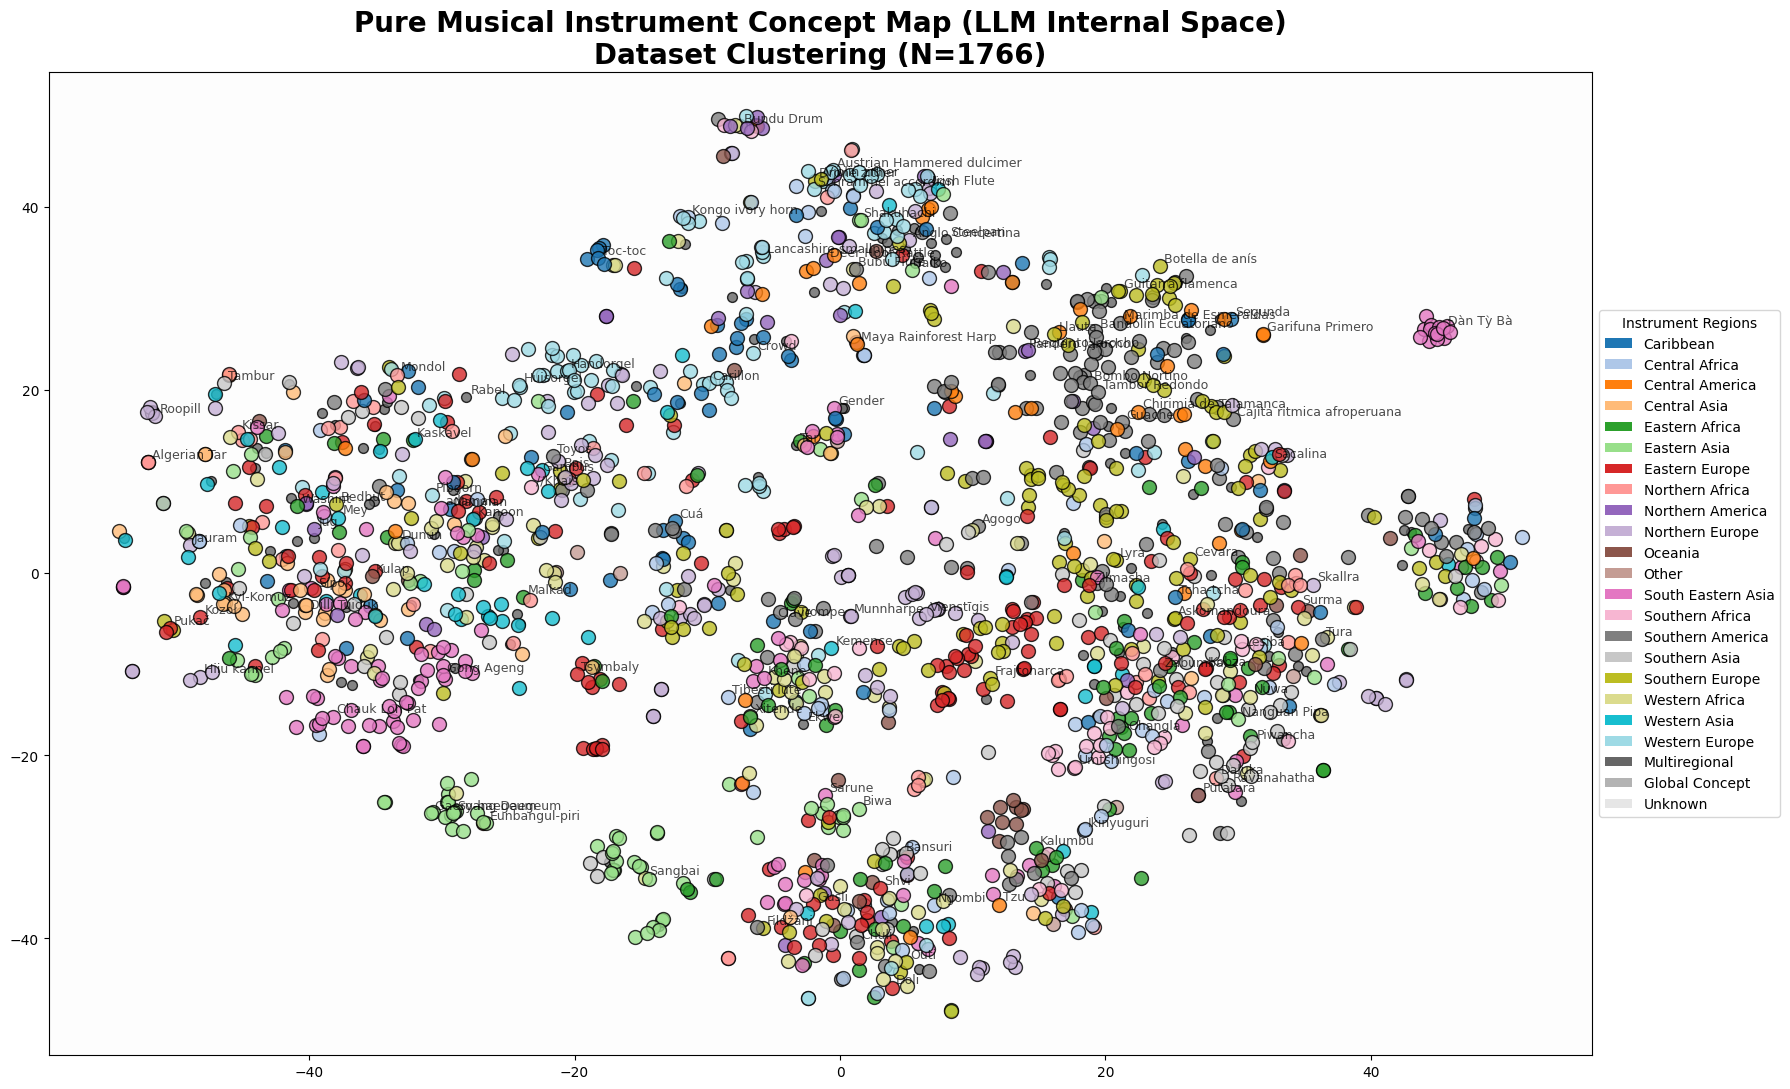

In [12]:
# ============================================================
# EKSPERIMEN A — Ekstraksi Pure Embedding dan Clustering
# Representasi diambil dari hidden state nama instrumen SAJA,
# tanpa konteks kalimat/nama negara (lihat Bab III.2.1).
# ============================================================

import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os
import pickle

print("=" * 65)
print("EKSPERIMEN A — EKSTRAKSI PURE EMBEDDING DAN CLUSTERING")
print("=" * 65)

# 1. Persiapan data
pure_instrument_cache = {}
all_inst_to_process = instrument_names # Dari Cell 4

# --- LOGIKA AUTO-LOAD ---
if os.path.exists(INSTRUMENT_FILE):
    print(f"Data ditemukan di Drive! Memuat {INSTRUMENT_FILE}...")
    with open(INSTRUMENT_FILE, 'rb') as f:
        pure_instrument_cache = pickle.load(f)

    reset_needed = False
    if len(pure_instrument_cache) == 0:
        reset_needed = True
    else:
        sample_val = list(pure_instrument_cache.values())[0]
        if sample_val.ndim > 1:
            print("Format lama terdeteksi. Reset...")
            reset_needed = True
        elif list(pure_instrument_cache.keys())[0] in countries:
            print("Isi file salah (data negara). Reset...")
            reset_needed = True

    if reset_needed:
        if os.path.exists(INSTRUMENT_FILE): os.remove(INSTRUMENT_FILE)
        RUN_INST_INF = True
        pure_instrument_cache = {}
    else:
        print(f"Berhasil memuat {len(pure_instrument_cache)} instrumen.")
        RUN_INST_INF = False
else:
    print(f"⏳ Data tidak ditemukan. Mengekstrak embedding untuk {len(all_inst_to_process)} instrumen...")
    RUN_INST_INF = True

# Proses ekstraksi
if RUN_INST_INF:
    for i, inst in enumerate(all_inst_to_process):
        if (i+1) % 100 == 0:
            print(f"  [{i+1}/{len(all_inst_to_process)}] Processing...")

        hs = safe_forward(model, tokenizer, inst)
        last_layer = hs[-1].detach().cpu().numpy().squeeze(0)
        pure_instrument_cache[inst] = last_layer

    with open(INSTRUMENT_FILE, 'wb') as f:
        pickle.dump(pure_instrument_cache, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"HASIL DISIMPAN KE: {INSTRUMENT_FILE}")

# 2. Mapping Skala Penuh (ADAPTASI LONG FORMAT)
inst_to_region = {}
valid_instruments = []
normalized_cache = {str(k).strip(): v for k, v in pure_instrument_cache.items()}

print("⏳ Mengelompokkan instrumen berdasarkan persebaran wilayah...")

# --- PERBAIKAN STRUKTUR DI SINI ---
# Kita kelompokkan dulu negaranya berdasarkan nama instrumen
# Contoh: 'Angklung' -> ['Indonesia', 'Singapore']
inst_grouped = instrument_df.groupby('name')['country'].apply(list).to_dict()

for inst_name, raw_countries in inst_grouped.items():
    inst_name = str(inst_name).strip()
    if inst_name not in normalized_cache: continue

    # Parse setiap negara (untuk handle "England" -> "United Kingdom")
    all_mapped_countries = []
    for c in raw_countries:
        all_mapped_countries.extend(_safe_parse_all(c))

    unique_mapped_countries = list(set(all_mapped_countries))

    regions_found = []
    is_global_only = False

    if not unique_mapped_countries:
        final_label = "Unknown"
    else:
        for c in unique_mapped_countries:
            if str(c).lower() == "global":
                is_global_only = True
            else:
                regions_found.append(get_country_region(c))

        unique_regions = list(set(regions_found))

        if len(unique_regions) == 1:
            final_label = unique_regions[0]
        elif len(unique_regions) > 1:
            final_label = "Multiregional"
        elif is_global_only:
            final_label = "Global Concept"
        else:
            final_label = "Unknown"

    inst_to_region[inst_name] = final_label
    valid_instruments.append(inst_name)

print(f"Berhasil memetakan {len(valid_instruments)} instrumen untuk visualisasi.")

# 3. Visualisasi t-SNE
if len(valid_instruments) > 1:
    X_pure = np.array([normalized_cache[inst] for inst in valid_instruments])
    X_pure = X_pure - np.mean(X_pure, axis=0) # Centering

    print(f"⏳ Menghitung t-SNE...")
    perp_val = max(1, min(30, len(valid_instruments) - 1))
    tsne_pure = TSNE(n_components=2, perplexity=perp_val, random_state=42)
    X_embedded_pure = tsne_pure.fit_transform(X_pure)

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(18, 11))
    all_labels = sorted(list(set(inst_to_region.values())))
    special_labels = ["Multiregional", "Global Concept", "Unknown"]
    main_regions = [l for l in all_labels if l not in special_labels]

    cmap = plt.cm.get_cmap('tab20', len(main_regions))
    color_map = {reg: cmap(i) for i, reg in enumerate(main_regions)}
    color_map["Multiregional"] = (0.4, 0.4, 0.4)
    color_map["Global Concept"] = (0.7, 0.7, 0.7)
    color_map["Unknown"] = (0.9, 0.9, 0.9)

    for i, inst in enumerate(valid_instruments):
        reg = inst_to_region[inst]
        color = color_map.get(reg, (0.5, 0.5, 0.5))

        ax.scatter(X_embedded_pure[i, 0], X_embedded_pure[i, 1],
                   c=[color],
                   s=100 if reg not in special_labels else 50,
                   edgecolors='black', alpha=0.8,
                   zorder=2 if reg not in special_labels else 1)

        # Labeling (Sampling agar tidak terlalu padat)
        if i % 15 == 0:
            ax.annotate(inst, (X_embedded_pure[i, 0], X_embedded_pure[i, 1]),
                        fontsize=9, alpha=0.7, xytext=(3,3), textcoords='offset points')

    legend_elements = [Patch(facecolor=color_map[reg], label=reg) for reg in main_regions + special_labels]
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Instrument Regions")

    ax.set_title(f"Pure Musical Instrument Concept Map (LLM Internal Space)\nDataset Clustering (N={len(valid_instruments)})",
                 fontsize=20, fontweight='bold')
    ax.set_facecolor('#fdfdfd')
    plt.tight_layout()
    plt.show()
else:
    print("Data tidak cukup untuk visualisasi.")

EKSPERIMEN A — PROBING LINEAR (INKLUSIF, AGREGAT-NEGARA)
Logika: Instrumen Multiregional berkontribusi ke semua negara asalnya
⏳ Mengumpulkan daftar instrumen per negara...
⏳ Menghitung rata-rata embedding per negara (Threshold: 5)...
Data siap: 176 negara dianalisis.

 HASIL EVALUASI (PURE EMBEDDING):
Average Global Error: 22.93 derajat
Latitude R²: 0.555
Longitude R²: 0.637


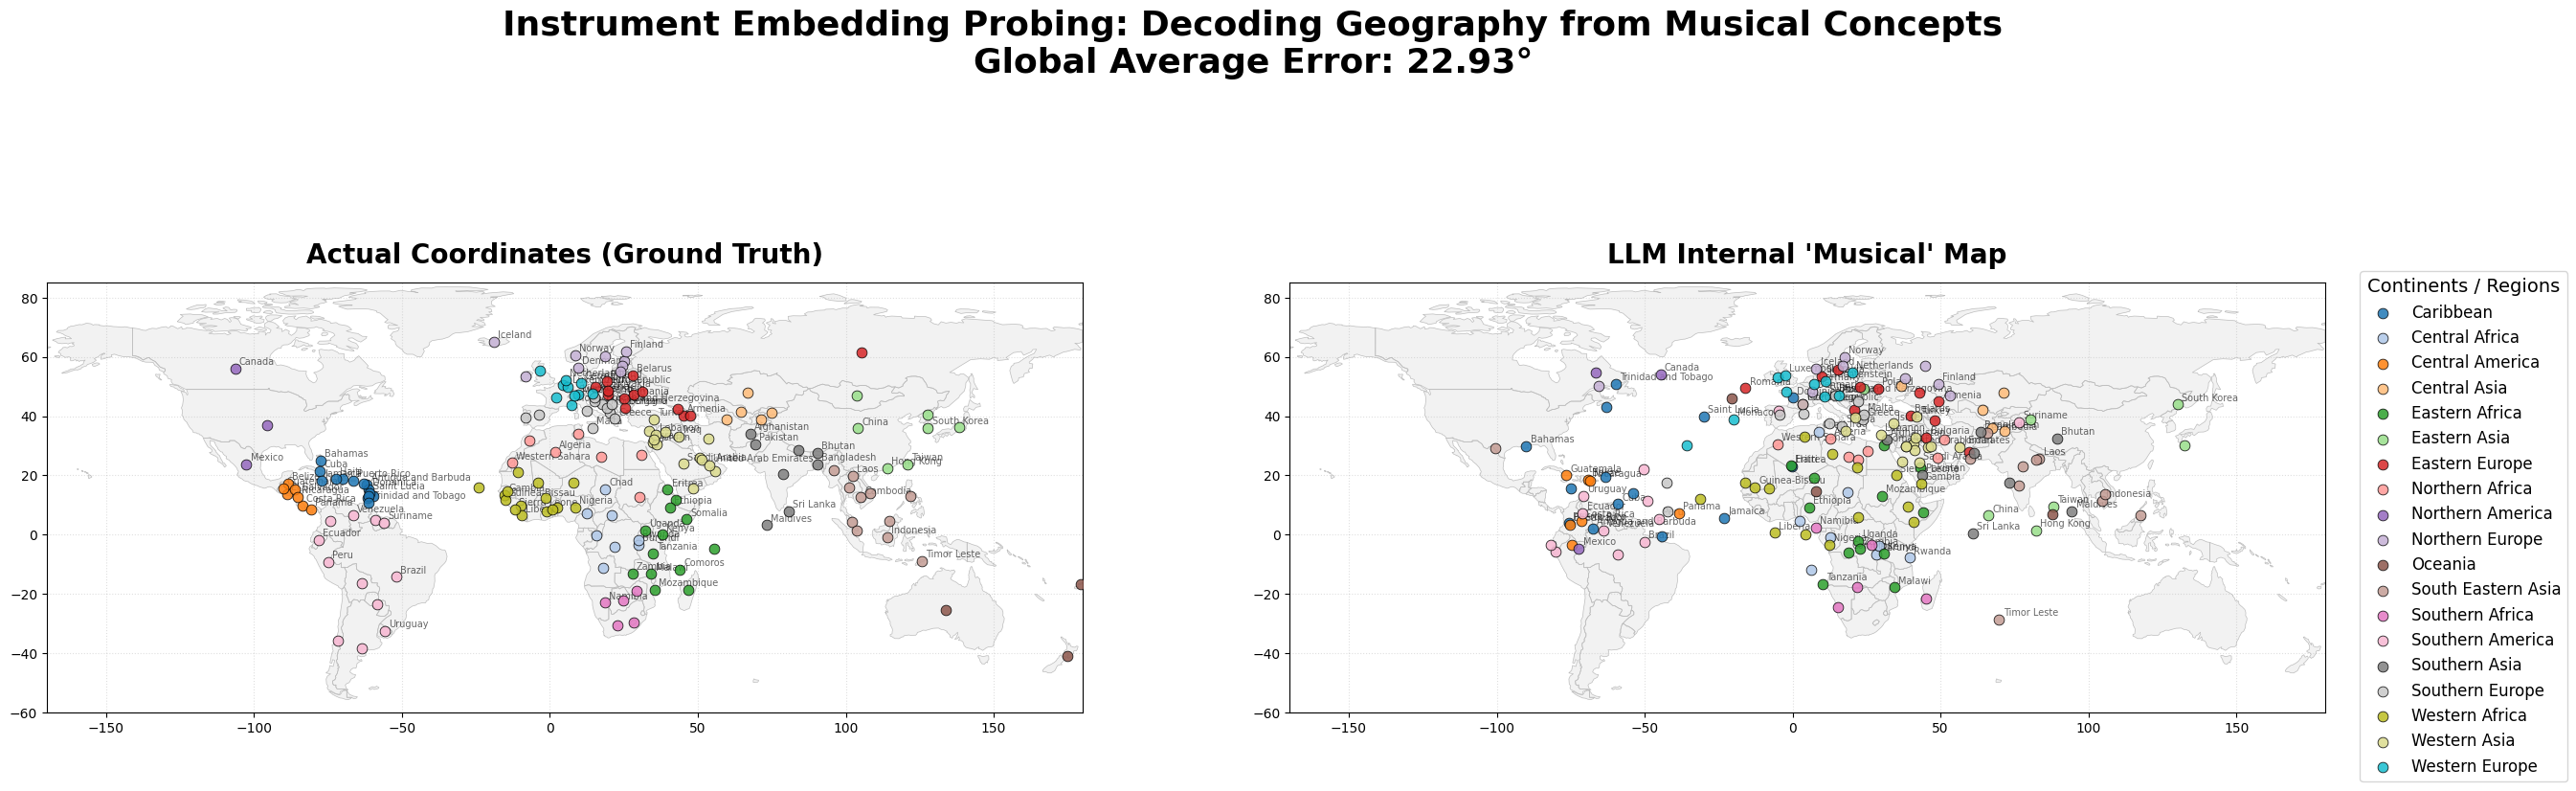

Visualisasi Pure Embedding Probing selesai.


In [13]:
# ============================================================
# EKSPERIMEN A — Probing Linear (Inklusif, Agregat-Negara)
# Menjawab RQ1 untuk jalur analisis utama (pure embedding).
# ============================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import geopandas as gpd

print("=" * 65)
print("EKSPERIMEN A — PROBING LINEAR (INKLUSIF, AGREGAT-NEGARA)")
print("Logika: Instrumen Multiregional berkontribusi ke semua negara asalnya")
print("=" * 65)

TARGET_LAYER = num_layers - 1

# --- KONFIGURASI ---
MIN_INST_THRESHOLD = 5
inst_weights = []
# -------------------

# 1. Mapping Instrumen ke SEMUA Negara Asalnya
print(f"⏳ Mengumpulkan daftar instrumen per negara...")
country_to_inst_map = {} # Ubah nama dari country_to_foods_map

for _, row in instrument_df.iterrows():
    f_name = row['name']
    if f_name not in pure_instrument_cache: continue

    # PERBAIKAN UTAMA: Ganti 'countries' menjadi 'country' sesuai dataset baru
    # _safe_parse_all tetap dipakai untuk handle kasus "Korea" atau "England"
    c_list = _safe_parse_all(row['country'])

    for country in c_list:
        if country.lower() == "global": continue

        if country not in country_to_inst_map:
            country_to_inst_map[country] = []

        # Instrumen akan dimasukkan ke list negara asalnya
        country_to_inst_map[country].append(f_name)

# 2. Hitung Rata-rata Embedding (Profil Akustik/Budaya Negara)
print(f"⏳ Menghitung rata-rata embedding per negara (Threshold: {MIN_INST_THRESHOLD})...")
pure_country_repr = {}
valid_pure_countries = []

for country, insts in country_to_inst_map.items():
    # Hanya proses negara yang punya data koordinat dan jumlah instrumen cukup
    if country in country_coords and len(insts) >= MIN_INST_THRESHOLD:
        # Ambil embedding untuk semua instrumen milik negara tersebut
        embs = [pure_instrument_cache[f] for f in insts]

        # Rata-rata vektor (ini adalah 'titik pusat' karakter musik negara tersebut)
        pure_country_repr[country] = np.mean(embs, axis=0)
        valid_pure_countries.append(country)

# 3. Siapkan Matriks untuk Linear Probing
X_pure_list = []
y_lat_pure = []
y_lon_pure = []

for c in valid_pure_countries:
    X_pure_list.append(pure_country_repr[c])
    y_lat_pure.append(country_coords[c]['lat'])
    y_lon_pure.append(country_coords[c]['lon'])

X_pure = np.array(X_pure_list)
y_lat_pure = np.array(y_lat_pure)
y_lon_pure = np.array(y_lon_pure)

print(f"Data siap: {len(valid_pure_countries)} negara dianalisis.")

# 4. Train & Evaluate (5-Fold CV)
if len(valid_pure_countries) >= 5:
    # FIX: RidgeCV + target sferis, konsisten dengan eksperimen lain.
    probe_model_pure = Pipeline([
        ('scaler', StandardScaler(with_std=False)),
        ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 150.0, 500.0],
                          scoring='neg_mean_absolute_error'))
    ])

    cv_pure = KFold(n_splits=5, shuffle=True, random_state=42)

    y_xyz_pure = latlon_to_xyz(y_lat_pure, y_lon_pure)
    pred_xyz_pure = cross_val_predict(probe_model_pure, X_pure, y_xyz_pure, cv=cv_pure)
    pred_lat_pure, pred_lon_pure = xyz_to_latlon(pred_xyz_pure)

    avg_err_pure = great_circle_deg(y_lat_pure, y_lon_pure, pred_lat_pure, pred_lon_pure).mean()

    print("\n HASIL EVALUASI (PURE EMBEDDING):")
    print(f"Average Global Error: {avg_err_pure:.2f} derajat")
    print(f"Latitude R²: {r2_score(y_lat_pure, pred_lat_pure):.3f}")
    print(f"Longitude R²: {r2_score(y_lon_pure, pred_lon_pure):.3f}")

    # 6. Simpan df_results_pure untuk analisa regional
    df_results_pure = pd.DataFrame({
        "Country": valid_pure_countries,
        "Region": [get_country_region(c) for c in valid_pure_countries],
        "Actual_Lat": y_lat_pure, "Actual_Lon": y_lon_pure,
        "Pred_Lat": pred_lat_pure, "Pred_Lon": pred_lon_pure
    })

# 5. Visualisasi Hasil Prediksi (PETA MAKSIMAL)
    import matplotlib as mpl

    unique_regions_pure = sorted(df_results_pure['Region'].unique())
    cmap = mpl.colormaps.get_cmap('tab20')
    region_colors_pure = {reg: cmap(i % 20) for i, reg in enumerate(unique_regions_pure)}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(28, 12))

    plt.suptitle(f"Instrument Embedding Probing: Decoding Geography from Musical Concepts\nGlobal Average Error: {avg_err_pure:.2f}°",
                 fontsize=26, fontweight='bold', y=0.95)

    for ax, mode, title in zip([ax1, ax2], ["Actual", "Pred"],
                                ["Actual Coordinates (Ground Truth)", "LLM Internal 'Musical' Map"]):
        if world is not None:
            world.boundary.plot(ax=ax, linewidth=0.5, color='#bcbcbc', zorder=1)
            world.plot(ax=ax, color='#f2f2f2', zorder=0)

        for reg in unique_regions_pure:
            reg_data = df_results_pure[df_results_pure['Region'] == reg]
            lons = reg_data['Actual_Lon'] if mode == "Actual" else reg_data['Pred_Lon']
            lats = reg_data['Actual_Lat'] if mode == "Actual" else reg_data['Pred_Lat']

            ax.scatter(lons, lats, color=region_colors_pure[reg], edgecolor='black',
                       linewidth=0.6, s=60, alpha=0.85, label=reg, zorder=5)

        ax.set_title(title, fontsize=20, pad=15, fontweight='semibold')
        ax.set_xlim(-170, 180); ax.set_ylim(-60, 85)
        ax.grid(True, linestyle=':', alpha=0.4)

        for i, row in df_results_pure.reset_index().iterrows():
            if i % 2 == 0:
                tx = row['Actual_Lon'] if mode == "Actual" else row['Pred_Lon']
                ty = row['Actual_Lat'] if mode == "Actual" else row['Pred_Lat']
                ax.annotate(row['Country'], (tx, ty), fontsize=7, alpha=0.6,
                            xytext=(3,3), textcoords='offset points')

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.91, 0.5),
                     fontsize=12, title="Continents / Regions", title_fontsize=14)

    plt.subplots_adjust(left=0.05, right=0.90, top=0.95, bottom=0.1)
    plt.show()

    print(f"Visualisasi Pure Embedding Probing selesai.")
else:
    print(f"Data tidak mencukupi untuk melakukan probing. Coba turunkan MIN_INST_THRESHOLD.")


EKSPERIMEN A — ANALISIS AKURASI REGIONAL
Melihat seberapa akurat 'Citra Rasa' per wilayah
            Region  Count  Avg_Error_Deg  MAE_Lat  MAE_Lon
    Western Europe     10           9.35     4.27    10.83
      Western Asia     15           9.82     3.59     9.93
      Central Asia      5           9.90     4.37    11.11
    Central Africa      8          10.76     4.88     8.54
    Eastern Europe     13          13.42     7.08    16.45
   Northern Europe      9          13.70     5.40    20.48
   Southern Europe     11          14.11     7.42    13.74
   Northern Africa      7          14.94     6.41    14.90
   Southern Africa      5          18.21    13.88     7.71
     Southern Asia      8          20.16     7.29    19.88
   Central America      7          20.45     6.61    18.53
    Western Africa     15          22.54     8.39    19.36
    Eastern Africa     13          23.92    12.68    16.91
         Caribbean     14          29.69    15.81    22.85
      Eastern Asia      

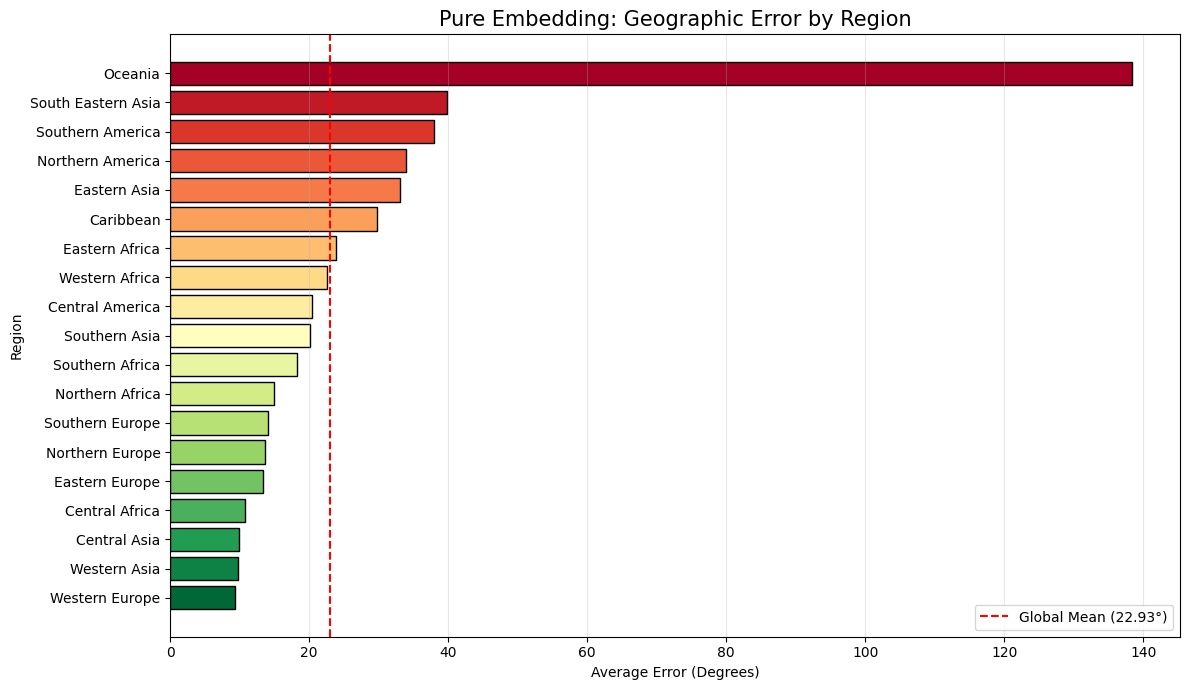

In [14]:
# ============================================================
# EKSPERIMEN A — Analisis Akurasi Regional
# ============================================================

print("\n" + "="*65)
print("EKSPERIMEN A — ANALISIS AKURASI REGIONAL")
print("Melihat seberapa akurat 'Citra Rasa' per wilayah")
print("=" * 65)

regional_stats_pure = []

# Gunakan df_results_pure yang baru saja kita buat di Cell 4.5
for region, group in df_results_pure.groupby("Region"):
    n_samples = len(group)

    # Hitung MAE
    mae_lat_reg = mean_absolute_error(group["Actual_Lat"], group["Pred_Lat"])

    delta_lon = (group["Actual_Lon"] - group["Pred_Lon"]).abs()
    mae_lon_reg = np.minimum(delta_lon, 360 - delta_lon).mean()

    avg_err_reg = great_circle_deg(group["Actual_Lat"], group["Actual_Lon"],
                                    group["Pred_Lat"], group["Pred_Lon"]).mean()

    # Hitung R^2 jika sampel cukup
    if n_samples > 1:
        r2_lat = r2_score(group["Actual_Lat"], group["Pred_Lat"])
        r2_lon = r2_score(group["Actual_Lon"], group["Pred_Lon"])
    else:
        r2_lat, r2_lon = np.nan, np.nan

    regional_stats_pure.append({
        "Region": region,
        "Count": n_samples,
        "Avg_Error_Deg": round(avg_err_reg, 2),
        "MAE_Lat": round(mae_lat_reg, 2),
        "MAE_Lon": round(mae_lon_reg, 2),
    })

# Tampilkan Tabel
df_stats_pure = pd.DataFrame(regional_stats_pure).sort_values("Avg_Error_Deg")
print(df_stats_pure.to_string(index=False))

# Visualisasi Perbandingan Error per Region
plt.figure(figsize=(12, 7))
df_plot_pure = df_stats_pure.sort_values("Avg_Error_Deg", ascending=True)
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(df_plot_pure))) # Hijau ke Merah

plt.barh(df_plot_pure["Region"], df_plot_pure["Avg_Error_Deg"], color=colors, edgecolor='black')
plt.axvline(avg_err_pure, color='red', linestyle='--', label=f'Global Mean ({avg_err_pure:.2f}°)')

plt.title("Pure Embedding: Geographic Error by Region", fontsize=15)
plt.xlabel("Average Error (Degrees)")
plt.ylabel("Region")
plt.grid(axis='x', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# EKSPERIMEN A — Visualisasi Peta Per-Wilayah
# ============================================================

print("\n⏳ Menghasilkan plot peta regional untuk Pure Embeddings...")

# Pastikan menggunakan df_results_pure dari eksperimen 4.5
unique_regions_pure = sorted(df_results_pure['Region'].unique())

for region in unique_regions_pure:
    reg_data = df_results_pure[df_results_pure['Region'] == region].copy()

    # Kita butuh minimal 1 negara untuk diplot
    if len(reg_data) < 1: continue

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

    # Hitung error lokal untuk region ini
    mae_lat_reg = mean_absolute_error(reg_data["Actual_Lat"], reg_data["Pred_Lat"])

    delta_lon = (reg_data["Actual_Lon"] - reg_data["Pred_Lon"]).abs()
    mae_lon_reg = np.minimum(delta_lon, 360 - delta_lon).mean()

    avg_err_reg = great_circle_deg(reg_data["Actual_Lat"], reg_data["Actual_Lon"],
                                    reg_data["Pred_Lat"], reg_data["Pred_Lon"]).mean()

    plt.suptitle(f"REGION DEEP-DIVE: {region.upper()} (PURE EMBEDDING)\n"
                 f"Avg Error: {avg_err_reg:.2f}° | Sample: {len(reg_data)} Countries",
                 fontsize=24, fontweight='bold', y=1.05)

    # Auto-Zoom Logic: Ambil batas dari koordinat asli DAN prediksi
    all_lons = pd.concat([reg_data["Actual_Lon"], reg_data["Pred_Lon"]])
    all_lats = pd.concat([reg_data["Actual_Lat"], reg_data["Pred_Lat"]])

    padding = 8 # Derajat ruang kosong di sekitar titik
    lon_min, lon_max = all_lons.min() - padding, all_lons.max() + padding
    lat_min, lat_max = all_lats.min() - padding, all_lats.max() + padding

    for ax, mode, title, dot_color in zip(
        [ax1, ax2],
        ["Actual", "Pred"],
        [f"Actual Coordinates ({region})", f"LLM Internal 'Flavor' Map"],
        ["#1e90ff", "#ff4757"] # Biru Cerah vs Merah Solid
    ):
        # 1. WARNAI LAUT (Background axis)
        ax.set_facecolor('#d1eefc')

        # 2. GAMBAR DARATAN
        if world is not None:
            # Garis pantai
            world.boundary.plot(ax=ax, linewidth=1, color='#7f8c8d', alpha=0.6, zorder=2)
            # Isi daratan (Putih bersih agar titik menonjol)
            world.plot(ax=ax, color='#fdfdfd', zorder=1)

        # 3. PLOT TITIK NEGARA
        lons = reg_data['Actual_Lon'] if mode == "Actual" else reg_data['Pred_Lon']
        lats = reg_data['Actual_Lat'] if mode == "Actual" else reg_data['Pred_Lat']

        ax.scatter(lons, lats, c=dot_color, edgecolor='black',
                   linewidth=1.2, s=100, alpha=0.9, zorder=5)

        # 4. LABEL NEGARA DENGAN BACKGROUND (Agar terbaca di atas garis pantai)
        for i, row in reg_data.reset_index().iterrows():
            tx = lons.iloc[i]
            ty = lats.iloc[i]
            ax.annotate(row['Country'], (tx, ty),
                        fontsize=11, fontweight='bold',
                        xytext=(6, 6), textcoords='offset points',
                        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1),
                        zorder=6)

        ax.set_title(title, fontsize=18, fontweight='semibold', pad=10)
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.grid(True, linestyle=':', alpha=0.5, color='white', zorder=3)

    plt.tight_layout()

    # Simpan file
    filename = f"pure_probing_{region.replace(' ', '_').lower()}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Plot regional untuk {region} berhasil dibuat (Warna Laut: Biru).")

Output hidden; open in https://colab.research.google.com to view.


BASELINE EKSKLUSIF — PROBING LINEAR (HANYA INSTRUMEN 1-NEGARA)
Logika: Hanya menggunakan instrumen yang memiliki 1 negara eksklusif
HASIL BASELINE (EXCLUSIVE ONLY):
Negara yang memenuhi syarat (min 1 instrumen unik): 172
Average Global Error (Unique): 29.48 derajat
Latitude R² Score: 0.396
Longitude R² Score: 0.494

 ANALISIS PERBANDINGAN:
Error Inclusive (Exp 4.5): 22.93°
Error Exclusive (Exp 4.7): 29.48°
Hasil: Error naik sebesar 6.55° saat menggunakan hanya instrumen unik.


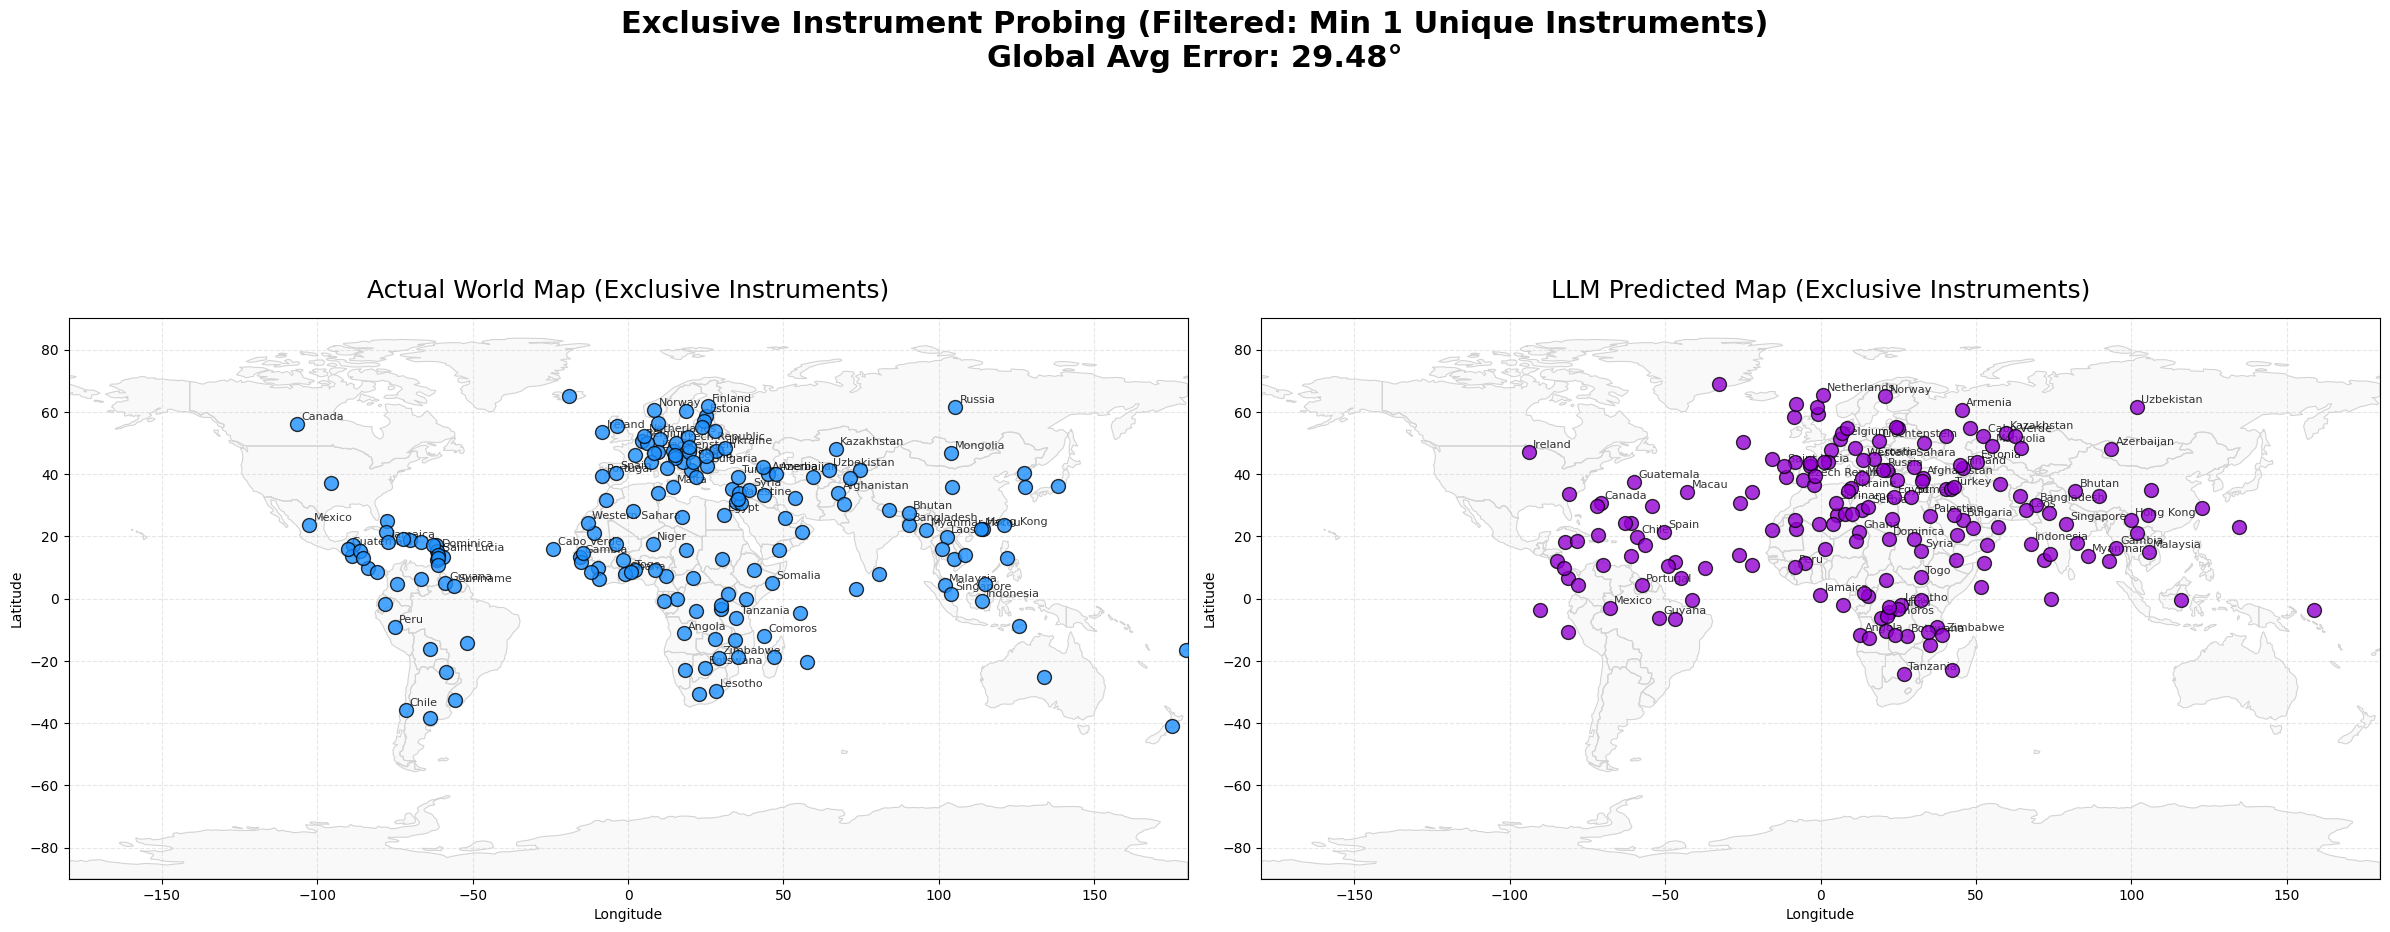

Baseline Dataframe created for 172 exclusive countries.


In [16]:
# ============================================================
# BASELINE EKSKLUSIF — Probing Linear (Hanya Instrumen 1-Negara)
# Tujuan: bandingkan hasil inklusif (Eksperimen A) dengan
# baseline yang hanya memakai instrumen tanpa klaim ganda negara.
# ============================================================

print("\n" + "="*65)
print("BASELINE EKSKLUSIF — PROBING LINEAR (HANYA INSTRUMEN 1-NEGARA)")
print("Logika: Hanya menggunakan instrumen yang memiliki 1 negara eksklusif")
print("=" * 65)

# 1. Identifikasi Instrumen yang Benar-benar Unik (Eksklusif per Negara)
# Kita hitung dulu, setiap instrumen muncul di berapa negara unik
# (Karena format LONG, kita tidak bisa cek per baris saja)
inst_country_counts = {}
for _, row in instrument_df.iterrows():
    f_name = row['name']
    c_list = _safe_parse_all(row['country']) # Ganti 'countries' -> 'country'

    if f_name not in inst_country_counts:
        inst_country_counts[f_name] = set()

    for c in c_list:
        if c.lower() != 'global':
            inst_country_counts[f_name].add(c)

# Ambil hanya instrumen yang jumlah negaranya tepat == 1
exclusive_inst_names = [name for name, countries_set in inst_country_counts.items() if len(countries_set) == 1]

# Masukkan ke dalam map negara
exclusive_country_to_inst = {}
for name in exclusive_inst_names:
    if name not in pure_instrument_cache: continue

    # Ambil satu-satunya negara pemiliknya
    country = list(inst_country_counts[name])[0]

    if country not in exclusive_country_to_inst:
        exclusive_country_to_inst[country] = []
    exclusive_country_to_inst[country].append(name)

# 2. Hitung Rata-rata Embedding untuk Baseline Unik
X_unique = []
y_lat_unique = []
y_lon_unique = []
valid_exclusive_countries = []

MIN_UNIQUE_THRESHOLD = 1 # Minimal 1 instrumen unik untuk sebuah negara diikutkan

for country, insts in exclusive_country_to_inst.items():
    if country in country_coords and len(insts) >= MIN_UNIQUE_THRESHOLD:
        # Hitung mean embedding dari instrumen unik
        embs = [pure_instrument_cache[f] for f in insts]
        X_unique.append(np.mean(embs, axis=0))
        y_lat_unique.append(country_coords[country]['lat'])
        y_lon_unique.append(country_coords[country]['lon'])
        valid_exclusive_countries.append(country)

# 3. Jalankan Linear Probing pada Data Unik
if len(valid_exclusive_countries) >= 5:
    X_u = np.array(X_unique)
    y_lat_u = np.array(y_lat_unique)
    y_lon_u = np.array(y_lon_unique)

    # FIX: RidgeCV + target sferis, konsisten dengan eksperimen lain.
    probe_unique = Pipeline([
        ('scaler', StandardScaler(with_std=False)),
        ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 150.0, 500.0],
                          scoring='neg_mean_absolute_error'))
    ])

    cv_u = KFold(n_splits=5, shuffle=True, random_state=42)

    y_xyz_u = latlon_to_xyz(y_lat_u, y_lon_u)
    pred_xyz_u = cross_val_predict(probe_unique, X_u, y_xyz_u, cv=cv_u)
    pred_lat_u, pred_lon_u = xyz_to_latlon(pred_xyz_u)

    avg_err_unique = great_circle_deg(y_lat_u, y_lon_u, pred_lat_u, pred_lon_u).mean()
    r2_u = r2_score(y_lat_u, pred_lat_u)

    # 4. Tampilkan Perbandingan Hasil
    print(f"HASIL BASELINE (EXCLUSIVE ONLY):")
    print(f"Negara yang memenuhi syarat (min {MIN_UNIQUE_THRESHOLD} instrumen unik): {len(valid_exclusive_countries)}")
    print(f"Average Global Error (Unique): {avg_err_unique:.2f} derajat")
    print(f"Latitude R² Score: {r2_u:.3f}")
    print(f"Longitude R² Score: {r2_score(y_lon_u, pred_lon_u):.3f}")

    print(f"\n ANALISIS PERBANDINGAN:")
    # Membandingkan dengan avg_err_pure dari Experiment 4.5 instrumen
    diff = avg_err_unique - avg_err_pure
    print(f"Error Inclusive (Exp 4.5): {avg_err_pure:.2f}°")
    print(f"Error Exclusive (Exp 4.7): {avg_err_unique:.2f}°")

    if diff > 0:
        print(f"Hasil: Error naik sebesar {diff:.2f}° saat menggunakan hanya instrumen unik.")
    else:
        print(f"Hasil: Error turun sebesar {abs(diff):.2f}°.")

    # ── 5. Visualisasi Hasil Prediksi (Exclusive Only) ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
    plt.suptitle(f"Exclusive Instrument Probing (Filtered: Min {MIN_UNIQUE_THRESHOLD} Unique Instruments)\n"
                 f"Global Avg Error: {avg_err_unique:.2f}°",
                 fontsize=22, fontweight='bold', y=1.05)

    for ax, lons, lats, title, color in zip(
        [ax1, ax2],
        [y_lon_u, pred_lon_u],
        [y_lat_u, pred_lat_u],
        ["Actual World Map (Exclusive Instruments)", "LLM Predicted Map (Exclusive Instruments)"],
        ["dodgerblue", "darkviolet"]
    ):
        if world is not None:
            world.boundary.plot(ax=ax, linewidth=0.8, color='lightgray')
            world.plot(ax=ax, color='whitesmoke', alpha=0.5)

        ax.scatter(lons, lats, c=color, edgecolor='black', s=100, alpha=0.8, zorder=5)
        ax.set_title(title, fontsize=18, pad=15)
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

        for i, c in enumerate(valid_exclusive_countries):
            if i % 3 == 0: # Sampling label agar tidak penuh
                ax.annotate(c, (lons[i], lats[i]), fontsize=8, xytext=(3, 3),
                                textcoords='offset points', alpha=0.8)

    plt.tight_layout()
    plt.show()

    # ── 6. Simpan Dataframe Baseline
    df_results_unique = pd.DataFrame({
        "Country": valid_exclusive_countries,
        "Region": [get_country_region(c) for c in valid_exclusive_countries],
        "Actual_Lat": y_lat_u, "Actual_Lon": y_lon_u,
        "Pred_Lat": pred_lat_u, "Pred_Lon": pred_lon_u
    })
    print(f"Baseline Dataframe created for {len(valid_exclusive_countries)} exclusive countries.")
else:
    print(f"Data unik tidak mencukupi (Hanya ada {len(valid_exclusive_countries)} negara).")


BASELINE EKSKLUSIF — ANALISIS AKURASI REGIONAL
Melihat wilayah mana yang identitas kulinernya paling 'eksklusif'
            Region  Count  Avg_Error_Deg  MAE_Lat  MAE_Lon
    Central Africa      9          14.50     5.70    13.00
   Northern Europe      9          16.68     8.20    22.90
      Western Asia     12          16.73    12.31    12.40
    Western Europe     10          17.17     9.55    18.06
   Southern Europe     10          19.17    10.25    18.50
   Southern Africa      5          19.33    17.18     7.68
   Northern Africa      7          20.11    15.31    13.21
      Central Asia      5          20.35    12.79    21.11
     Southern Asia      7          20.91     8.51    20.00
    Eastern Europe     13          23.57    14.69    21.70
    Eastern Africa     12          27.98    17.47    18.11
   Central America      7          30.70     8.59    29.31
      Eastern Asia      8          34.94     7.37    41.76
  Southern America     12          36.81    25.99    20.36
 

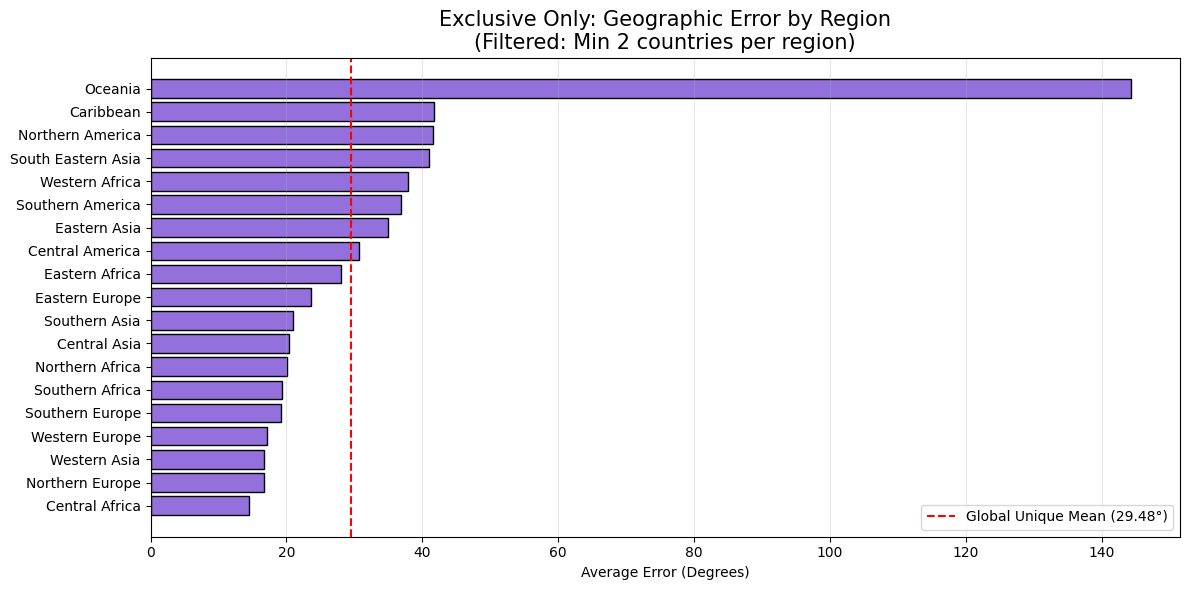

In [17]:
# ============================================================
# BASELINE EKSKLUSIF — Analisis Akurasi Regional
# ============================================================

print("\n" + "="*65)
print("BASELINE EKSKLUSIF — ANALISIS AKURASI REGIONAL")
print("Melihat wilayah mana yang identitas kulinernya paling 'eksklusif'")
print("=" * 65)

regional_stats_unique = []

# Gunakan df_results_unique dari tahap sebelumnya
for region, group in df_results_unique.groupby("Region"):
    n_samples = len(group)

    # Hitung MAE
    mae_lat_reg = mean_absolute_error(group["Actual_Lat"], group["Pred_Lat"])

    delta_lon = (group["Actual_Lon"] - group["Pred_Lon"]).abs()
    mae_lon_reg = np.minimum(delta_lon, 360 - delta_lon).mean()

    avg_err_reg = great_circle_deg(group["Actual_Lat"], group["Actual_Lon"],
                                    group["Pred_Lat"], group["Pred_Lon"]).mean()

    regional_stats_unique.append({
        "Region": region,
        "Count": n_samples,
        "Avg_Error_Deg": round(avg_err_reg, 2),
        "MAE_Lat": round(mae_lat_reg, 2),
        "MAE_Lon": round(mae_lon_reg, 2)
    })

# Tampilkan Tabel
df_stats_unique = pd.DataFrame(regional_stats_unique).sort_values("Avg_Error_Deg")
print(df_stats_unique.to_string(index=False))

# Visualisasi Bar Chart (Hanya jika ada lebih dari 1 region)
if len(df_stats_unique) > 1:
    plt.figure(figsize=(12, 6))
    # Filter: Hanya tampilkan region yang punya minimal 2 negara agar bar chart tidak bias
    df_plot_u = df_stats_unique[df_stats_unique['Count'] >= 2].sort_values("Avg_Error_Deg")

    plt.barh(df_plot_u["Region"], df_plot_u["Avg_Error_Deg"], color='mediumpurple', edgecolor='black')
    plt.axvline(avg_err_unique, color='red', linestyle='--', label=f'Global Unique Mean ({avg_err_unique:.2f}°)')

    plt.title("Exclusive Only: Geographic Error by Region\n(Filtered: Min 2 countries per region)", fontsize=15)
    plt.xlabel("Average Error (Degrees)")
    plt.grid(axis='x', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

EKSPERIMEN B — PROBING LINEAR (INDIVIDUAL PER INSTRUMEN)
Data siap: 2314 titik data instrumen-negara.
   - Instrumen unik  : 1742
   - Multi-negara    : 310 (17.8%)
   - Outlier terbesar: Oud (21 negara)
⏳ Probing 2314 titik dengan GroupKFold(n=5)...
Latitude R² (Eksperimen B): -0.173
Longitude R² (Eksperimen B): -0.053
   Alpha dipilih RidgeCV: 500.0
HASIL PROBING INDIVIDUAL INSTRUMENT:
Average Global Error: 41.80 derajat


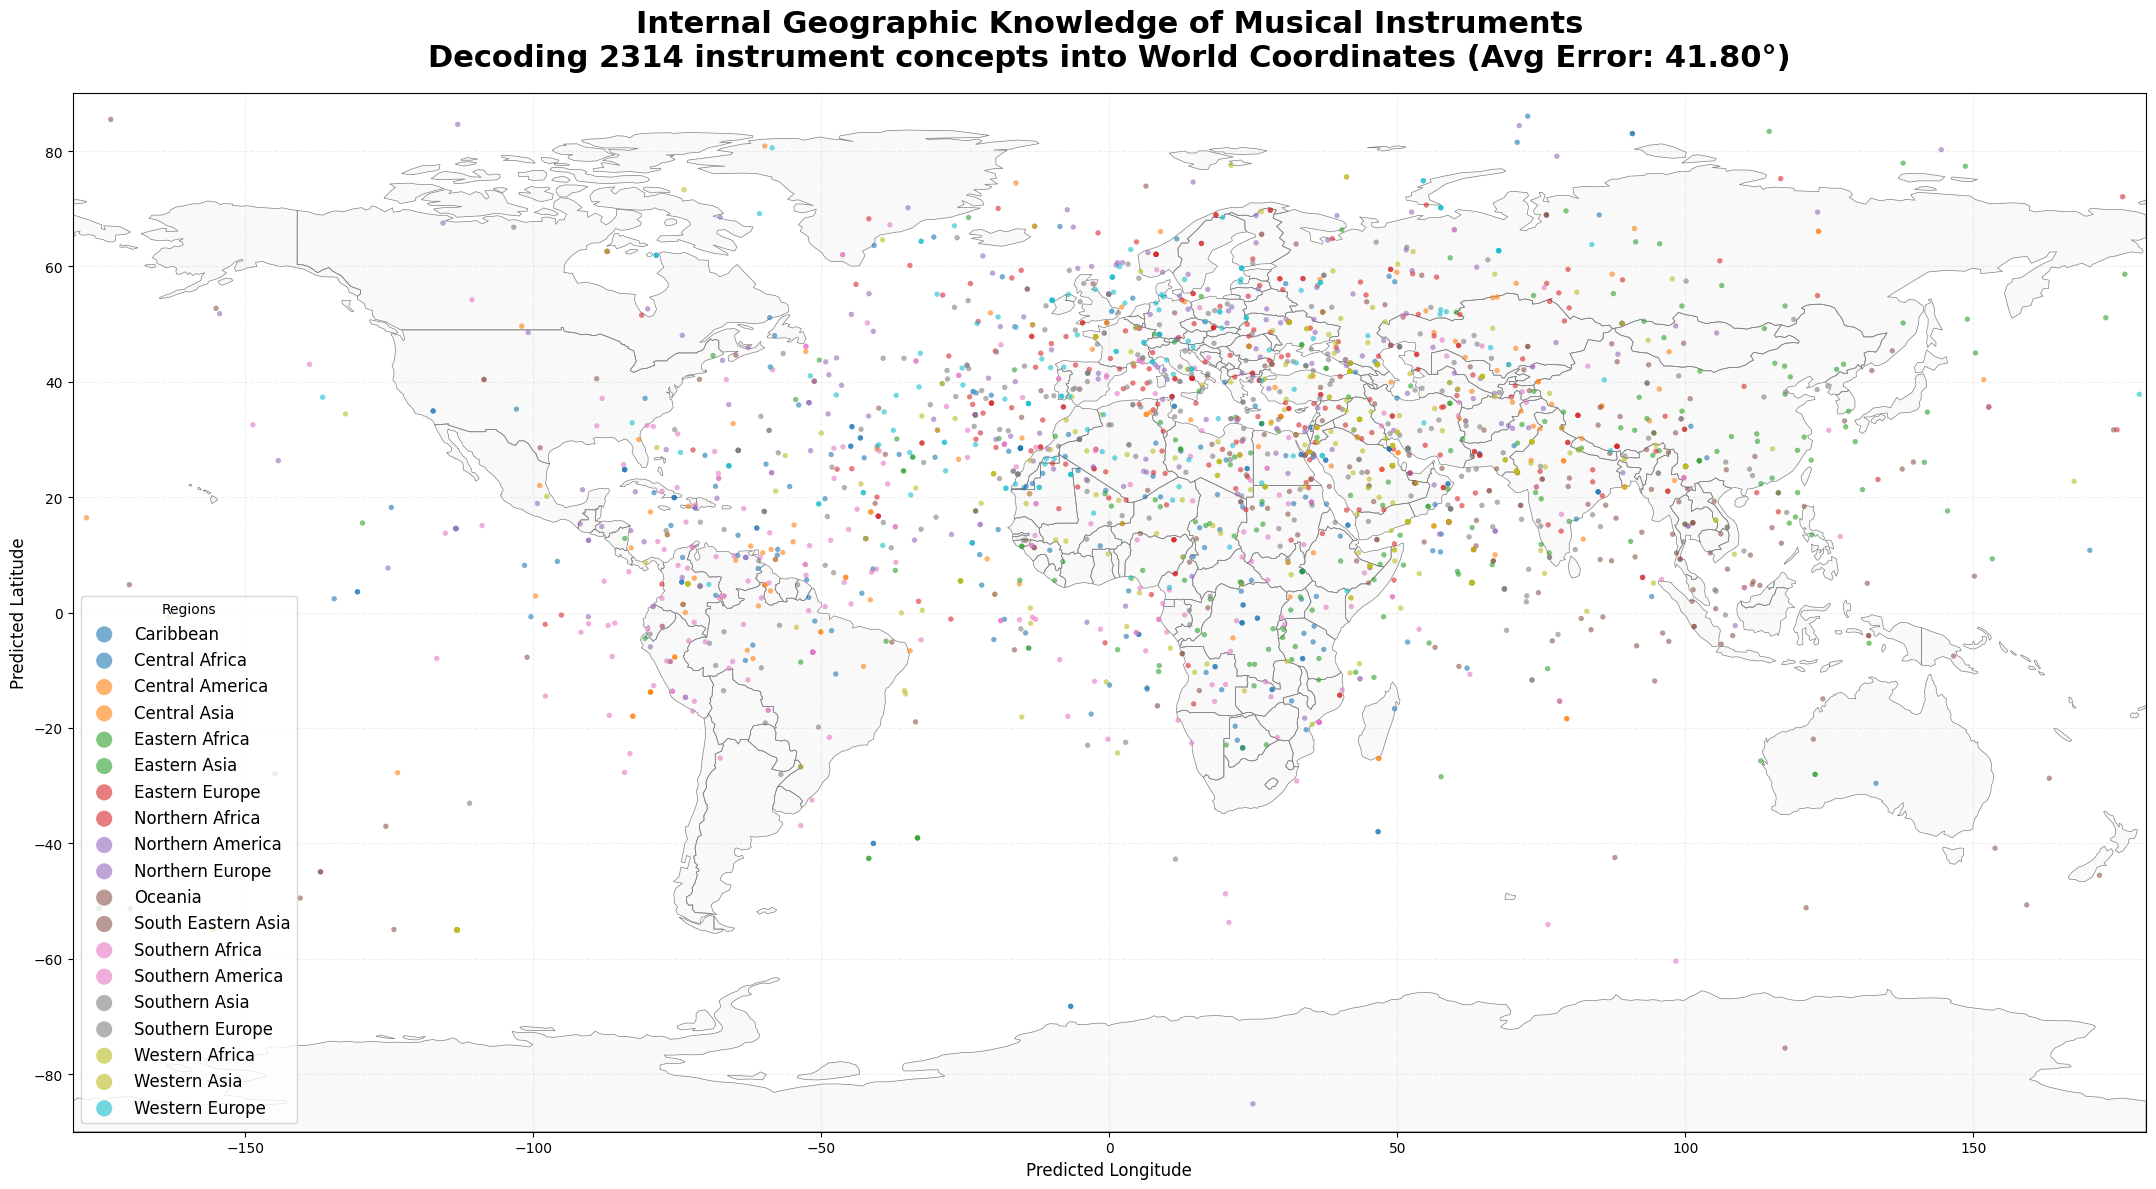

df_inst_points created: 2314 baris.
   Kolom: ['Instrument', 'Country', 'Region', 'Actual_Lat', 'Actual_Lon', 'Pred_Lat', 'Pred_Lon', 'Weight', 'Pred_Lat_Plot', 'Pred_Lon_Plot']


In [18]:
# ============================================================
# EKSPERIMEN B — Probing Linear (Individual per Instrumen)
# Unit analisis: satu baris per pasangan instrumen-negara,
# dibobot 1/N_negara_pengklaim. GroupKFold berbasis identitas
# instrumen untuk mencegah kebocoran data. Basis bagi seluruh
# metrik dekomposisi di Eksperimen C. Menjawab RQ1 dan RQ2.
# ============================================================

from sklearn.linear_model import RidgeCV          # PATCH: ganti Ridge
from sklearn.model_selection import (GroupKFold,  # PATCH: ganti KFold
                                     cross_val_predict)
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from collections import Counter
import matplotlib.pyplot as plt

print("=" * 65)
print("EKSPERIMEN B — PROBING LINEAR (INDIVIDUAL PER INSTRUMEN)")
print("=" * 65)

X_inst          = []
y_lat_inst      = []
y_lon_inst      = []
inst_regions    = []
inst_labels     = []
inst_country_labels = []
inst_weights    = []

# ── 1. Siapkan data pasangan (Vektor Instrumen -> Koordinat Negara) ──
for _, row in instrument_df.iterrows():
    f_name = str(row['name']).strip()
    if f_name not in normalized_cache:
        continue

    # Dataset LONG FORMAT: kolom 'country' (singular), bukan 'countries'
    c_list  = _safe_parse_all(row['country'])
    valid_c = [c for c in c_list if c in country_coords]
    if not valid_c:
        continue

    # PATCH (1): bobot = 1/jumlah_negara_valid
    # Instrumen yang diklaim N negara (mis. Oud = 21 negara) berkontribusi
    # total bobot = 1, setara dengan instrumen yang hanya punya 1 negara.
    weight = 1.0 / len(valid_c)

    for country in valid_c:
        X_inst.append(normalized_cache[f_name])
        y_lat_inst.append(country_coords[country]['lat'])
        y_lon_inst.append(country_coords[country]['lon'])
        inst_regions.append(get_country_region(country))
        inst_labels.append(f_name)
        inst_country_labels.append(country)
        inst_weights.append(weight)

X_i              = np.array(X_inst)
y_lat_i          = np.array(y_lat_inst)
y_lon_i          = np.array(y_lon_inst)
inst_groups      = np.array(inst_labels)      # grup = nama instrumen
inst_weights_arr = np.array(inst_weights)

# Laporan ringkas
name_counts  = Counter(inst_labels)
multi        = sum(1 for v in name_counts.values() if v > 1)
print(f"Data siap: {len(X_i)} titik data instrumen-negara.")
print(f"   - Instrumen unik  : {len(name_counts)}")
print(f"   - Multi-negara    : {multi} ({100*multi/len(name_counts):.1f}%)")
print(f"   - Outlier terbesar: "
      f"{name_counts.most_common(1)[0][0]} "
      f"({name_counts.most_common(1)[0][1]} negara)")

# ── 2. Linear Probing dengan GroupKFold + RidgeCV ──
if len(X_i) > 10:

    # PATCH (2): RidgeCV memilih alpha terbaik via CV internal
    # Rentang mencakup nilai lama (150) sebagai salah satu kandidat
    probe_inst = Pipeline([
        ('scaler', StandardScaler(with_std=False)),
        ('ridge',  RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 150.0, 500.0],
                           scoring='neg_mean_absolute_error'))
    ])

    # PATCH (3): GroupKFold — semua salinan instrumen yang sama selalu
    # di fold yang sama → tidak ada vektor identik di train DAN test
    n_unique_inst = len(np.unique(inst_groups))
    n_splits      = min(5, n_unique_inst)
    cv_i          = GroupKFold(n_splits=n_splits)

    print(f"⏳ Probing {len(X_i)} titik dengan GroupKFold(n={n_splits})...")

    # FIX: target sferis (y_xyz_i), konsisten dengan notebook domain
    # kuliner dan aman terhadap distorsi antimeridian (Bab III.2.4).
    y_xyz_i = latlon_to_xyz(y_lat_i, y_lon_i)
    pred_xyz_i = cross_val_predict(
        probe_inst, X_i, y_xyz_i,
        cv=cv_i, groups=inst_groups,
        params={'ridge__sample_weight': inst_weights_arr}
    )
    pred_lat_i, pred_lon_i = xyz_to_latlon(pred_xyz_i)

    r2_lat_i = r2_score(y_lat_i, pred_lat_i)
    r2_lon_i = r2_score(y_lon_i, pred_lon_i)
    print(f"Latitude R² (Eksperimen B): {r2_lat_i:.3f}")
    print(f"Longitude R² (Eksperimen B): {r2_lon_i:.3f}")

    # Laporan alpha yang dipilih
    probe_inst.fit(X_i, y_xyz_i,
                   ridge__sample_weight=inst_weights_arr)
    chosen_alpha = probe_inst.named_steps['ridge'].alpha_
    print(f"   Alpha dipilih RidgeCV: {chosen_alpha}")

    avg_err_i = great_circle_deg(y_lat_i, y_lon_i, pred_lat_i, pred_lon_i).mean()

    print(f"HASIL PROBING INDIVIDUAL INSTRUMENT:")
    print(f"Average Global Error: {avg_err_i:.2f} derajat")

    # ── 3. Visualisasi Peta Dunia ──
    fig, ax = plt.subplots(figsize=(24, 12))

    if world is not None:
        world.boundary.plot(ax=ax, linewidth=0.5, color='gray', zorder=1)
        world.plot(ax=ax, color='#f9f9f9', zorder=0)

    unique_regs      = sorted(list(set(inst_regions)))
    cmap             = plt.colormaps['tab10']          # hindari deprecation warning
    region_color_map = {reg: cmap(i / len(unique_regs))
                        for i, reg in enumerate(unique_regs)}

    for reg in unique_regs:
        idx = [i for i, r in enumerate(inst_regions) if r == reg]
        ax.scatter(pred_lon_i[idx], pred_lat_i[idx],
                   color=region_color_map[reg],
                   s=15, alpha=0.6, label=reg,
                   edgecolors='none', zorder=5)

    plt.title(
        f"Internal Geographic Knowledge of Musical Instruments\n"
        f"Decoding {len(X_i)} instrument concepts into World Coordinates "
        f"(Avg Error: {avg_err_i:.2f}°)",
        fontsize=22, fontweight='bold', pad=20
    )
    ax.legend(title="Regions", loc='lower left', fontsize=12, markerscale=3)
    ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.set_xlabel("Predicted Longitude", fontsize=12)
    ax.set_ylabel("Predicted Latitude",  fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.2)
    plt.tight_layout()
    plt.savefig("instrument_concept_world_map.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ── 4. Bangun DataFrame untuk Eks 6 ──
    df_inst_points = pd.DataFrame({
        'Instrument': inst_labels,
        'Country':    inst_country_labels,
        'Region':     inst_regions,
        'Actual_Lat': y_lat_i,
        'Actual_Lon': y_lon_i,
        'Pred_Lat':   pred_lat_i,
        'Pred_Lon':   pred_lon_i,
        'Weight':     inst_weights,           # simpan bobot untuk referensi
    })

    # Anti-halu clipping (untuk visualisasi saja, bukan untuk Eks 6)
    df_inst_points['Pred_Lat_Plot'] = df_inst_points['Pred_Lat'].clip(-90, 90)
    df_inst_points['Pred_Lon_Plot'] = df_inst_points['Pred_Lon'].clip(-180, 180)

    print(f"df_inst_points created: {len(df_inst_points)} baris.")
    print(f"   Kolom: {df_inst_points.columns.tolist()}")

else:
    print("Data tidak cukup untuk probing.")

In [19]:
# ============================================================
# EKSPERIMEN B — Konstruksi DataFrame Per-Instrumen
# Menyusun ulang hasil Eksperimen B dengan kolom 'Country' agar
# bisa difilter per negara (dipakai visualisasi Cell 19-20).
# ============================================================

inst_country_labels = []
X_inst_list, y_lat_inst_list, y_lon_inst_list, inst_regions_list, inst_labels_list = [], [], [], [], []

for _, row in instrument_df.iterrows():
    f_name = str(row['name']).strip()
    if f_name not in normalized_cache: continue

    # PERBAIKAN: Gunakan kolom 'country'
    c_list = _safe_parse_all(row['country'])

    for country in c_list:
        if country in country_coords:
            X_inst_list.append(normalized_cache[f_name])
            y_lat_inst_list.append(country_coords[country]['lat'])
            y_lon_inst_list.append(country_coords[country]['lon'])
            inst_regions_list.append(get_country_region(country))
            inst_labels_list.append(f_name)
            inst_country_labels.append(country)

# PERBAIKAN: Gunakan variabel pred_lat_i dan pred_lon_i dari hasil Probing Instrumen
df_inst_points = pd.DataFrame({
    'Instrument': inst_labels_list,
    'Country': inst_country_labels,
    'Region': inst_regions_list,
    'Actual_Lat': y_lat_inst_list, 'Actual_Lon': y_lon_inst_list,
    'Pred_Lat': pred_lat_i,  # Diambil dari Exp 4.9
    'Pred_Lon': pred_lon_i   # Diambil dari Exp 4.9
})

# Clipping anti-halu (Agar titik tidak keluar dari batas peta dunia)
df_inst_points['Pred_Lat_Plot'] = df_inst_points['Pred_Lat'].clip(-90, 90)
df_inst_points['Pred_Lon_Plot'] = df_inst_points['Pred_Lon'].clip(-180, 180)

print(f"Dataframe df_inst_points berhasil dibuat dengan {len(df_inst_points)} baris.")

Dataframe df_inst_points berhasil dibuat dengan 2314 baris.


In [20]:
# ============================================================
# EKSPERIMEN B — Visualisasi Peta Per-Wilayah (Poster Style)
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

print("=" * 65)
print("EKSPERIMEN B — VISUALISASI PETA PER-WILAYAH (POSTER STYLE)")
print("Generating full-width instrument maps...")
print("=" * 65)

# 1. Gunakan Koordinat yang sudah di-CLIP (Anti-Halu) dari df_inst_points
df_inst_points['Pred_Lat_Plot'] = df_inst_points['Pred_Lat'].clip(-85, 85)
df_inst_points['Pred_Lon_Plot'] = df_inst_points['Pred_Lon'].clip(-180, 180)

# Ambil region unik dari dataframe instrumen
unique_regions_i = sorted(df_inst_points['Region'].unique())

for region in unique_regions_i:
    reg_data = df_inst_points[df_inst_points['Region'] == region].copy()
    if len(reg_data) < 2: continue # Minimal 2 instrumen untuk di-plot

    # 2. Setup Figure (Widescreen 20:10)
    fig, ax = plt.subplots(figsize=(20, 10))

    # Hitung error lokal
    avg_err_reg = great_circle_deg(reg_data["Actual_Lat"], reg_data["Actual_Lon"],
                                 reg_data["Pred_Lat"], reg_data["Pred_Lon"]).mean()

    # 3. Auto-Zoom Logic
    padding_lon = 20
    padding_lat = 15
    lon_min, lon_max = reg_data["Pred_Lon_Plot"].min() - padding_lon, reg_data["Pred_Lon_Plot"].max() + padding_lon
    lat_min, lat_max = reg_data["Pred_Lat_Plot"].min() - padding_lat, reg_data["Pred_Lat_Plot"].max() + padding_lat

    # 4. Estetika Peta
    ax.set_facecolor('#aad3df') # Warna Biru Laut
    if world is not None:
        world.boundary.plot(ax=ax, linewidth=0.7, color='#5a5a5a', alpha=0.4, zorder=2)
        world.plot(ax=ax, color='#f9f4e8', zorder=1) # Warna Daratan

    # 5. Plot Titik Instrumen
    # Menggunakan region_color_map yang didefinisikan di Experiment 4.9
    current_color = region_color_map.get(region, "dodgerblue")
    ax.scatter(reg_data['Pred_Lon_Plot'], reg_data['Pred_Lat_Plot'],
               color=current_color, edgecolor='black',
               linewidth=0.5, s=60, alpha=0.8, zorder=5)

    # 6. Labeling (Sampling acak agar tidak terlalu penuh)
    # Menampilkan maksimal 15 label instrumen per region agar tetap rapi
    n_labels = min(15, len(reg_data))
    labeled_samples = reg_data.sample(n_labels, random_state=42)

    for i, row in labeled_samples.iterrows():
        # PERBAIKAN: Menggunakan row['Instrument'] sesuai dataframe baru
        ax.annotate(row['Instrument'], (row['Pred_Lon_Plot'], row['Pred_Lat_Plot']),
                    fontsize=10, fontweight='bold', color='#2c3e50',
                    xytext=(4, 4), textcoords='offset points',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.8),
                    zorder=6)

    # 7. MAKSIMALISASI AREA
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xticks([])
    ax.set_yticks([])

    # Overlay Judul (Musical Instrument Map)
    ax.text(0.5, 0.96, f"INTERNAL MUSICAL INSTRUMENT MAP: {region.upper()}",
            transform=ax.transAxes, fontsize=22, fontweight='bold',
            ha='center', va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=5))

    ax.text(0.5, 0.91, f"Individual Instrument Probing | Avg Spacial Deviation: {avg_err_reg:.2f}°",
            transform=ax.transAxes, fontsize=14, ha='center', va='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

    plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

    # Simpan file dengan nama yang relevan
    filename = f"instrument_map_full_{region.replace(' ', '_').lower()}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight', pad_inches=0)
    plt.show()

    print(f"Full-map untuk region {region} berhasil dibuat.")

Output hidden; open in https://colab.research.google.com to view.

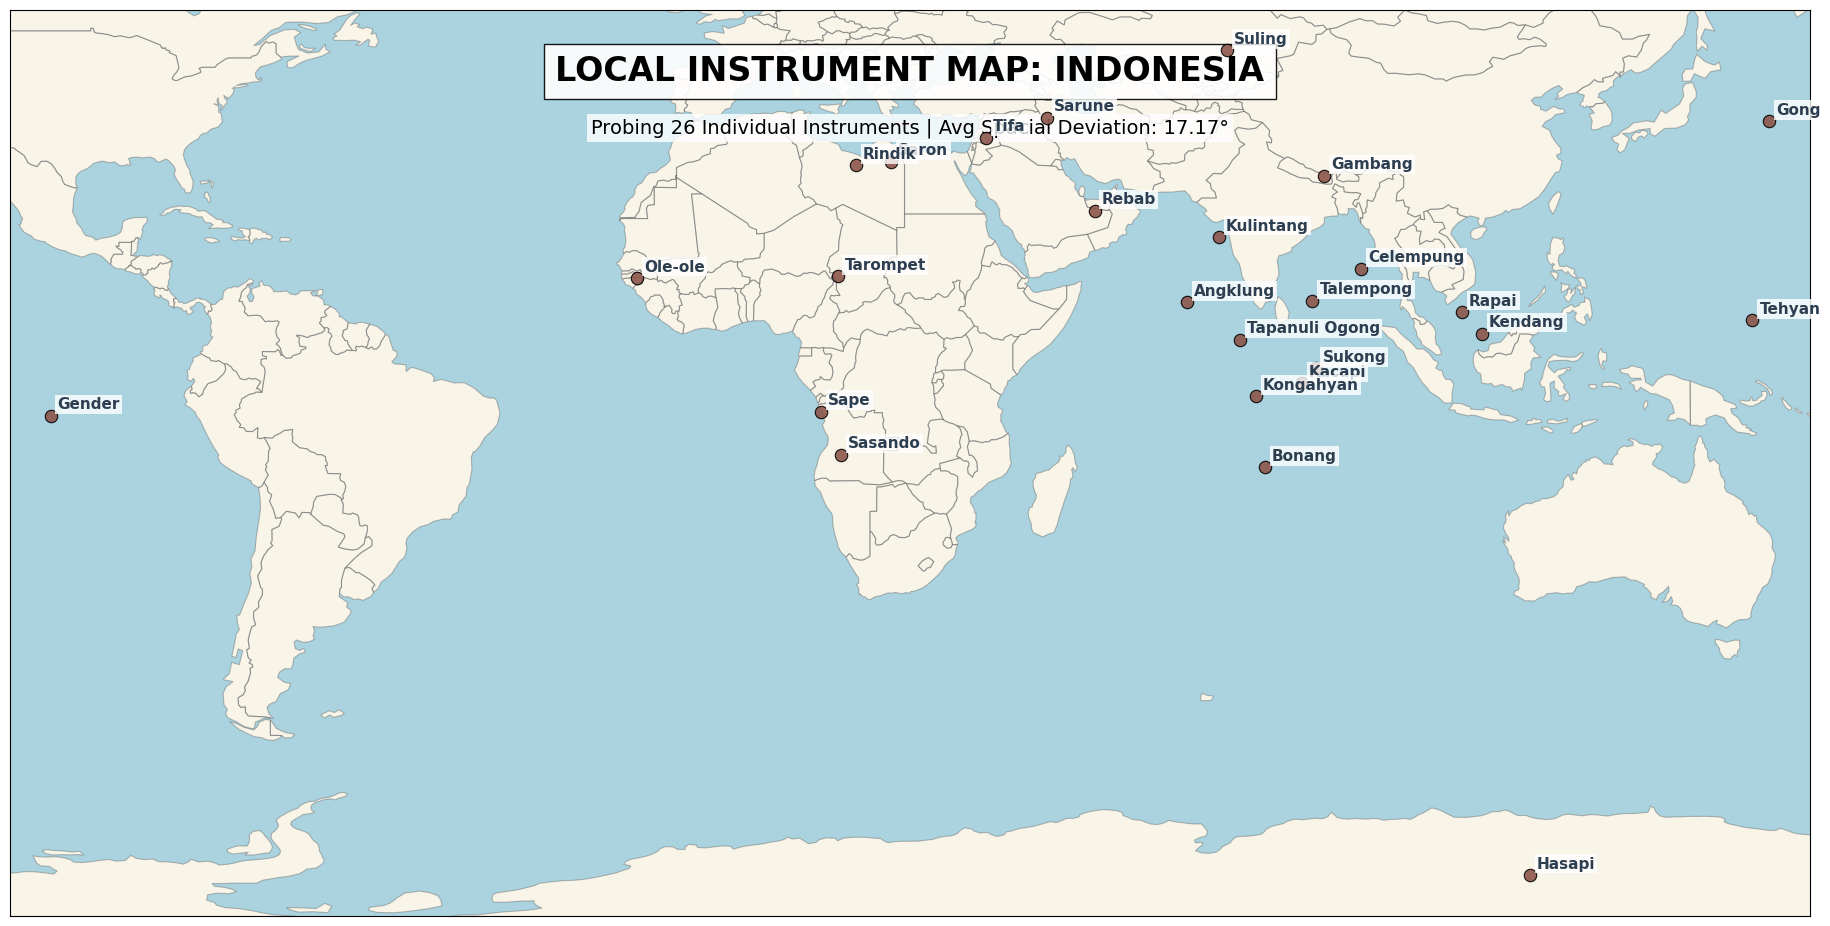

In [21]:
# ============================================================
# EKSPERIMEN B — Fungsi Visualisasi Peta Per-Negara
# Dipanggil manual dengan nama negara untuk inspeksi kualitatif.
# ============================================================

def plot_instrument_map_by_country(target_country):
    # 1. Filter data menggunakan dataframe instrumen (df_inst_points)
    country_data = df_inst_points[df_inst_points['Country'].str.lower() == target_country.lower()].copy()

    if len(country_data) == 0:
        print(f"Negara '{target_country}' tidak ditemukan atau tidak memiliki data instrumen.")
        return

    # 2. Setup Plot (Poster Style)
    fig, ax = plt.subplots(figsize=(18, 10))

    # 3. Hitung Error lokal (Spacial Deviation)
    avg_err_reg = great_circle_deg(group["Actual_Lat"], group["Actual_Lon"],
                                 group["Pred_Lat"], group["Pred_Lon"]).mean()

    # 4. Auto-Zoom: Fokus pada sebaran instrumen negara tersebut
    padding = 6
    lon_min, lon_max = country_data["Pred_Lon_Plot"].min() - padding, country_data["Pred_Lon_Plot"].max() + padding
    lat_min, lat_max = country_data["Pred_Lat_Plot"].min() - padding, country_data["Pred_Lat_Plot"].max() + padding

    # 5. Estetika Peta
    ax.set_facecolor('#aad3df') # Warna Laut
    if world is not None:
        world.boundary.plot(ax=ax, linewidth=0.8, color='#5a5a5a', alpha=0.4, zorder=2)
        world.plot(ax=ax, color='#f9f4e8', zorder=1) # Warna Daratan

    # 6. Plot Titik Instrumen
    region_name = country_data['Region'].iloc[0]
    # Menggunakan color map yang sudah dibuat di Experiment 4.9
    dot_color = region_color_map.get(region_name, "dodgerblue")

    ax.scatter(country_data['Pred_Lon_Plot'], country_data['Pred_Lat_Plot'],
               color=dot_color, edgecolor='black', linewidth=0.8, s=80, alpha=0.9, zorder=5)

    # 7. Labeling: Tampilkan SEMUA instrumen milik negara tersebut
    for i, row in country_data.iterrows():
        # PERBAIKAN: Gunakan row['Instrument']
        ax.annotate(row['Instrument'], (row['Pred_Lon_Plot'], row['Pred_Lat_Plot']),
                    fontsize=11, fontweight='bold', color='#2c3e50',
                    xytext=(5, 5), textcoords='offset points',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1.5),
                    zorder=6)

    # 8. Maksimalisasi Area
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xticks([]); ax.set_yticks([])

    # 9. Judul Overlay (Musical/Instrument Context)
    ax.text(0.5, 0.95, f"LOCAL INSTRUMENT MAP: {target_country.upper()}",
            transform=ax.transAxes, fontsize=24, fontweight='bold',
            ha='center', va='top', bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', pad=8))

    ax.text(0.5, 0.88, f"Probing {len(country_data)} Individual Instruments | Avg Spacial Deviation: {avg_err_reg:.2f}°",
            transform=ax.transAxes, fontsize=14, ha='center', va='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))

    plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
    plt.show()

# --- CARA PAKAI ---
# Sekarang Anda bisa memanggil instrumen per negara
plot_instrument_map_by_country("Indonesia")
# plot_instrument_map_by_country("Afghanistan")
# plot_instrument_map_by_country("Japan")

In [22]:
# ============================================================
# EKSPERIMEN C — Utilitas Geometri Sferis
# Menggantikan komputasi Euclidean lat/lon mentah untuk
# Eksperimen C: konversi ke vektor satuan 3D, great-circle
# distance, centroid sferis, dan dekomposisi vektor galat
# berbasis azimuth eksak (lihat Bab III.2.4 dan III.3.4).
# FIX: great_circle_error_vector ditambahkan, diporting dari
# notebook domain kuliner, supaya kedua domain memakai pipeline
# geometris yang identik (lihat Bab III.2.2).
# ============================================================

R_EARTH_KM = 6371.0

def latlon_to_xyz(lat_deg, lon_deg):
    """Konversi (lat, lon) derajat → vektor satuan 3D."""
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return np.stack([x, y, z], axis=-1)   # shape (..., 3)

def xyz_to_latlon(xyz):
    """Konversi vektor 3D → (lat_deg, lon_deg). xyz tidak harus satuan."""
    xyz = xyz / np.linalg.norm(xyz, axis=-1, keepdims=True)
    lat = np.degrees(np.arcsin(np.clip(xyz[..., 2], -1, 1)))
    lon = np.degrees(np.arctan2(xyz[..., 1], xyz[..., 0]))
    return lat, lon

def spherical_centroid(lat_arr, lon_arr):
    """
    Centroid sferis: rata-rata vektor 3D lalu normalisasi.
    Benar untuk data tersebar di bola; kebal antimeridian.
    """
    xyz = latlon_to_xyz(np.array(lat_arr), np.array(lon_arr))
    mean_xyz = xyz.mean(axis=0)
    mean_xyz /= np.linalg.norm(mean_xyz)
    return xyz_to_latlon(mean_xyz)   # (lat_deg, lon_deg)

def great_circle_km(lat1, lon1, lat2, lon2):
    """Jarak great-circle dalam km. Scalar atau array."""
    xyz1 = latlon_to_xyz(np.array(lat1), np.array(lon1))
    xyz2 = latlon_to_xyz(np.array(lat2), np.array(lon2))
    dot = np.clip((xyz1 * xyz2).sum(axis=-1), -1.0, 1.0)
    return R_EARTH_KM * np.arccos(dot)

def great_circle_deg(lat1, lon1, lat2, lon2):
    """Jarak great-circle dalam derajat (untuk kompatibilitas laporan lama)."""
    return np.degrees(great_circle_km(lat1, lon1, lat2, lon2) / R_EARTH_KM)

def great_circle_error_vector(pred_lat, pred_lon, actual_lat, actual_lon):
    """
    Vektor galat (utara, timur) berbasis azimuth eksak + jarak great-circle.
    Valid untuk sembarang besar sudut, tidak mengasumsikan sudut kecil,
    dan aman terhadap distorsi antimeridian.
    """
    lat1 = np.radians(actual_lat)
    lat2 = np.radians(pred_lat)
    dlon = np.radians(pred_lon - actual_lon)

    dist = great_circle_deg(actual_lat, actual_lon, pred_lat, pred_lon)

    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    bearing = np.arctan2(x, y)   # azimuth eksak dari titik aktual ke titik prediksi

    north_err = dist * np.cos(bearing)
    east_err = dist * np.sin(bearing)
    return north_err, east_err

EKSPERIMEN C.1 — CENTROID PREDIKSI PER WILAYAH
Apakah region dengan error tinggi punya centroid prediksi
yang sama (fallback) atau berbeda-beda (genuine hybridity)?
Data individual prediction: 2314 baris artefak.

 CENTROID PREDIKSI PER REGION (diurutkan dari error tertinggi):
            Region  N_Artifacts  Pred_Centroid_Lat  Pred_Centroid_Lon  Actual_Centroid_Lat  Actual_Centroid_Lon  Pred_Spread  Avg_Error
           Oceania           32          36.654242          63.120655           -31.548551           162.845954    89.117949  92.887266
  Southern America          218          20.557611         -30.406227           -10.689190           -65.807841    54.499741  60.560507
   Central America           74          19.771931         -43.845406            13.377420           -86.216545    54.693449  55.481114
         Caribbean          129          36.412123         -34.977341            17.395202           -67.787580    54.008740  53.191916
  Northern America           47          4

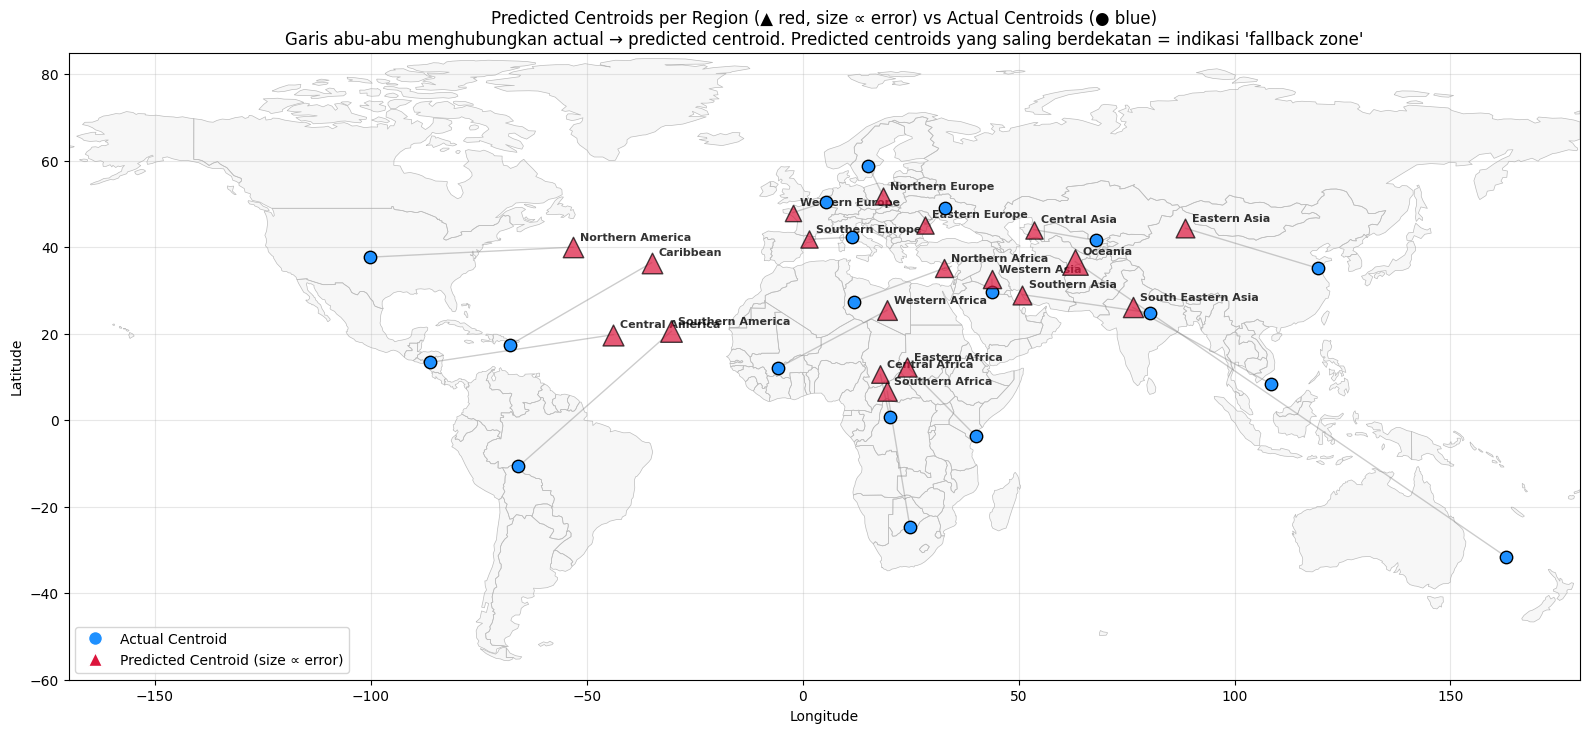


EKSPERIMEN C.1 — KLASIFIKASI MEKANISME ERROR PER WILAYAH

 KLASIFIKASI MEKANISME PER REGION:
            Region  N_Artifacts  Avg_Error  Pred_Spread                             Mechanism
           Oceania           32  92.887266    89.117949 Representational Fallback / Misplaced
  Southern America          218  60.560507    54.499741 Representational Fallback / Misplaced
   Central America           74  55.481114    54.693449 Representational Fallback / Misplaced
         Caribbean          129  53.191916    54.008740 Representational Fallback / Misplaced
  Northern America           47  52.299217    51.424753 Representational Fallback / Misplaced
South Eastern Asia          159  50.870109    51.105322 Representational Fallback / Misplaced
    Western Africa          128  47.785307    52.243856 Representational Fallback / Misplaced
   Southern Africa           41  45.824967    47.338257 Representational Fallback / Misplaced
    Eastern Africa          104  43.242765    45.692596     

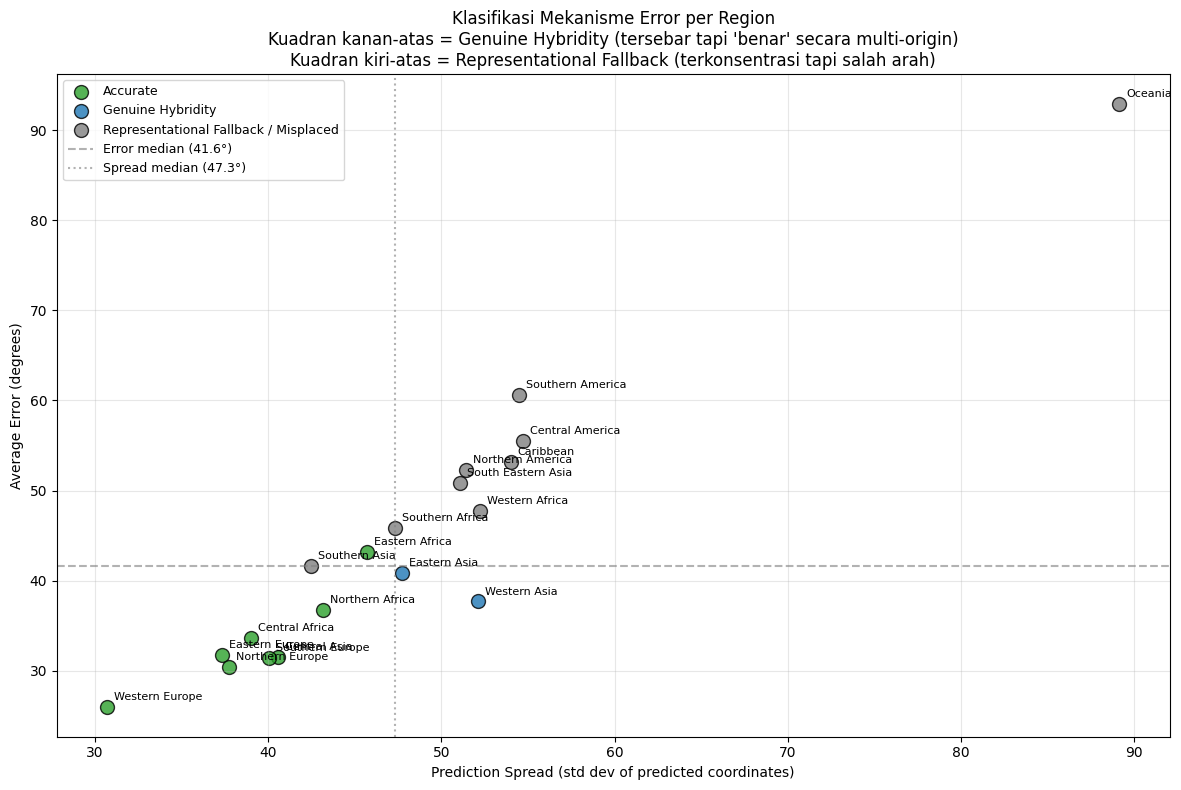


 RINGKASAN AKHIR:

   Genuine Hybridity (2 region):
      - Eastern Asia
      - Western Asia

   Representational Fallback / Misplaced (9 region):
      - Oceania
      - Southern America
      - Central America
      - Caribbean
      - Northern America
      - South Eastern Asia
      - Western Africa
      - Southern Africa
      - Southern Asia

   Accurate (8 region):
      - Eastern Africa
      - Northern Africa
      - Central Africa
      - Eastern Europe
      - Central Asia
      - Southern Europe
      - Northern Europe
      - Western Europe

 EXPERIMENT 6 SELESAI.

Catatan interpretasi:
- 'Genuine Hybridity': error tinggi WAJAR karena artefak budaya
  region ini memang historis berasal dari banyak tempat berbeda.
  -> metrik single-point lat/lon TIDAK ADIL untuk region ini.
- 'Representational Fallback': error tinggi karena model TIDAK
  PUNYA representasi spesifik, prediksi 'jatuh' ke satu zona
  default yang sempit (mungkin sama dengan region lain).
  -> ini indikasi 

In [23]:
# ============================================================
# EKSPERIMEN C.1 — Centroid Regional dan Klasifikasi Mekanisme
# Objective:
#   Membedakan dua mekanisme error tinggi:
#   (A) "Genuine Hybridity"         -> prediksi tersebar mengikuti
#                                       realitas multi-origin artefak
#   (B) "Representational Fallback" -> prediksi konvergen ke satu
#                                       "zona default" global, terlepas
#                                       dari artefaknya
#
# Sumber data: df_inst_points, hasil Eksperimen B (Cell 18),
# dengan kolom wajib: Region, Pred_Lat, Pred_Lon, Actual_Lat,
# Actual_Lon.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

print("=" * 65)
print("EKSPERIMEN C.1 — CENTROID PREDIKSI PER WILAYAH")
print("Apakah region dengan error tinggi punya centroid prediksi")
print("yang sama (fallback) atau berbeda-beda (genuine hybridity)?")
print("=" * 65)

# ------------------------------------------------------------
# Sumber data: df_inst_points (hasil Eksperimen B, Cell 18).
# Wilayah "Other" (tidak terklasifikasi region PBB) dikeluarkan.
# ------------------------------------------------------------

df_ind = df_inst_points.copy()
df_ind = df_ind[df_ind["Region"] != "Other"]

required_cols = {'Region', 'Pred_Lat', 'Pred_Lon', 'Actual_Lat', 'Actual_Lon'}
missing = required_cols - set(df_ind.columns)
assert not missing, f"Kolom berikut tidak ditemukan di df_results_individual: {missing}"

print(f"Data individual prediction: {len(df_ind)} baris artefak.")

# ------------------------------------------------------------
# 6.1.B — Hitung centroid predicted & actual per region
# ------------------------------------------------------------
centroid_records = []

for region, group in df_ind.groupby("Region"):
    if len(group) < 2:
        continue

    pred_centroid_lat, pred_centroid_lon = spherical_centroid(
        group["Pred_Lat"].values, group["Pred_Lon"].values)
    actual_centroid_lat, actual_centroid_lon = spherical_centroid(
        group["Actual_Lat"].values, group["Actual_Lon"].values)

    per_item_error = great_circle_deg(
        group["Actual_Lat"].values, group["Actual_Lon"].values,
        group["Pred_Lat"].values,   group["Pred_Lon"].values
    )
    avg_error = per_item_error.mean()

    # Pred_Spread: seberapa tersebar prediksi dalam region ini
    dist_to_pred_centroid = great_circle_deg(
        group["Pred_Lat"].values, group["Pred_Lon"].values,
        np.full(len(group), pred_centroid_lat),
        np.full(len(group), pred_centroid_lon)
    )
    pred_spread = np.sqrt(np.mean(dist_to_pred_centroid**2))

    centroid_records.append({
        "Region": region,
        "N_Artifacts": len(group),
        "Pred_Centroid_Lat": pred_centroid_lat,
        "Pred_Centroid_Lon": pred_centroid_lon,
        "Actual_Centroid_Lat": actual_centroid_lat,
        "Actual_Centroid_Lon": actual_centroid_lon,
        "Pred_Spread": pred_spread,
        "Avg_Error": avg_error,
    })

df_centroids = pd.DataFrame(centroid_records).sort_values("Avg_Error", ascending=False)
print("\n CENTROID PREDIKSI PER REGION (diurutkan dari error tertinggi):")
print(df_centroids.to_string(index=False))

df_centroids['Centroid_Distance'] = great_circle_deg(
    df_centroids['Actual_Centroid_Lat'].values,
    df_centroids['Actual_Centroid_Lon'].values,
    df_centroids['Pred_Centroid_Lat'].values,
    df_centroids['Pred_Centroid_Lon'].values
)

print("\n CENTROID DISTANCE (Actual vs Predicted) per Region:")
print(df_centroids[['Region', 'Centroid_Distance', 'Pred_Spread', 'Avg_Error']]
      .sort_values('Centroid_Distance', ascending=False)
      .to_string(index=False))

# ------------------------------------------------------------
# 6.1.C — Cek "Global Fallback Zone" Hypothesis
# Hitung jarak antar pred_centroid region-region berbeda.
# Jika region-region ber-error-tinggi punya pred_centroid yang
# SALING BERDEKATAN (clustered), maka mendukung hipotesis fallback.
# ------------------------------------------------------------
high_error_regions = df_centroids[df_centroids["Avg_Error"] > df_centroids["Avg_Error"].median()]
low_error_regions = df_centroids[df_centroids["Avg_Error"] <= df_centroids["Avg_Error"].median()]

print(f"\n⏳ Membandingkan dispersi centroid prediksi:")
print(f"   High-error regions (n={len(high_error_regions)}): "
      f"{high_error_regions['Region'].tolist()}")
print(f"   Low-error regions  (n={len(low_error_regions)}): "
      f"{low_error_regions['Region'].tolist()}")

def centroid_dispersion(df_subset):
    """Rata-rata jarak pairwise antar centroid prediksi (lat/lon)."""
    coords = df_subset[["Pred_Centroid_Lat", "Pred_Centroid_Lon"]].values
    if len(coords) < 2:
        return np.nan
    dists = cdist(coords, coords)
    # ambil upper triangle (tanpa diagonal)
    iu = np.triu_indices_from(dists, k=1)
    return dists[iu].mean()

disp_high = centroid_dispersion(high_error_regions)
disp_low = centroid_dispersion(low_error_regions)

print(f"\n Rata-rata jarak antar pred_centroid (degree):")
print(f"   High-error regions: {disp_high:.2f}°")
print(f"   Low-error regions : {disp_low:.2f}°")

if disp_high < disp_low:
    print("\n High-error regions' centroids LEBIH BERDEKATAN satu sama lain")
    print("      -> mendukung hipotesis 'GLOBAL FALLBACK ZONE'")
    print("      (region-region ber-error-tinggi 'jatuh' ke zona yang sama)")
else:
    print("\n High-error regions' centroids TIDAK lebih berdekatan")
    print("      -> tidak ada bukti fallback zone tunggal;")
    print("      tiap region mungkin punya pola hybridity sendiri-sendiri")

# ------------------------------------------------------------
# 6.1.D — Visualisasi: Semua Centroid di Peta Dunia
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 9))

try:
    if world is not None:
        world.boundary.plot(ax=ax, linewidth=0.5, color='#bcbcbc', zorder=1)
        world.plot(ax=ax, color='#f7f7f7', zorder=0)
except NameError:
    pass

# Plot actual centroids (biru) dan predicted centroids (merah),
# dengan garis penghubung
for _, row in df_centroids.iterrows():
    # Garis dari actual ke predicted centroid
    ax.plot([row["Actual_Centroid_Lon"], row["Pred_Centroid_Lon"]],
            [row["Actual_Centroid_Lat"], row["Pred_Centroid_Lat"]],
            color='gray', alpha=0.4, linewidth=1, zorder=2)

    # Actual centroid (biru)
    ax.scatter(row["Actual_Centroid_Lon"], row["Actual_Centroid_Lat"],
               color='dodgerblue', s=80, edgecolor='black',
               zorder=4, marker='o')

    # Predicted centroid (merah), ukuran proporsional ke avg_error
    size = 60 + row["Avg_Error"] * 3
    ax.scatter(row["Pred_Centroid_Lon"], row["Pred_Centroid_Lat"],
               color='crimson', s=size, edgecolor='black',
               alpha=0.7, zorder=5, marker='^')

    # Label region di predicted centroid
    ax.annotate(row["Region"],
                 (row["Pred_Centroid_Lon"], row["Pred_Centroid_Lat"]),
                 fontsize=8, fontweight='bold', alpha=0.8,
                 xytext=(5, 5), textcoords='offset points')

ax.set_xlim(-170, 180)
ax.set_ylim(-60, 85)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Predicted Centroids per Region (▲ red, size ∝ error) "
              "vs Actual Centroids (● blue)\n"
              "Garis abu-abu menghubungkan actual → predicted centroid. "
              "Predicted centroids yang saling berdekatan = indikasi 'fallback zone'")
ax.grid(alpha=0.3)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='dodgerblue',
           markersize=10, label='Actual Centroid'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='crimson',
           markersize=10, label='Predicted Centroid (size ∝ error)')
]
ax.legend(handles=legend_elements, loc='lower left')

plt.tight_layout()
plt.show()


# ============================================================
# EXPERIMENT 6.2 — CLASSIFYING ERROR MECHANISM PER REGION
# Objective:
#   Klasifikasi tiap region sebagai:
#   - "Genuine Hybridity"    : Pred_Spread tinggi (prediksi tersebar
#                               luas, mengikuti realitas multi-origin)
#   - "Representational Fallback": Pred_Spread rendah TAPI Avg_Error
#                               tinggi (prediksi terkonsentrasi tapi
#                               salah tempat -> jatuh ke 1 titik tetap)
#   - "Accurate"             : Avg_Error rendah
# ============================================================

print("\n" + "=" * 65)
print("EKSPERIMEN C.1 — KLASIFIKASI MEKANISME ERROR PER WILAYAH")
print("=" * 65)

# ------------------------------------------------------------
# 6.2.A — Threshold berbasis median (data-driven, bukan arbitrary)
# ------------------------------------------------------------
distance_median = df_centroids["Centroid_Distance"].median()
spread_median = df_centroids["Pred_Spread"].median()

def classify_mechanism(row):
    if row["Centroid_Distance"] <= distance_median:
        if row["Pred_Spread"] > spread_median:
            return "Genuine Hybridity"
        else:
            return "Accurate"
    else:
        return "Representational Fallback / Misplaced"

df_centroids["Mechanism"] = df_centroids.apply(classify_mechanism, axis=1)

print("\n KLASIFIKASI MEKANISME PER REGION:")
print(df_centroids[["Region", "N_Artifacts", "Avg_Error",
                     "Pred_Spread", "Mechanism"]]
      .sort_values("Avg_Error", ascending=False)
      .to_string(index=False))

error_median = df_centroids["Avg_Error"].median()
spread_median = df_centroids["Pred_Spread"].median()

# ------------------------------------------------------------
# 6.2.B — Visualisasi: Scatter Avg_Error vs Pred_Spread,
#         dengan kuadran klasifikasi
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

mechanism_colors = {
    "Accurate": "tab:green",
    "Genuine Hybridity": "tab:blue",
    "Representational Fallback": "tab:red"
}

for mech, group in df_centroids.groupby("Mechanism"):
    ax.scatter(group["Pred_Spread"], group["Avg_Error"],
               label=mech, color=mechanism_colors.get(mech, "gray"),
               s=100, edgecolor='black', alpha=0.8)
    for _, row in group.iterrows():
        ax.annotate(row["Region"], (row["Pred_Spread"], row["Avg_Error"]),
                     fontsize=8, xytext=(5, 5), textcoords='offset points')

# Garis threshold
ax.axhline(error_median, color='gray', linestyle='--', alpha=0.6,
           label=f'Error median ({error_median:.1f}°)')
ax.axvline(spread_median, color='gray', linestyle=':', alpha=0.6,
           label=f'Spread median ({spread_median:.1f}°)')

ax.set_xlabel("Prediction Spread (std dev of predicted coordinates)")
ax.set_ylabel("Average Error (degrees)")
ax.set_title("Klasifikasi Mekanisme Error per Region\n"
              "Kuadran kanan-atas = Genuine Hybridity (tersebar tapi 'benar' secara multi-origin)\n"
              "Kuadran kiri-atas = Representational Fallback (terkonsentrasi tapi salah arah)")
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6.2.C — Ringkasan akhir
# ------------------------------------------------------------
print("\n RINGKASAN AKHIR:")
for mech in ["Genuine Hybridity", "Representational Fallback / Misplaced", "Accurate"]:  # FIX: string harus persis sama dengan classify_mechanism()
    regions = df_centroids[df_centroids["Mechanism"] == mech]["Region"].tolist()
    print(f"\n   {mech} ({len(regions)} region):")
    for r in regions:
        print(f"      - {r}")

print("\n EXPERIMENT 6 SELESAI.")
print("\nCatatan interpretasi:")
print("- 'Genuine Hybridity': error tinggi WAJAR karena artefak budaya")
print("  region ini memang historis berasal dari banyak tempat berbeda.")
print("  -> metrik single-point lat/lon TIDAK ADIL untuk region ini.")
print("- 'Representational Fallback': error tinggi karena model TIDAK")
print("  PUNYA representasi spesifik, prediksi 'jatuh' ke satu zona")
print("  default yang sempit (mungkin sama dengan region lain).")
print("  -> ini indikasi UNDERREPRESENTATION dalam training data.")

EKSPERIMEN C.2 — RASIO BIAS SISTEMATIS
Ratio = Centroid_Distance / Avg_Error
  Ratio -> 1+  : BIAS SISTEMATIS (model 'salah arah' konsisten)
  Ratio -> 0   : ERROR ACAK (individual errors saling membatalkan)
Bias_Ratio = bias²/MSE (fraksi MSE dari error sistematis), range [0,1] eksak.

 BIAS RATIO PER REGION (diurutkan dari paling sistematis):
            Region  N_Artifacts  Avg_Error  Centroid_Distance  Pred_Spread  Bias_Ratio
  Southern America          218  60.560507          46.777761    54.499741    0.341986
   Central America           74  55.481114          41.005914    54.693449    0.314585
     Southern Asia          107  41.597838          26.578533    42.457617    0.283008
      Eastern Asia           98  40.909764          25.113019    47.728891    0.250037
         Caribbean          129  53.191916          34.622918    54.008740    0.243713
South Eastern Asia          159  50.870109          35.048770    51.105322    0.243579
   Southern Africa           41  45.824967   

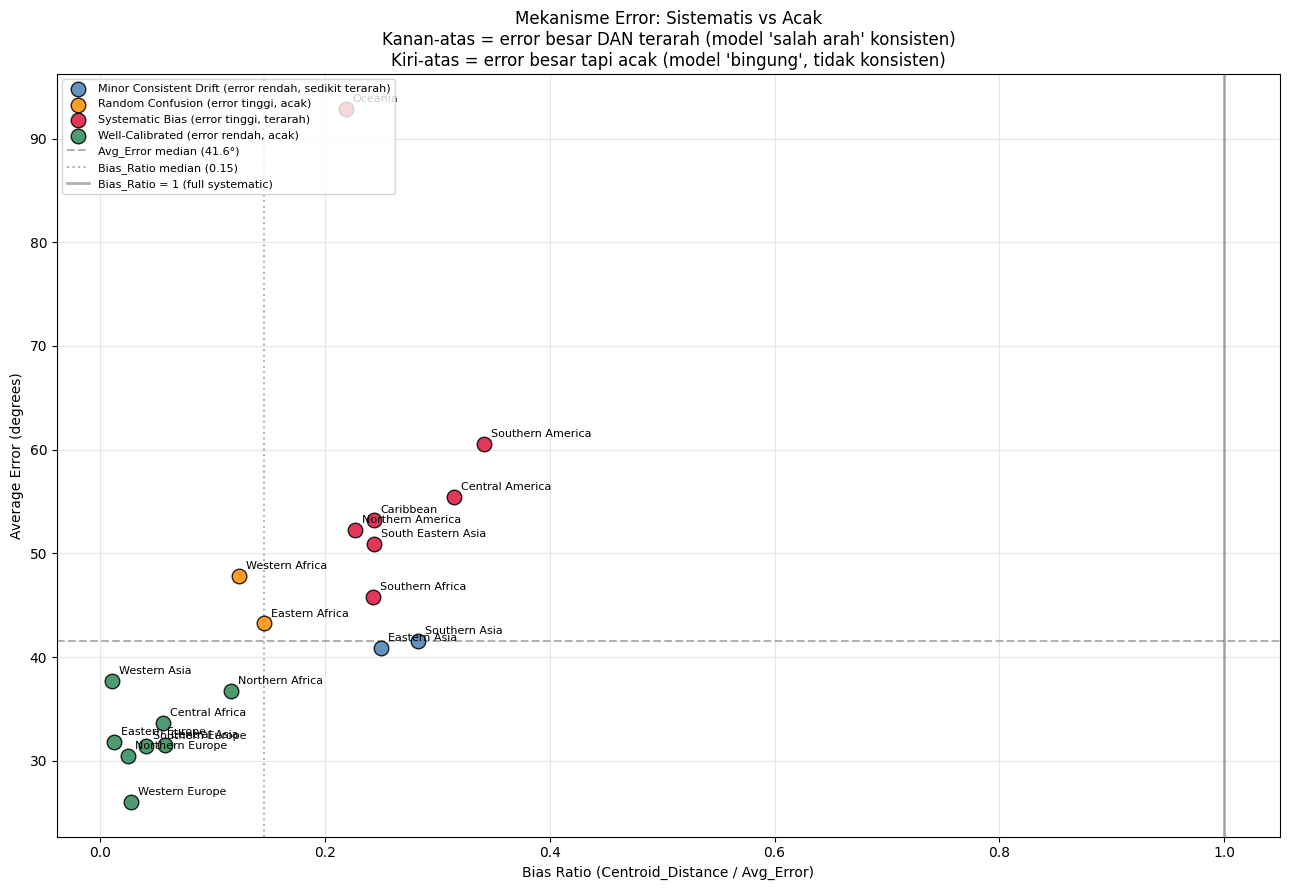


 EXPERIMENT 6.3 SELESAI.

Catatan interpretasi:
- Bias_Ratio tinggi + Avg_Error tinggi (kuadran kanan-atas):
  Model punya 'mental map yang salah secara konsisten' untuk region ini
  -> mengarah ke representational fallback / misconception sistematis
- Bias_Ratio rendah + Avg_Error tinggi (kuadran kiri-atas):
  Model 'tidak yakin' tapi tidak bias ke arah tertentu
  -> mengarah ke genuine ambiguity / lack of strong signal (bukan misconception)
- Bias_Ratio tinggi + Avg_Error rendah (kuadran kanan-bawah):
  Sedikit bias konsisten, tapi magnitude kecil -> minor, biasanya bisa diabaikan
- Bias_Ratio rendah + Avg_Error rendah (kuadran kiri-bawah):
  Model akurat dan tidak bias -> representasi paling 'sehat'


In [24]:
# ============================================================
# EKSPERIMEN C.2 — Rasio Bias Sistematis (Bias_Ratio)
# Objective:
#   Membedakan dua mekanisme error:
#   - ERROR ACAK: galat individual saling membatalkan ->
#     Centroid_Distance << Avg_Error -> rasio kecil
#   - BIAS SISTEMATIS: galat individual konsisten ke satu arah
#     -> Centroid_Distance mendekati Avg_Error -> rasio mendekati 1
#
# Formula: Bias_Ratio = Bias^2 / MSE (lihat Bab III.3.5.2).
# Dependensi: df_centroids dari Eksperimen C.1.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 65)
print("EKSPERIMEN C.2 — RASIO BIAS SISTEMATIS")
print("Ratio = Centroid_Distance / Avg_Error")
print("  Ratio -> 1+  : BIAS SISTEMATIS (model 'salah arah' konsisten)")
print("  Ratio -> 0   : ERROR ACAK (individual errors saling membatalkan)")
print("=" * 65)

assert 'Centroid_Distance' in df_centroids.columns, (
    "Kolom 'Centroid_Distance' tidak ada di df_centroids. "
    "Pastikan Experiment 6.1 (centroid distance) sudah dijalankan."
)

# ------------------------------------------------------------
# 6.3.A — Hitung Bias Ratio
# ------------------------------------------------------------
# Hitung di ruang vektor error 2D (setelah Patch 2, Centroid_Distance sudah great-circle)
# Gunakan komponen error lat dan lon (dalam derajat) per artefak.

bias_variance_records = []
for region, group in df_ind.groupby("Region"):
    if len(group) < 2:
        continue
    # FIX: dekomposisi galat berbasis azimuth eksak (great_circle_error_vector),
    # bukan selisih lat/lon mentah, aman terhadap distorsi antimeridian.
    north_err, east_err = great_circle_error_vector(
        group["Pred_Lat"].values, group["Pred_Lon"].values,
        group["Actual_Lat"].values, group["Actual_Lon"].values
    )
    errors = np.stack([north_err, east_err], axis=1)  # (n, 2)

    mse = np.mean(np.sum(errors**2, axis=1))       # rata-rata ||e||^2
    bias_vec = errors.mean(axis=0)                  # mean error vektor
    bias_sq = np.dot(bias_vec, bias_vec)            # ||mean_e||^2

    # Identitas eksak: MSE = bias^2 + variance
    bias_ratio_sq = bias_sq / mse if mse > 0 else 0.0   # ∈ [0,1] eksak

    bias_variance_records.append({
        "Region": region,
        "MSE": mse,
        "Bias_Sq": bias_sq,
        "Variance": mse - bias_sq,
        "Bias_Ratio": bias_ratio_sq,   # ini sekarang fraksi bias dari MSE
    })

df_bv = pd.DataFrame(bias_variance_records)
# Merge ke df_centroids
df_centroids = df_centroids.merge(df_bv[["Region", "Bias_Ratio"]], on="Region", how="left")

print("Bias_Ratio = bias²/MSE (fraksi MSE dari error sistematis), range [0,1] eksak.")

df_bias = df_centroids[
    ['Region', 'N_Artifacts', 'Avg_Error', 'Centroid_Distance',
     'Pred_Spread', 'Bias_Ratio']
].sort_values('Bias_Ratio', ascending=False)

print("\n BIAS RATIO PER REGION (diurutkan dari paling sistematis):")
print(df_bias.to_string(index=False))

# ------------------------------------------------------------
# 6.3.B — Bandingkan ranking: Avg_Error vs Bias_Ratio
# ------------------------------------------------------------
df_bias_ranked = df_bias.copy()
df_bias_ranked['Rank_AvgError'] = df_bias_ranked['Avg_Error'].rank(ascending=False).astype(int)
df_bias_ranked['Rank_BiasRatio'] = df_bias_ranked['Bias_Ratio'].rank(ascending=False).astype(int)
df_bias_ranked['Rank_Diff'] = df_bias_ranked['Rank_AvgError'] - df_bias_ranked['Rank_BiasRatio']

print("\n PERBANDINGAN RANKING: Avg_Error vs Bias_Ratio")
print("   (Rank_Diff = 0 -> ranking sama; "
      "Rank_Diff besar -> region ini 'pindah kelompok')")
print(df_bias_ranked[['Region', 'Avg_Error', 'Rank_AvgError',
                       'Bias_Ratio', 'Rank_BiasRatio', 'Rank_Diff']]
      .sort_values('Rank_AvgError')
      .to_string(index=False))

from scipy.stats import spearmanr
r_rank, p_rank = spearmanr(df_bias_ranked['Avg_Error'], df_bias_ranked['Bias_Ratio'])
print(f"\n Korelasi Spearman Avg_Error vs Bias_Ratio: r={r_rank:.3f} (p={p_rank:.4f})")
if r_rank > 0.5:
    print("   -> Region dengan error tinggi JUGA cenderung punya bias sistematis")
    print("      (error tinggi DAN terarah, bukan acak)")
elif r_rank < -0.2:
    print("   -> Region dengan error tinggi justru cenderung errornya ACAK")
else:
    print("   -> Tidak ada hubungan kuat; error tinggi bisa sistematis ATAU acak,")
    print("      tergantung region -> dua mekanisme berbeda yang perlu dibedakan")

# ------------------------------------------------------------
# 6.3.C — Klasifikasi 2x2: Avg_Error (tinggi/rendah) x Bias_Ratio (tinggi/rendah)
# ------------------------------------------------------------
error_median = df_bias['Avg_Error'].median()
ratio_median = df_bias['Bias_Ratio'].median()

print(f"\nThreshold (median-based):")
print(f"   Avg_Error median = {error_median:.2f}°")
print(f"   Bias_Ratio median = {ratio_median:.3f}")

def classify_2x2(row):
    high_error = row['Avg_Error'] > error_median
    high_ratio = row['Bias_Ratio'] > ratio_median
    if high_error and high_ratio:
        return "Systematic Bias (error tinggi, terarah)"
    elif high_error and not high_ratio:
        return "Random Confusion (error tinggi, acak)"
    elif not high_error and high_ratio:
        return "Minor Consistent Drift (error rendah, sedikit terarah)"
    else:
        return "Well-Calibrated (error rendah, acak)"

df_bias['Mechanism_2x2'] = df_bias.apply(classify_2x2, axis=1)
# FIX: gabungkan balik ke df_centroids, supaya Eksperimen C.3 memakai
# klasifikasi 2x2 yang benar alih-alih selalu jatuh ke fallback
df_centroids = df_centroids.merge(
    df_bias[['Region', 'Mechanism_2x2']], on='Region', how='left'
)

print("\n KLASIFIKASI 2x2 (Avg_Error x Bias_Ratio):")
print(df_bias[['Region', 'Avg_Error', 'Bias_Ratio', 'Mechanism_2x2']]
      .sort_values('Avg_Error', ascending=False)
      .to_string(index=False))

print("\n RINGKASAN PER KUADRAN:")
for mech in ["Systematic Bias (error tinggi, terarah)",
              "Random Confusion (error tinggi, acak)",
              "Minor Consistent Drift (error rendah, sedikit terarah)",
              "Well-Calibrated (error rendah, acak)"]:
    regions = df_bias[df_bias['Mechanism_2x2'] == mech]['Region'].tolist()
    print(f"\n   {mech} ({len(regions)} region):")
    for r in regions:
        print(f"      - {r}")

# ------------------------------------------------------------
# 6.3.D — Visualisasi: Scatter 2x2 (Avg_Error vs Bias_Ratio)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 9))

quadrant_colors = {
    "Systematic Bias (error tinggi, terarah)": "crimson",
    "Random Confusion (error tinggi, acak)": "darkorange",
    "Minor Consistent Drift (error rendah, sedikit terarah)": "steelblue",
    "Well-Calibrated (error rendah, acak)": "seagreen",
}

for mech, group in df_bias.groupby("Mechanism_2x2"):
    ax.scatter(group['Bias_Ratio'], group['Avg_Error'],
               label=mech, color=quadrant_colors.get(mech, "gray"),
               s=110, edgecolor='black', alpha=0.85, zorder=3)
    for _, row in group.iterrows():
        ax.annotate(row['Region'], (row['Bias_Ratio'], row['Avg_Error']),
                     fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.axhline(error_median, color='gray', linestyle='--', alpha=0.6,
           label=f'Avg_Error median ({error_median:.1f}°)')
ax.axvline(ratio_median, color='gray', linestyle=':', alpha=0.6,
           label=f'Bias_Ratio median ({ratio_median:.2f})')
ax.axvline(1.0, color='black', linestyle='-', alpha=0.3, linewidth=2,
           label='Bias_Ratio = 1 (full systematic)')

ax.set_xlabel("Bias Ratio (Centroid_Distance / Avg_Error)")
ax.set_ylabel("Average Error (degrees)")
ax.set_title("Mekanisme Error: Sistematis vs Acak\n"
              "Kanan-atas = error besar DAN terarah (model 'salah arah' konsisten)\n"
              "Kiri-atas = error besar tapi acak (model 'bingung', tidak konsisten)")
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n EXPERIMENT 6.3 SELESAI.")
print("\nCatatan interpretasi:")
print("- Bias_Ratio tinggi + Avg_Error tinggi (kuadran kanan-atas):")
print("  Model punya 'mental map yang salah secara konsisten' untuk region ini")
print("  -> mengarah ke representational fallback / misconception sistematis")
print("- Bias_Ratio rendah + Avg_Error tinggi (kuadran kiri-atas):")
print("  Model 'tidak yakin' tapi tidak bias ke arah tertentu")
print("  -> mengarah ke genuine ambiguity / lack of strong signal (bukan misconception)")
print("- Bias_Ratio tinggi + Avg_Error rendah (kuadran kanan-bawah):")
print("  Sedikit bias konsisten, tapi magnitude kecil -> minor, biasanya bisa diabaikan")
print("- Bias_Ratio rendah + Avg_Error rendah (kuadran kiri-bawah):")
print("  Model akurat dan tidak bias -> representasi paling 'sehat'")

EKSPERIMEN C.3 — ARAH BIAS (DIRECTION CONSISTENCY)
Apakah region-region 'Systematic Bias' mengarah ke
satu 'gravitational center' yang sama?

 BIAS VECTOR PER REGION:
            Region  Bias_Vec_Lat  Bias_Vec_Lon  Bias_Angle_Deg  Centroid_Distance  Bias_Ratio
  Southern America     31.237433     34.819272       41.896250          46.777761    0.341986
   Central America     10.514606     39.634935       14.857554          41.005914    0.314585
     Southern Asia      7.180420    -25.590232      164.326294          26.578533    0.283008
      Eastern Asia     12.895905    -21.548999      149.101771          25.113019    0.250037
         Caribbean     22.195153     26.572949       39.870444          34.622918    0.243713
South Eastern Asia     19.700596    -28.987977      145.799477          35.048770    0.243579
   Southern Africa     31.453790     -5.506533       99.929992          31.932159    0.243048
  Northern America     11.639080     34.383224       18.701496          36.299783

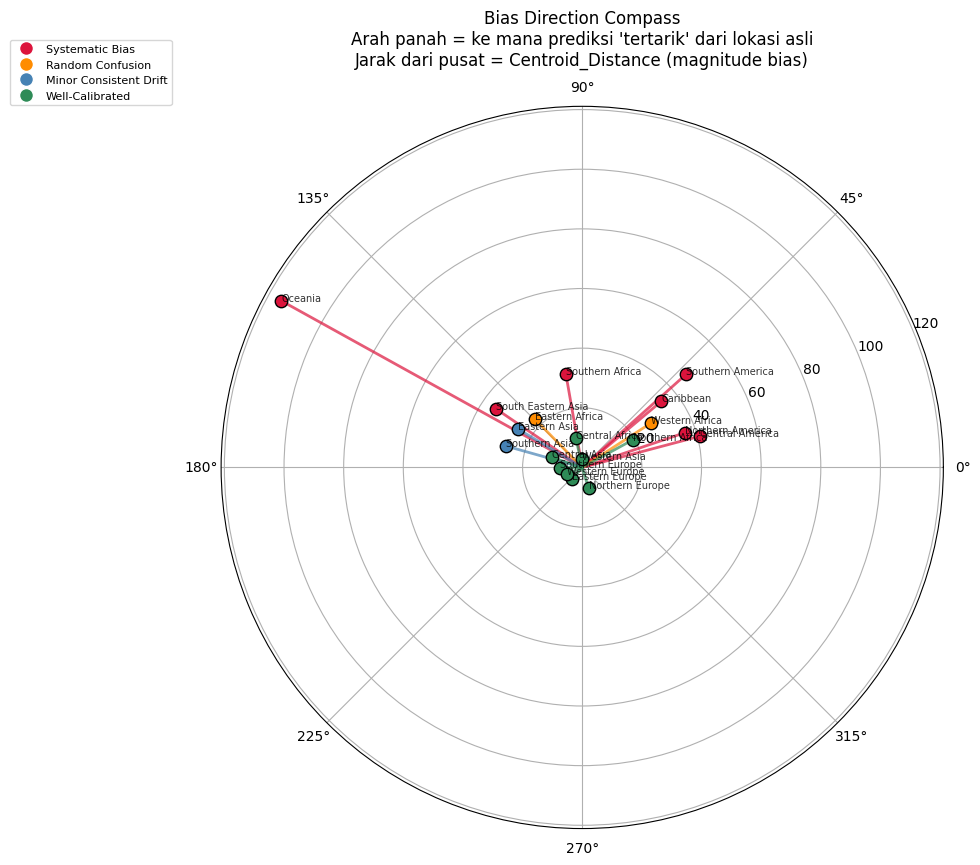


EKSPERIMEN C.3 — TARGET KEKELIRUAN (CONFUSION TARGET)
Region mana yang predicted centroid-nya paling dekat dengan
ACTUAL centroid region lain? -> 'model salah kira artefak ini dari mana'

 CONFUSION TARGET PER REGION:
   (Closest_Confusion_Target = region yang ACTUAL centroid-nya
    paling dekat dengan PREDICTED centroid region ini)
   (Improvement_vs_Self > 0 -> predicted centroid LEBIH DEKAT
    ke region lain daripada ke lokasi aslinya sendiri -> 'salah kira')

            Region  Centroid_Distance_to_Self Closest_Confusion_Target  Distance_to_Target  Improvement_vs_Self
           Oceania                 115.330861             Central Asia            6.149837           109.181024
  Southern America                  46.777761           Western Africa           25.075745            21.702016
   Central America                  41.005914                Caribbean           22.798827            18.207087
  Northern America                  36.299783                Caribbean           

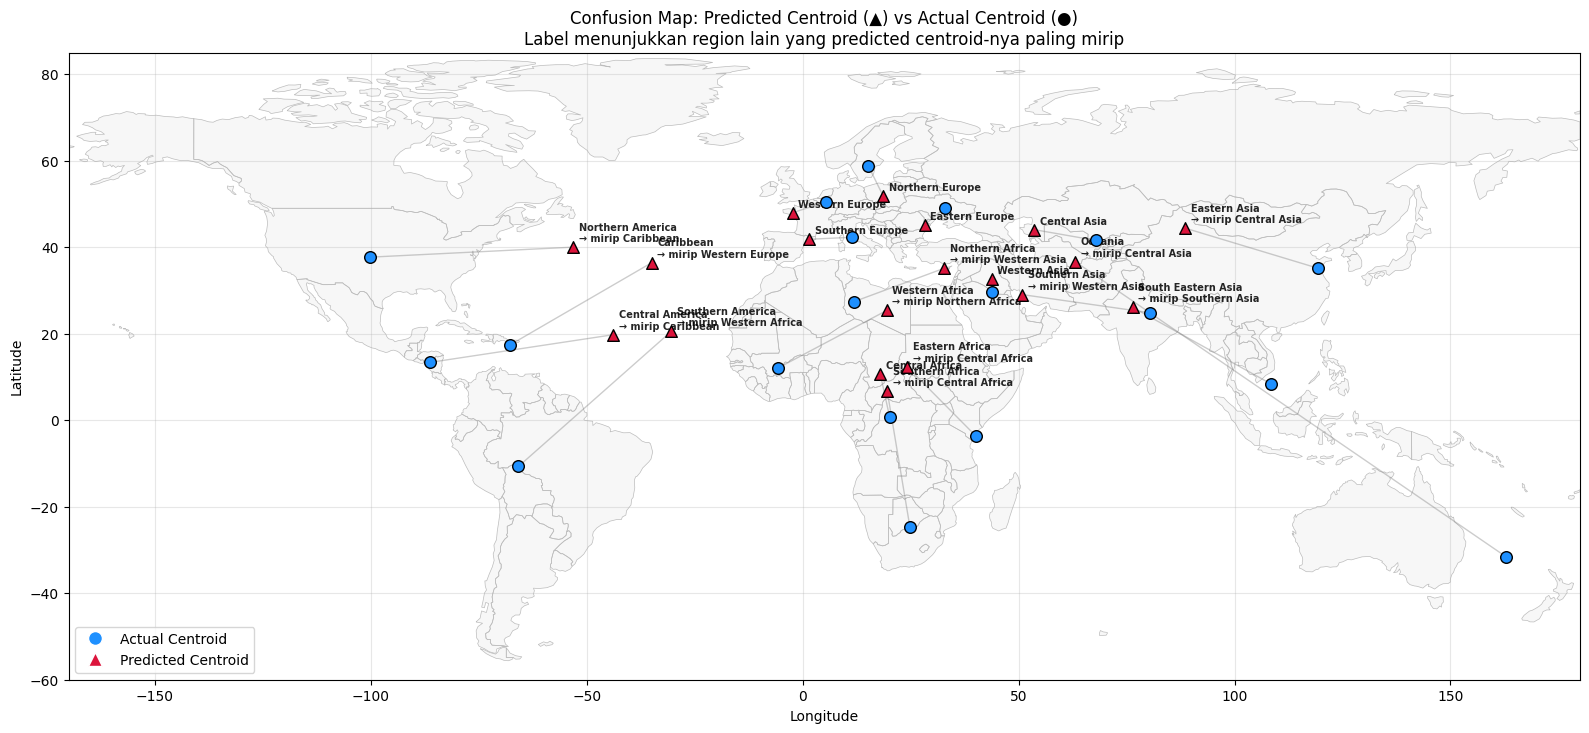


 EXPERIMENT 6.4 SELESAI.


In [25]:
# ============================================================
# EKSPERIMEN C.3 — Arah Bias dan Target Kekeliruan
# Objective:
#   (1) Direction Consistency: apakah region-region dengan bias
#       sistematis tinggi punya ARAH bias yang SAMA (mengindikasikan
#       satu "pusat gravitasi" representasional global)?
#   (2) Confusion Target: untuk tiap region, region lain mana yang
#       paling "tertukar" dengannya.
#
# Dependensi: df_centroids dari Eksperimen C.1.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

print("=" * 65)
print("EKSPERIMEN C.3 — ARAH BIAS (DIRECTION CONSISTENCY)")
print("Apakah region-region 'Systematic Bias' mengarah ke")
print("satu 'gravitational center' yang sama?")
print("=" * 65)

# ------------------------------------------------------------
# 6.4.A.1 — Hitung bias vector (arah & magnitude) per region
# ------------------------------------------------------------
df_centroids = df_centroids.copy()

# FIX: dekomposisi berbasis azimuth eksak (great_circle_error_vector),
# bukan selisih lat/lon mentah, aman terhadap distorsi antimeridian.
north_c, east_c = great_circle_error_vector(
    df_centroids['Pred_Centroid_Lat'].values, df_centroids['Pred_Centroid_Lon'].values,
    df_centroids['Actual_Centroid_Lat'].values, df_centroids['Actual_Centroid_Lon'].values
)
df_centroids['Bias_Vec_Lat'] = north_c   # nama kolom dipertahankan agar
df_centroids['Bias_Vec_Lon'] = east_c    # kompatibel dengan kode di bawah

# Sudut bias dalam derajat (0° = timur, 90° = utara, dst — konvensi standar)
df_centroids['Bias_Angle_Deg'] = np.degrees(
    np.arctan2(df_centroids['Bias_Vec_Lat'], df_centroids['Bias_Vec_Lon'])
)

print("\n BIAS VECTOR PER REGION:")
print(df_centroids[['Region', 'Bias_Vec_Lat', 'Bias_Vec_Lon',
                     'Bias_Angle_Deg', 'Centroid_Distance', 'Bias_Ratio']]
      .sort_values('Bias_Ratio', ascending=False)
      .to_string(index=False))

# ------------------------------------------------------------
# 6.4.A.2 — Cek konsistensi arah HANYA untuk region "Systematic Bias"
# ------------------------------------------------------------
if 'Mechanism_2x2' in df_centroids.columns:
    systematic = df_centroids[
        df_centroids['Mechanism_2x2'].str.contains('Systematic Bias', na=False)
    ]
else:
    # fallback: pakai threshold Bias_Ratio > median
    ratio_median = df_centroids['Bias_Ratio'].median()
    systematic = df_centroids[df_centroids['Bias_Ratio'] > ratio_median]

print(f"\n⏳ Region dengan Systematic Bias (n={len(systematic)}): "
      f"{systematic['Region'].tolist()}")

if len(systematic) >= 2:
    angles_rad = np.radians(systematic['Bias_Angle_Deg'].values)
    R = np.sqrt(np.mean(np.cos(angles_rad))**2 + np.mean(np.sin(angles_rad))**2)
    mean_angle = np.degrees(np.arctan2(np.mean(np.sin(angles_rad)), np.mean(np.cos(angles_rad))))

    print(f"\n Direction Consistency (R) untuk region Systematic Bias: {R:.3f}")
    print(f"   Mean bias direction: {mean_angle:.1f}°")
    print("   (R mendekati 1 -> SEMUA region bias ke arah yang SAMA "
          "-> ada 'gravitational center' global)")
    print("   (R mendekati 0 -> arah bias berbeda-beda per region "
          "-> tiap region punya 'salah kaprah' sendiri-sendiri)")

    if R > 0.6:
        print("\n Indikasi kuat ada GRAVITATIONAL CENTER global.")
    else:
        print("\n Tidak ada gravitational center tunggal yang jelas;")
        print("      tiap region kemungkinan punya confusion target berbeda.")

# ------------------------------------------------------------
# 6.4.A.3 — Visualisasi: Compass plot (semua bias vector dari origin)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})

colors_map = {
    "Systematic Bias (error tinggi, terarah)": "crimson",
    "Random Confusion (error tinggi, acak)": "darkorange",
    "Minor Consistent Drift (error rendah, sedikit terarah)": "steelblue",
    "Well-Calibrated (error rendah, acak)": "seagreen",
}

for _, row in df_centroids.iterrows():
    angle_rad = np.radians(row['Bias_Angle_Deg'])
    magnitude = row['Centroid_Distance']
    mech = row.get('Mechanism_2x2', 'Unknown')
    color = colors_map.get(mech, 'gray')

    ax.plot([angle_rad, angle_rad], [0, magnitude],
            color=color, alpha=0.7, linewidth=2)
    ax.scatter(angle_rad, magnitude, color=color, s=80,
               edgecolor='black', zorder=3)
    ax.annotate(row['Region'], (angle_rad, magnitude),
                fontsize=7, alpha=0.8)

# Tambahkan reference arah kompas
ax.set_theta_zero_location('E')  # 0° = timur (lon+)
ax.set_theta_direction(1)         # counter-clockwise = utara (lat+)
ax.set_title("Bias Direction Compass\n"
              "Arah panah = ke mana prediksi 'tertarik' dari lokasi asli\n"
              "Jarak dari pusat = Centroid_Distance (magnitude bias)",
              pad=30)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=c, markersize=10, label=m.split('(')[0].strip())
                    for m, c in colors_map.items()]
ax.legend(handles=legend_elements, loc='upper left',
          bbox_to_anchor=(-0.3, 1.1), fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# EXPERIMENT 6.4.B — CONFUSION TARGET
# Untuk tiap region, cari region LAIN yang ACTUAL centroid-nya
# paling dekat dengan PREDICTED centroid region tersebut.
# -> "Model mengira artefak [Region A] itu sebenarnya dari [Region B]"
# ============================================================

print("\n" + "=" * 65)
print("EKSPERIMEN C.3 — TARGET KEKELIRUAN (CONFUSION TARGET)")
print("Region mana yang predicted centroid-nya paling dekat dengan")
print("ACTUAL centroid region lain? -> 'model salah kira artefak ini dari mana'")
print("=" * 65)

regions = df_centroids['Region'].values
actual_coords = df_centroids[['Actual_Centroid_Lat', 'Actual_Centroid_Lon']].values
pred_coords = df_centroids[['Pred_Centroid_Lat', 'Pred_Centroid_Lon']].values

# Jarak dari predicted centroid region i ke actual centroid region j (semua pasangan)
n = len(df_centroids)
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dist_matrix[i, j] = great_circle_deg(
            df_centroids['Pred_Centroid_Lat'].iloc[i],
            df_centroids['Pred_Centroid_Lon'].iloc[i],
            df_centroids['Actual_Centroid_Lat'].iloc[j],
            df_centroids['Actual_Centroid_Lon'].iloc[j]
        )

confusion_records = []
for i, region in enumerate(regions):
    # Urutkan jarak predicted_i ke semua actual_j, ambil yang terdekat
    # EXCLUDE region itu sendiri dulu untuk lihat "kalau bukan dirinya, mirip siapa"
    dists_to_others = {regions[j]: dist_matrix[i, j] for j in range(len(regions)) if j != i}
    dists_to_self = dist_matrix[i, i]  # = Centroid_Distance, untuk referensi

    sorted_targets = sorted(dists_to_others.items(), key=lambda x: x[1])
    closest_region, closest_dist = sorted_targets[0]
    second_region, second_dist = sorted_targets[1]

    confusion_records.append({
        "Region": region,
        "Centroid_Distance_to_Self": dists_to_self,
        "Closest_Confusion_Target": closest_region,
        "Distance_to_Target": closest_dist,
        "2nd_Closest_Target": second_region,
        "Distance_to_2nd": second_dist,
        "Improvement_vs_Self": dists_to_self - closest_dist,
    })

df_confusion = pd.DataFrame(confusion_records).sort_values(
    "Centroid_Distance_to_Self", ascending=False
)

print("\n CONFUSION TARGET PER REGION:")
print("   (Closest_Confusion_Target = region yang ACTUAL centroid-nya")
print("    paling dekat dengan PREDICTED centroid region ini)")
print("   (Improvement_vs_Self > 0 -> predicted centroid LEBIH DEKAT")
print("    ke region lain daripada ke lokasi aslinya sendiri -> 'salah kira')")
print()
print(df_confusion[['Region', 'Centroid_Distance_to_Self',
                     'Closest_Confusion_Target', 'Distance_to_Target',
                     'Improvement_vs_Self']].to_string(index=False))

# ------------------------------------------------------------
# 6.4.B.2 — Highlight "salah kira" yang paling jelas
# (predicted centroid lebih dekat ke region LAIN daripada ke dirinya sendiri)
# ------------------------------------------------------------
misidentified = df_confusion[df_confusion['Improvement_vs_Self'] > 0]
misidentified = misidentified.sort_values('Improvement_vs_Self', ascending=False)

print("\n REGION DENGAN 'SALAH KIRA' PALING JELAS:")
print("   (predicted centroid region ini LEBIH MIRIP region lain")
print("    daripada lokasi aslinya sendiri)\n")

if len(misidentified) == 0:
    print("   Tidak ada region yang predicted centroid-nya lebih dekat")
    print("   ke region lain dibanding ke dirinya sendiri.")
else:
    for _, row in misidentified.iterrows():
        print(f"   '{row['Region']}' artefaknya cenderung di-decode model "
              f"sebagai berasal dari '{row['Closest_Confusion_Target']}'")
        print(f"      (jarak ke {row['Closest_Confusion_Target']}: "
              f"{row['Distance_to_Target']:.1f}° "
              f"vs jarak ke lokasi asli sendiri: {row['Centroid_Distance_to_Self']:.1f}°)\n")

# ------------------------------------------------------------
# 6.4.B.3 — Visualisasi: Peta dengan confusion target arrows
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 9))

try:
    if world is not None:
        world.boundary.plot(ax=ax, linewidth=0.5, color='#bcbcbc', zorder=1)
        world.plot(ax=ax, color='#f7f7f7', zorder=0)
except NameError:
    pass

for _, row in df_centroids.iterrows():
    region = row['Region']
    conf_row = df_confusion[df_confusion['Region'] == region].iloc[0]

    # Actual centroid (biru)
    ax.scatter(row['Actual_Centroid_Lon'], row['Actual_Centroid_Lat'],
               color='dodgerblue', s=70, edgecolor='black', zorder=4)

    # Predicted centroid (merah)
    ax.scatter(row['Pred_Centroid_Lon'], row['Pred_Centroid_Lat'],
               color='crimson', s=70, edgecolor='black', zorder=4, marker='^')

    # Garis actual -> predicted
    ax.plot([row['Actual_Centroid_Lon'], row['Pred_Centroid_Lon']],
            [row['Actual_Centroid_Lat'], row['Pred_Centroid_Lat']],
            color='gray', alpha=0.4, linewidth=1, zorder=2)

    # Label: tampilkan confusion target jika "salah kira" signifikan
    label = region
    if conf_row['Improvement_vs_Self'] > 0:
        label += f"\n→ mirip {conf_row['Closest_Confusion_Target']}"

    ax.annotate(label, (row['Pred_Centroid_Lon'], row['Pred_Centroid_Lat']),
                fontsize=7, fontweight='bold', alpha=0.85,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlim(-170, 180)
ax.set_ylim(-60, 85)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Confusion Map: Predicted Centroid (▲) vs Actual Centroid (●)\n"
              "Label menunjukkan region lain yang predicted centroid-nya paling mirip")
ax.grid(alpha=0.3)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='dodgerblue',
           markersize=10, label='Actual Centroid'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='crimson',
           markersize=10, label='Predicted Centroid')
]
ax.legend(handles=legend_elements, loc='lower left')

plt.tight_layout()
plt.show()

print("\n EXPERIMENT 6.4 SELESAI.")

EKSPERIMEN C.4 — GALAT TERNORMALISASI
Avg_Error relatif terhadap 'ukuran' geografis aktual region

 AVG_ERROR vs ACTUAL_SPREAD vs NORMALIZED_ERROR
   (diurutkan dari Avg_Error terendah -> region 'paling akurat' secara absolut)
            Region  N_Countries  Avg_Error  Actual_Spread  Normalized_Error
    Western Europe           10  26.039094       4.381082          5.943531
   Northern Europe            9  30.458600       8.348055          3.648586
   Southern Europe           11  31.455245       7.704879          4.082510
      Central Asia            5  31.574024       5.199937          6.072002
    Eastern Europe           13  31.797186      14.183904          2.241780
    Central Africa            8  33.653644       9.739769          3.455281
   Northern Africa            7  36.753100      15.688242          2.342716
      Western Asia           15  37.699321       9.214264          4.091409
      Eastern Asia            7  40.909764      12.493824          3.274399
     Southern

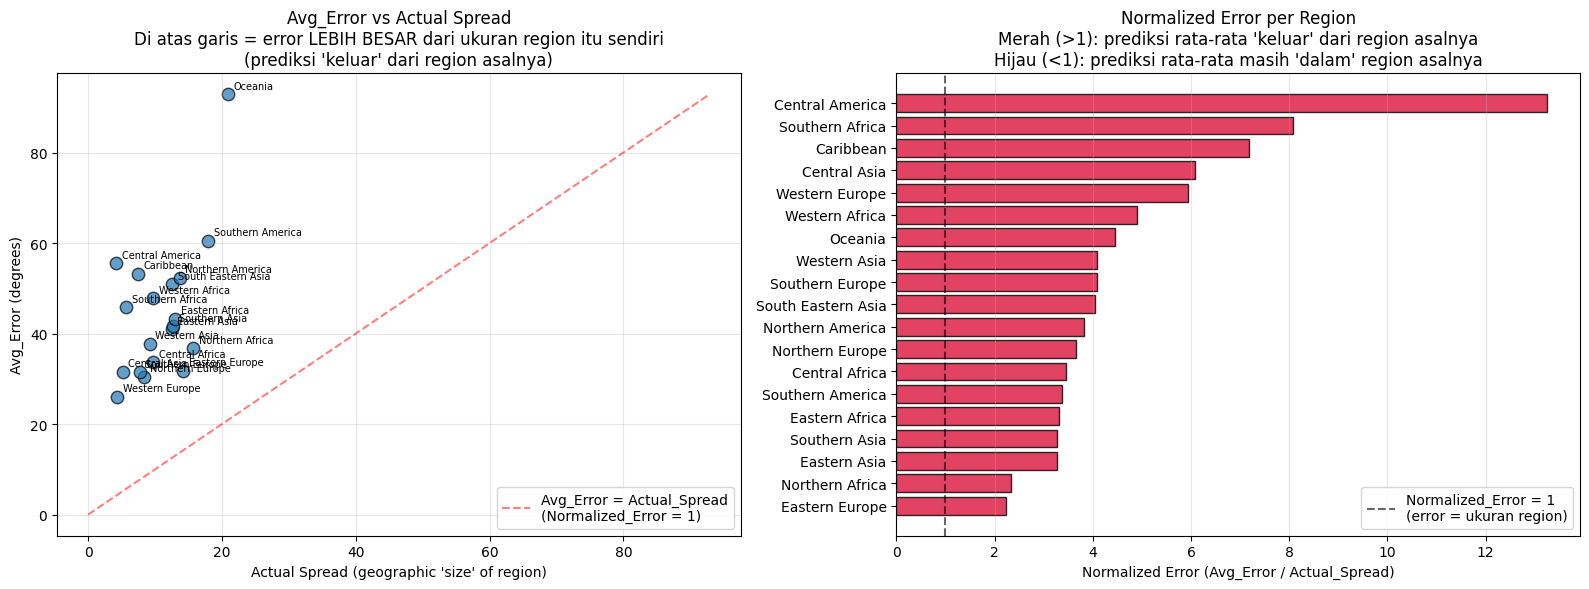


EKSPERIMEN C.4 — KORELASI STRUKTURAL (WITHIN-REGION DISCRIMINABILITY)
Apakah model membedakan negara A vs B DALAM region yang sama,
dengan struktur jarak relatif yang konsisten dgn realitas?

 WITHIN-REGION DISCRIMINABILITY (Structure Correlation):
   Structure_Correlation = korelasi Spearman antara:
   - jarak ASLI antar negara dalam region (actual pairwise distances)
   - jarak PREDIKSI antar negara yang sama (predicted pairwise distances)

   Tinggi (-> 1) : model menangkap STRUKTUR RELATIF dengan baik
                   (negara yg dekat secara asli, predicted-nya juga dekat)
   Rendah/negatif: model TIDAK BISA membedakan negara dalam region ini
                   (semua 'ditumpuk' di tempat serupa, tidak granular)

            Region  N_Countries  N_Pairs  Structure_Correlation  Structure_P_Mantel  Max_Permutations
   Northern Africa            7       21               0.759740               0.002               999
    Central Africa            8       28               0.707170   

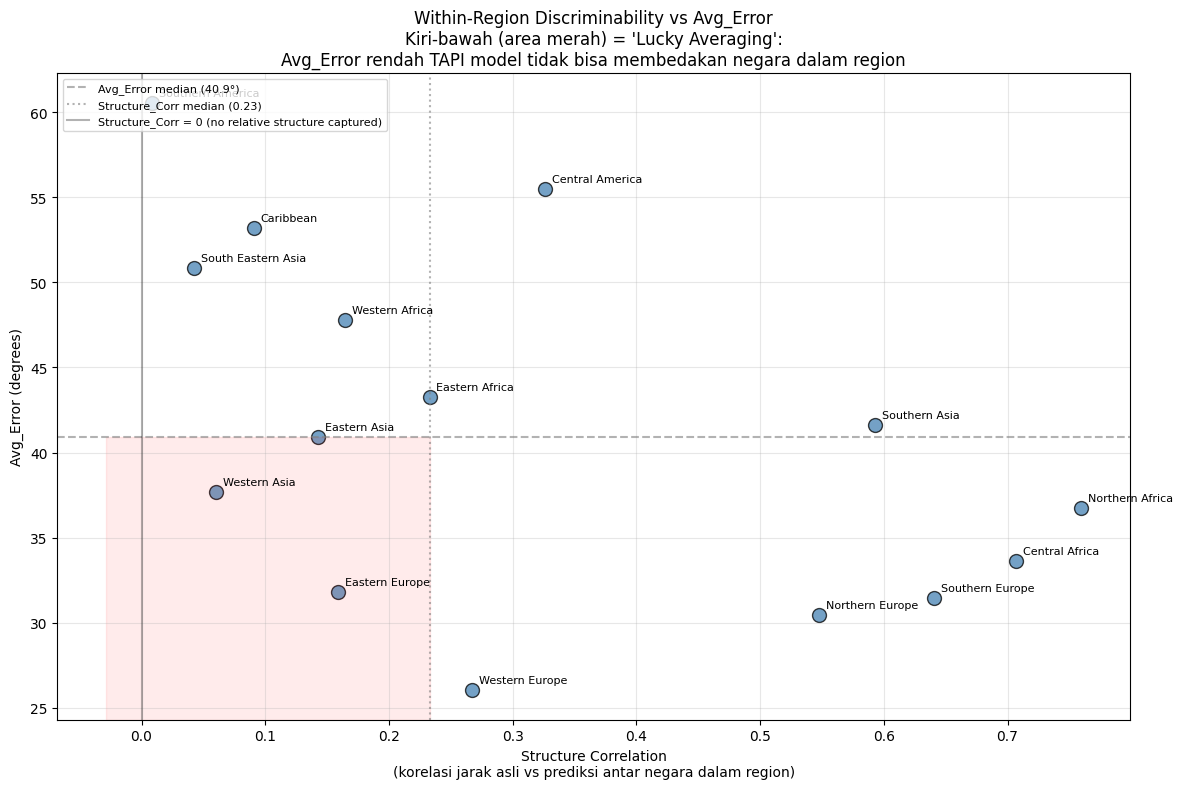


 EXPERIMENT 6.5 SELESAI.

Catatan interpretasi akhir:
- Normalized_Error tinggi (>1): error absolut MUNGKIN kecil,
  tapi RELATIF terhadap ukuran region, prediksi 'keluar jalur'.
- Structure_Correlation rendah + Avg_Error rendah: region ini
  'terlihat akurat' hanya karena KOMPAK secara geografis,
  bukan karena model benar-benar mengenali negara2 di dalamnya.
- Region yang LOLOS kedua tes ini (Normalized_Error rendah DAN
  Structure_Correlation tinggi) adalah kandidat PALING KUAT
  untuk klaim 'representasi geografis akurat & granular'.


In [26]:
# ============================================================
# EKSPERIMEN C.4 — Galat Ternormalisasi dan Korelasi Struktural
# Objective:
#   Membedakan "Avg_Error rendah karena representasi presisi" vs
#   "Avg_Error rendah karena wilayahnya kompak secara geografis".
#
#   (A) Normalized_Error: Avg_Error relatif terhadap sebaran
#       geografis aktual wilayah tersebut.
#   (B) Korelasi struktural (uji permutasi Mantel): apakah model
#       membedakan negara A vs B dalam satu wilayah, dibandingkan
#       struktur jarak relatif aktual vs prediksi.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

print("=" * 65)
print("EKSPERIMEN C.4 — GALAT TERNORMALISASI")
print("Avg_Error relatif terhadap 'ukuran' geografis aktual region")
print("=" * 65)

# ------------------------------------------------------------
# 6.5.A.1 — Hitung actual spread per region (dari df_results_pure,
# level negara, bukan individual artefak)
# ------------------------------------------------------------
spread_records = []

for region, group in df_results_pure.groupby("Region"):
    if len(group) < 2:
        continue

    # BARU: RMS great-circle dari tiap negara ke centroid aktual region
    c_lat, c_lon = spherical_centroid(
        group["Actual_Lat"].values, group["Actual_Lon"].values)
    dist_to_centroid = great_circle_deg(
        group["Actual_Lat"].values, group["Actual_Lon"].values,
        np.full(len(group), c_lat), np.full(len(group), c_lon)
    )
    actual_spread = np.sqrt(np.mean(dist_to_centroid**2))   # RMS great-circle

    spread_records.append({
        "Region": region,
        "N_Countries": len(group),
        "Actual_Spread": actual_spread,
    })

df_spread = pd.DataFrame(spread_records)

# ------------------------------------------------------------
# 6.5.A.2 — Join dengan Avg_Error dari df_centroids, hitung Normalized_Error
# ------------------------------------------------------------
df_norm = df_spread.merge(
    df_centroids[["Region", "Avg_Error", "Bias_Ratio"]],
    on="Region", how="inner"
)

df_norm["Normalized_Error"] = df_norm["Avg_Error"] / df_norm["Actual_Spread"]

df_norm = df_norm.sort_values("Avg_Error")

print("\n AVG_ERROR vs ACTUAL_SPREAD vs NORMALIZED_ERROR")
print("   (diurutkan dari Avg_Error terendah -> region 'paling akurat' secara absolut)")
print(df_norm[["Region", "N_Countries", "Avg_Error",
                "Actual_Spread", "Normalized_Error"]].to_string(index=False))

# ------------------------------------------------------------
# 6.5.A.3 — Re-ranking: siapa yang "benar2 akurat" vs "untung karena kompak"
# ------------------------------------------------------------
df_norm_ranked = df_norm.copy()
df_norm_ranked["Rank_AvgError"] = df_norm_ranked["Avg_Error"].rank().astype(int)
df_norm_ranked["Rank_NormError"] = df_norm_ranked["Normalized_Error"].rank().astype(int)
df_norm_ranked["Rank_Shift"] = df_norm_ranked["Rank_AvgError"] - df_norm_ranked["Rank_NormError"]

print("\n PERUBAHAN RANKING: Avg_Error vs Normalized_Error")
print("   (Rank_Shift positif besar -> region ini 'terlihat lebih buruk'")
print("    setelah dinormalisasi -> sebelumnya 'untung' karena kompak)")
print("   (Rank_Shift negatif besar -> region ini 'terlihat lebih baik'")
print("    setelah dinormalisasi -> sebelumnya 'rugi' karena tersebar luas)")
print(df_norm_ranked[["Region", "Avg_Error", "Rank_AvgError",
                       "Normalized_Error", "Rank_NormError", "Rank_Shift"]]
      .sort_values("Rank_Shift", ascending=False)
      .to_string(index=False))

r_norm, p_norm = spearmanr(df_norm["Avg_Error"], df_norm["Normalized_Error"])
print(f"\n Korelasi Avg_Error vs Normalized_Error: r={r_norm:.3f} (p={p_norm:.4f})")
if r_norm < 0.5:
    print("   -> Ranking berubah CUKUP BANYAK setelah normalisasi.")
    print("      'Region akurat' menurut Avg_Error TIDAK SELALU akurat")
    print("      setelah memperhitungkan ukuran geografis region tersebut.")
else:
    print("   -> Ranking relatif konsisten; normalisasi tidak banyak mengubah urutan.")

# ------------------------------------------------------------
# 6.5.A.4 — Visualisasi: Avg_Error vs Actual_Spread
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.scatter(df_norm["Actual_Spread"], df_norm["Avg_Error"],
            s=80, edgecolor='black', alpha=0.7)
for _, row in df_norm.iterrows():
    ax1.annotate(row["Region"], (row["Actual_Spread"], row["Avg_Error"]),
                  fontsize=7, xytext=(4, 4), textcoords='offset points')

# Garis diagonal y=x sebagai referensi "error = ukuran region"
lims = [0, max(df_norm["Actual_Spread"].max(), df_norm["Avg_Error"].max())]
ax1.plot(lims, lims, 'r--', alpha=0.5, label='Avg_Error = Actual_Spread\n(Normalized_Error = 1)')

ax1.set_xlabel("Actual Spread (geographic 'size' of region)")
ax1.set_ylabel("Avg_Error (degrees)")
ax1.set_title("Avg_Error vs Actual Spread\n"
               "Di atas garis = error LEBIH BESAR dari ukuran region itu sendiri\n"
               "(prediksi 'keluar' dari region asalnya)")
ax1.legend()
ax1.grid(alpha=0.3)

# Bar chart Normalized_Error
ax2 = axes[1]
df_plot = df_norm.sort_values("Normalized_Error")
colors = ['crimson' if x > 1 else 'seagreen' for x in df_plot["Normalized_Error"]]
ax2.barh(df_plot["Region"], df_plot["Normalized_Error"], color=colors,
         edgecolor='black', alpha=0.8)
ax2.axvline(1.0, color='black', linestyle='--', alpha=0.6,
            label='Normalized_Error = 1\n(error = ukuran region)')
ax2.set_xlabel("Normalized Error (Avg_Error / Actual_Spread)")
ax2.set_title("Normalized Error per Region\n"
               "Merah (>1): prediksi rata-rata 'keluar' dari region asalnya\n"
               "Hijau (<1): prediksi rata-rata masih 'dalam' region asalnya")
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# EXPERIMENT 6.5.B — WITHIN-REGION DISCRIMINABILITY
# Apakah model bisa membedakan negara A vs B DALAM region yang sama?
# Bandingkan struktur jarak relatif: actual pairwise distances vs
# predicted pairwise distances, dalam tiap region.
# ============================================================

print("\n" + "=" * 65)
print("EKSPERIMEN C.4 — KORELASI STRUKTURAL (WITHIN-REGION DISCRIMINABILITY)")
print("Apakah model membedakan negara A vs B DALAM region yang sama,")
print("dengan struktur jarak relatif yang konsisten dgn realitas?")
print("=" * 65)

MIN_COUNTRIES_FOR_DISCRIM = 6  # FIX: dinaikkan dari 4; N=4 hanya 24 permutasi unik (Bab III.1.3.4)
discrim_records = []

for region, group in df_results_pure.groupby("Region"):
    if len(group) < MIN_COUNTRIES_FOR_DISCRIM:
        continue

    group = group.reset_index(drop=True)
    n = len(group)

    actual_coords = group[["Actual_Lat", "Actual_Lon"]].values
    pred_coords   = group[["Pred_Lat",   "Pred_Lon"  ]].values

    # ── PATCH: great-circle, bukan Euclidean derajat ──
    actual_gc = np.zeros((n, n))
    pred_gc   = np.zeros((n, n))
    for a in range(n):
        for b in range(a+1, n):
            actual_gc[a, b] = great_circle_deg(
                actual_coords[a, 0], actual_coords[a, 1],
                actual_coords[b, 0], actual_coords[b, 1])
            pred_gc[a, b] = great_circle_deg(
                pred_coords[a, 0], pred_coords[a, 1],
                pred_coords[b, 0], pred_coords[b, 1])

    iu           = np.triu_indices(n, k=1)
    actual_dists = actual_gc[iu]
    pred_dists   = pred_gc[iu]

    if len(actual_dists) < 3 or actual_dists.std() == 0 or pred_dists.std() == 0:
        continue

    # r_struct: Spearman biasa masih ok untuk nilai korelasi
    r_struct, _ = spearmanr(actual_dists, pred_dists)

    # ── PATCH: Mantel test untuk p-value yang valid ──
    B   = 999
    rng = np.random.default_rng(42)
    count_extreme = 0
    for _ in range(B):
        perm      = rng.permutation(n)
        perm_dist = actual_gc[np.ix_(perm, perm)][iu]
        if perm_dist.std() == 0:
          continue
        r_perm, _ = spearmanr(perm_dist, pred_dists)
        if np.isnan(r_perm):
          continue
        if r_perm >= r_struct:
            count_extreme += 1
    p_mantel = (count_extreme + 1) / (B + 1)

    discrim_records.append({
        "Region":               region,
        "N_Countries":          n,
        "N_Pairs":              len(actual_dists),
        "Structure_Correlation": r_struct,
        "Structure_P_Mantel":   p_mantel,   # ganti nama kolom
        "Max_Permutations":     999,        # untuk transparansi
    })

df_discrim = pd.DataFrame(discrim_records).sort_values(
    "Structure_Correlation", ascending=False
)

print("\n WITHIN-REGION DISCRIMINABILITY (Structure Correlation):")
print("   Structure_Correlation = korelasi Spearman antara:")
print("   - jarak ASLI antar negara dalam region (actual pairwise distances)")
print("   - jarak PREDIKSI antar negara yang sama (predicted pairwise distances)")
print()
print("   Tinggi (-> 1) : model menangkap STRUKTUR RELATIF dengan baik")
print("                   (negara yg dekat secara asli, predicted-nya juga dekat)")
print("   Rendah/negatif: model TIDAK BISA membedakan negara dalam region ini")
print("                   (semua 'ditumpuk' di tempat serupa, tidak granular)\n")
print(df_discrim.to_string(index=False))

# ------------------------------------------------------------
# 6.5.B.2 — Join dengan Avg_Error & Normalized_Error untuk komparasi
# ------------------------------------------------------------
df_combined_65 = df_discrim.merge(
    df_norm[["Region", "Avg_Error", "Normalized_Error", "Bias_Ratio"]],
    on="Region", how="left"
)

print("\n TABEL GABUNGAN: Discriminability vs Error Metrics")
print(df_combined_65.sort_values("Avg_Error")
      [["Region", "N_Countries", "Avg_Error", "Normalized_Error",
        "Bias_Ratio", "Structure_Correlation"]]
      .to_string(index=False))

# ------------------------------------------------------------
# 6.5.B.3 — Highlight: region dengan Avg_Error rendah TAPI
# Structure_Correlation juga rendah -> "lucky averaging", bukan presisi
# ------------------------------------------------------------
error_median_65 = df_combined_65["Avg_Error"].median()
struct_median = df_combined_65["Structure_Correlation"].median()

print(f"\nThreshold (median-based):")
print(f"   Avg_Error median = {error_median_65:.2f}°")
print(f"   Structure_Correlation median = {struct_median:.3f}")

suspicious = df_combined_65[
    (df_combined_65["Avg_Error"] <= error_median_65) &
    (df_combined_65["Structure_Correlation"] <= struct_median)
]

print(f"\n REGION 'LOW ERROR TAPI LOW DISCRIMINABILITY' "
      f"(n={len(suspicious)}):")
print("   Avg_Error rendah, TAPI model TIDAK bisa membedakan")
print("   negara-negara dalam region ini secara granular.")
print("   -> Indikasi 'lucky averaging' (untung karena region kompak),")
print("      bukan representasi yang benar-benar presisi.\n")

if len(suspicious) == 0:
    print("   (Tidak ada region yang masuk kategori ini)")
else:
    for _, row in suspicious.iterrows():
        print(f"   - {row['Region']}: Avg_Error={row['Avg_Error']:.2f}°, "
              f"Structure_Correlation={row['Structure_Correlation']:.3f}")

# ------------------------------------------------------------
# 6.5.B.4 — Visualisasi: Avg_Error vs Structure_Correlation
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(df_combined_65["Structure_Correlation"], df_combined_65["Avg_Error"],
           s=100, edgecolor='black', alpha=0.75, c='steelblue')

for _, row in df_combined_65.iterrows():
    ax.annotate(row["Region"],
                 (row["Structure_Correlation"], row["Avg_Error"]),
                 fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.axhline(error_median_65, color='gray', linestyle='--', alpha=0.6,
           label=f'Avg_Error median ({error_median_65:.1f}°)')
ax.axvline(struct_median, color='gray', linestyle=':', alpha=0.6,
           label=f'Structure_Corr median ({struct_median:.2f})')
ax.axvline(0, color='black', linestyle='-', alpha=0.3, linewidth=1.5,
           label='Structure_Corr = 0 (no relative structure captured)')

# Highlight kuadran "lucky averaging" (kiri-bawah)
ax.axvspan(ax.get_xlim()[0], struct_median, ymin=0,
           ymax=(error_median_65 - ax.get_ylim()[0]) /
                 (ax.get_ylim()[1] - ax.get_ylim()[0]),
           alpha=0.08, color='red')

ax.set_xlabel("Structure Correlation\n"
               "(korelasi jarak asli vs prediksi antar negara dalam region)")
ax.set_ylabel("Avg_Error (degrees)")
ax.set_title("Within-Region Discriminability vs Avg_Error\n"
              "Kiri-bawah (area merah) = 'Lucky Averaging':\n"
              "Avg_Error rendah TAPI model tidak bisa membedakan negara dalam region")
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n EXPERIMENT 6.5 SELESAI.")
print("\nCatatan interpretasi akhir:")
print("- Normalized_Error tinggi (>1): error absolut MUNGKIN kecil,")
print("  tapi RELATIF terhadap ukuran region, prediksi 'keluar jalur'.")
print("- Structure_Correlation rendah + Avg_Error rendah: region ini")
print("  'terlihat akurat' hanya karena KOMPAK secara geografis,")
print("  bukan karena model benar-benar mengenali negara2 di dalamnya.")
print("- Region yang LOLOS kedua tes ini (Normalized_Error rendah DAN")
print("  Structure_Correlation tinggi) adalah kandidat PALING KUAT")
print("  untuk klaim 'representasi geografis akurat & granular'.")

In [27]:
# ============================================================
# EKSPERIMEN D — Probing Region-Balanced (Uji Robustness)
# Objective: apakah pola bias yang ditemukan di Eksperimen C
# genuine representasional atau artefak ketimpangan jumlah
# artefak antarwilayah (lihat Bab III.2.5 dan III.3.6).
#
# Metode: setiap instrumen dibobot 1/(n_wilayah x n_instrumen_wilayah)
# sehingga tiap wilayah berkontribusi setara ke pelatihan probe.
# Sel ini juga memuat ringkasan effect size dan ranking
# perbandingan (tidak dipisah per sel seperti notebook kuliner).
# ============================================================

print("=" * 65)
print("EKSPERIMEN D — PROBING REGION-BALANCED (UJI ROBUSTNESS)")
print("=" * 65)

from collections import Counter

# ── 1. Hitung bobot per-baris yang menyeimbangkan region ──────────
# Tiap region berkontribusi total bobot = 1/N_region, terlepas
# dari berapa banyak artefak yang dimilikinya.
region_counts_inst = Counter(inst_regions)   # inst_regions dari Eks 4.9
n_regions_inst     = len(region_counts_inst)

inst_weights_balanced = []
for reg in inst_regions:
    n_artefak_region = region_counts_inst[reg]
    w = 1.0 / (n_regions_inst * n_artefak_region)
    inst_weights_balanced.append(w)

inst_weights_balanced_arr = np.array(inst_weights_balanced)

# Verifikasi: total bobot per region harusnya sama (~1/n_regions)
print("Verifikasi bobot per region (harusnya sama semua):")
for reg in sorted(region_counts_inst.keys()):
    idx    = [i for i, r in enumerate(inst_regions) if r == reg]
    total_w = inst_weights_balanced_arr[idx].sum()
    print(f"  {reg:22} N={region_counts_inst[reg]:4}  total_w={total_w:.4f}")

# ── 2. Probe dengan bobot seimbang ────────────────────────────────
probe_balanced_inst = Pipeline([
    ('scaler', StandardScaler(with_std=False)),
    ('ridge',  RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 150.0, 500.0],
                       scoring='neg_mean_absolute_error'))
])

cv_balanced_inst = GroupKFold(
    n_splits=min(5, len(np.unique(inst_groups)))
)

print(f"\n⏳ Probing dengan region-balanced weights...")
# FIX: target sferis (y_xyz_i, dari Eksperimen B), konsisten dengan
# pipeline Eksperimen B/C dan aman terhadap distorsi antimeridian.
pred_xyz_bal_inst = cross_val_predict(
    probe_balanced_inst, X_i, y_xyz_i,
    cv=cv_balanced_inst, groups=inst_groups,
    params={'ridge__sample_weight': inst_weights_balanced_arr}
)
pred_lat_bal_inst, pred_lon_bal_inst = xyz_to_latlon(pred_xyz_bal_inst)

probe_balanced_inst.fit(X_i, y_xyz_i,
                        ridge__sample_weight=inst_weights_balanced_arr)
print(f"Alpha dipilih: {probe_balanced_inst.named_steps['ridge'].alpha_}")

# ── 3. Hitung centroid & Bias_Ratio untuk kondisi balanced ────────
df_bal_points_inst = pd.DataFrame({
    'Instrument': inst_labels,
    'Region':     inst_regions,
    'Actual_Lat': y_lat_i,
    'Actual_Lon': y_lon_i,
    'Pred_Lat':   pred_lat_bal_inst,
    'Pred_Lon':   pred_lon_bal_inst,
})

# Buang region "Other" (negara tak ter-mapping)
df_bal_points_inst = df_bal_points_inst[
    df_bal_points_inst["Region"] != "Other"
]

centroid_bal_inst = []
for region, group in df_bal_points_inst.groupby("Region"):
    if len(group) < 2:
        continue

    pred_c_lat, pred_c_lon = spherical_centroid(
        group["Pred_Lat"].values, group["Pred_Lon"].values)
    act_c_lat, act_c_lon = spherical_centroid(
        group["Actual_Lat"].values, group["Actual_Lon"].values)

    # Bias_Ratio = bias²/MSE (eksak, range [0,1])
    # FIX: dekomposisi galat berbasis azimuth eksak, konsisten dengan
    # Eksperimen C.2/C.3, aman terhadap distorsi antimeridian.
    north_err, east_err = great_circle_error_vector(
        group["Pred_Lat"].values, group["Pred_Lon"].values,
        group["Actual_Lat"].values, group["Actual_Lon"].values
    )
    errors   = np.stack([north_err, east_err], axis=1)
    mse      = np.mean(np.sum(errors**2, axis=1))
    bias_vec = errors.mean(axis=0)
    bias_sq  = np.dot(bias_vec, bias_vec)
    bias_ratio_bal = bias_sq / mse if mse > 0 else 0.0

    centroid_dist = great_circle_deg(
        act_c_lat, act_c_lon, pred_c_lat, pred_c_lon)

    centroid_bal_inst.append({
        "Region":            region,
        "N_Artifacts":       len(group),
        "Pred_Centroid_Lat": pred_c_lat,
        "Pred_Centroid_Lon": pred_c_lon,
        "Centroid_Distance": centroid_dist,
        "Bias_Ratio_Bal":    bias_ratio_bal,
    })

df_bal_inst = pd.DataFrame(centroid_bal_inst)

# ── 4. Tabel perbandingan: SEBELUM vs SESUDAH balancing ───────────
# df_centroids di sini adalah df_centroids dari Eks 6 INSTRUMEN
# (bukan food) — pastikan Eks 6.1 instrumen sudah dijalankan dulu
df_compare_inst = df_centroids[
    ["Region", "Centroid_Distance", "Bias_Ratio",
     "Pred_Centroid_Lat", "Pred_Centroid_Lon"]
].copy()

df_compare_inst = df_compare_inst.rename(columns={
    "Centroid_Distance": "CentDist_Original",
    "Bias_Ratio":        "BiasRatio_Original",
    "Pred_Centroid_Lat": "PredLat_Original",
    "Pred_Centroid_Lon": "PredLon_Original",
})

df_compare_inst = df_compare_inst.merge(
    df_bal_inst[["Region", "Centroid_Distance", "Bias_Ratio_Bal",
                 "Pred_Centroid_Lat", "Pred_Centroid_Lon"]].rename(columns={
        "Centroid_Distance": "CentDist_Balanced",
        "Pred_Centroid_Lat": "PredLat_Balanced",
        "Pred_Centroid_Lon": "PredLon_Balanced",
    }),
    on="Region", how="inner"
)

df_compare_inst["CentDist_Change"]  = (
    df_compare_inst["CentDist_Balanced"]  - df_compare_inst["CentDist_Original"])
df_compare_inst["BiasRatio_Change"] = (
    df_compare_inst["Bias_Ratio_Bal"] - df_compare_inst["BiasRatio_Original"])

print("\n PERBANDINGAN: Original vs Region-Balanced (INSTRUMENT)")
print("   CentDist_Change > 0 = error NAIK setelah balancing")
print("   CentDist_Change < 0 = error TURUN setelah balancing")
print()
print(df_compare_inst[
    ["Region", "CentDist_Original", "CentDist_Balanced",
     "CentDist_Change", "BiasRatio_Original",
     "Bias_Ratio_Bal", "BiasRatio_Change"]
].sort_values("CentDist_Original", ascending=False).to_string(index=False))

# ── 5. Verdict: apakah "sumur gravitasi" bertahan? ────────────────
print("\n" + "=" * 65)
print("VERDICT: Apakah bias terarah bertahan setelah balancing?")
print("=" * 65)

oceania_row = df_compare_inst[df_compare_inst["Region"] == "Oceania"]
if len(oceania_row) > 0:
    o = oceania_row.iloc[0]
    print(f"\nOceania centroid prediksi:")
    print(f"  Original : ({o['PredLat_Original']:.1f}°, "
          f"{o['PredLon_Original']:.1f}°)  "
          f"Centroid_Dist={o['CentDist_Original']:.1f}°")
    print(f"  Balanced : ({o['PredLat_Balanced']:.1f}°, "
          f"{o['PredLon_Balanced']:.1f}°)  "
          f"Centroid_Dist={o['CentDist_Balanced']:.1f}°")
    delta_lon = abs(o['PredLon_Balanced'] - o['PredLon_Original'])
    if delta_lon > 20:
        print("  → Centroid BERGESER SIGNIFIKAN setelah balancing")
        print("    = Sebagian bias adalah artefak imbalance dataset")
    else:
        print("  → Centroid TETAP MENDARAT di zona yang sama")
        print("    = Bias ini genuinely tentang representasi model")

bias_high_orig = df_compare_inst[
    df_compare_inst["BiasRatio_Original"] > 0.4]["Region"].tolist()
bias_high_bal  = df_compare_inst[
    df_compare_inst["Bias_Ratio_Bal"] > 0.4]["Region"].tolist()

print(f"\nRegion Bias_Ratio > 0.4 (original) : {bias_high_orig}")
print(f"Region Bias_Ratio > 0.4 (balanced) : {bias_high_bal}")

if set(bias_high_bal) == set(bias_high_orig):
    print("\n→ POLA SISTEMATIS BERTAHAN setelah balancing")
    print("  Kesimpulan: bias terarah mencerminkan representasi MODEL.")
elif len(bias_high_bal) < len(bias_high_orig):
    n_hilang = len(bias_high_orig) - len(bias_high_bal)
    print(f"\n→ {n_hilang} region KELUAR dari kategori sistematis setelah balancing")
    print("  Kesimpulan: sebagian bias disebabkan imbalance dataset.")
    print("  Sisa yang bertahan = representasi model yang genuine.")
else:
    print("\n→ Pola berubah tidak terduga — perlu investigasi lebih lanjut.")

# ── 6. Ringkasan Effect Size ──────────────────────────────────────
print("\n RINGKASAN EFFECT SIZE:")
print(f"{'Region':<22} {'Orig':>8} {'Bal':>8} {'%Change':>10} {'Status'}")
print("-" * 65)
for _, row in df_compare_inst.sort_values(
        "BiasRatio_Original", ascending=False).iterrows():
    pct    = ((row["Bias_Ratio_Bal"] - row["BiasRatio_Original"])
              / row["BiasRatio_Original"] * 100)
    status = ("GENUINE"   if abs(pct) < 15 else
              "MIXED"     if abs(pct) < 40 else
              "IMBALANCE")
    print(f"{row['Region']:<22} {row['BiasRatio_Original']:>8.3f} "
          f"{row['Bias_Ratio_Bal']:>8.3f} {pct:>9.1f}%  {status}")

# ── 7. Ranking semua region: Original vs Balanced ─────────────────
print("\n10 region terbaik di kondisi ORIGINAL:")
print(df_compare_inst.nsmallest(10, "CentDist_Original")[
    ["Region", "CentDist_Original"]].to_string(index=False))

print("\n10 region terbaik di kondisi BALANCED:")
print(df_compare_inst.nsmallest(10, "CentDist_Balanced")[
    ["Region", "CentDist_Balanced"]].to_string(index=False))

print("\n RANKING SEMUA REGION: Original vs Balanced (INSTRUMENT)")
print(f"{'Region':<22} {'Orig(°)':>8} {'Rank_Orig':>10} "
      f"{'Bal(°)':>8} {'Rank_Bal':>9} {'ΔRank':>7}")
print("-" * 70)

df_compare_inst["Rank_Original"] = (
    df_compare_inst["CentDist_Original"].rank().astype(int))
df_compare_inst["Rank_Balanced"] = (
    df_compare_inst["CentDist_Balanced"].rank().astype(int))
df_compare_inst["Delta_Rank"] = (
    df_compare_inst["Rank_Balanced"] - df_compare_inst["Rank_Original"])

for _, row in df_compare_inst.sort_values("Rank_Original").iterrows():
    delta = row["Delta_Rank"]
    arah  = (f"↑{abs(int(delta))}" if delta < 0 else
             f"↓{int(delta)}"       if delta > 0 else "=")
    print(f"{row['Region']:<22} {row['CentDist_Original']:>8.2f} "
          f"{row['Rank_Original']:>10} {row['CentDist_Balanced']:>8.2f} "
          f"{row['Rank_Balanced']:>9} {arah:>7}")

EKSPERIMEN D — PROBING REGION-BALANCED (UJI ROBUSTNESS)
Verifikasi bobot per region (harusnya sama semua):
  Caribbean              N= 129  total_w=0.0526
  Central Africa         N= 116  total_w=0.0526
  Central America        N=  74  total_w=0.0526
  Central Asia           N=  69  total_w=0.0526
  Eastern Africa         N= 104  total_w=0.0526
  Eastern Asia           N=  98  total_w=0.0526
  Eastern Europe         N= 221  total_w=0.0526
  Northern Africa        N= 104  total_w=0.0526
  Northern America       N=  47  total_w=0.0526
  Northern Europe        N= 129  total_w=0.0526
  Oceania                N=  32  total_w=0.0526
  South Eastern Asia     N= 159  total_w=0.0526
  Southern Africa        N=  41  total_w=0.0526
  Southern America       N= 218  total_w=0.0526
  Southern Asia          N= 107  total_w=0.0526
  Southern Europe        N= 201  total_w=0.0526
  Western Africa         N= 128  total_w=0.0526
  Western Asia           N= 182  total_w=0.0526
  Western Europe         N= 1

In [28]:
# ============================================================
# BASELINE — Prediktor Nihil (Null Predictor)
# Tujuan: menguji apakah pola arah bias (mis. Oceania -> Eropa)
# adalah representasi genuine atau sekadar shrinkage Ridge menuju
# rata-rata data latih (lihat Bab III.2.5, III.3.5.3).
# ============================================================
from sklearn.dummy import DummyRegressor

null_model = DummyRegressor(strategy='mean')

pred_xyz_null = cross_val_predict(
    null_model, X_i, y_xyz_i,
    cv=cv_i, groups=inst_groups
)
pred_lat_null, pred_lon_null = xyz_to_latlon(pred_xyz_null)

avg_err_null = great_circle_deg(y_lat_i, y_lon_i, pred_lat_null, pred_lon_null).mean()
print(f"Prediktor Nihil — Average Global Error: {avg_err_null:.2f} derajat")

# Lokasi rata-rata data latih (satu titik tetap, tanpa memandang input)
mean_lat_null, mean_lon_null = xyz_to_latlon(y_xyz_i.mean(axis=0))
mean_lat_null = float(np.ravel(mean_lat_null)[0])
mean_lon_null = float(np.ravel(mean_lon_null)[0])
print(f"Lokasi rata-rata data latih: ({mean_lat_null:.2f}, {mean_lon_null:.2f})")

# Uji langsung hipotesis "target kekeliruan = artefak shrinkage":
# wilayah mana yang centroid ASLI-nya paling dekat ke titik rata-rata ini?
df_centroids['Dist_NullMean_to_ActualCentroid'] = great_circle_deg(
    mean_lat_null, mean_lon_null,
    df_centroids['Actual_Centroid_Lat'], df_centroids['Actual_Centroid_Lon']
)
print(df_centroids[['Region', 'Dist_NullMean_to_ActualCentroid']]
      .sort_values('Dist_NullMean_to_ActualCentroid').to_string(index=False))

Prediktor Nihil — Average Global Error: 46.74 derajat
Lokasi rata-rata data latih: (38.88, 17.61)
            Region  Dist_NullMean_to_ActualCentroid
   Southern Europe                         5.757517
   Northern Africa                        12.452400
    Western Europe                        14.460041
    Eastern Europe                        15.035047
   Northern Europe                        20.031844
      Western Asia                        23.513981
    Western Africa                        33.951266
      Central Asia                        37.932814
    Central Africa                        38.268541
    Eastern Africa                        47.413659
     Southern Asia                        54.086976
   Southern Africa                        64.040094
         Caribbean                        75.685273
      Eastern Asia                        76.540656
  Northern America                        84.497011
South Eastern Asia                        85.303026
  Southern America

In [29]:
# ============================================================
# BASELINE — Static Embedding (Non-Representasional)
# Tujuan: menguji apakah performa probe atas hidden state LLM
# melampaui performa yang bisa dicapai semata dari kemiripan
# ortografis nama artefak (lihat Bab II.2.3, III.2.6).
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

# GANTI 'Food' sesuai nama kolom nama artefak di df_ind Anda
inst_names = df_ind['Instrument'].tolist()

char_vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=2000)
X_static = char_vectorizer.fit_transform(inst_names).toarray()

probe_static = Pipeline([
    ('scaler', StandardScaler(with_std=False)),
    ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 150.0, 500.0],
                      scoring='neg_mean_absolute_error'))
])

pred_xyz_static = cross_val_predict(
    probe_static, X_static, y_xyz_i,
    cv=cv_i, groups=inst_groups,
    params={'ridge__sample_weight': inst_weights_arr}
)
pred_lat_static, pred_lon_static = xyz_to_latlon(pred_xyz_static)

avg_err_static = great_circle_deg(y_lat_i, y_lon_i, pred_lat_static, pred_lon_static).mean()
print(f"Static Embedding (char n-gram) — Average Global Error: {avg_err_static:.2f} derajat")

Static Embedding (char n-gram) — Average Global Error: 37.26 derajat


In [30]:
print(f"{'Kondisi':35} {'Avg Error (°)':>15}")
print("-" * 50)
print(f"{'Prediktor Nihil':35} {avg_err_null:>15.2f}")
print(f"{'Static Embedding (char n-gram)':35} {avg_err_static:>15.2f}")
print(f"{'Probe LLM (Eksperimen B)':35} {avg_err_i:>15.2f}")

Kondisi                               Avg Error (°)
--------------------------------------------------
Prediktor Nihil                               46.74
Static Embedding (char n-gram)                37.26
Probe LLM (Eksperimen B)                      41.80
